In [ ]:
from pathlib import Path

data_path = Path(
    "Data/training/velodyne"
)

print(
    "Velodyne folder exists:",
    data_path.exists()
)

In [2]:
files = sorted(data_path.glob("*.bin"))

print("Number of LiDAR files:", len(files))

print("\nFirst 5 files:")
for f in files[:5]:
    print(f.name)

Number of LiDAR files: 7481

First 5 files:
000000.bin
000001.bin
000002.bin
000003.bin
000004.bin


In [3]:
import numpy as np

# Select the first LiDAR scan
lidar_file = files[0]

print("Loading:")
print(lidar_file)

# KITTI stores LiDAR values as 32-bit floats
points = np.fromfile(lidar_file, dtype=np.float32)

# Every point contains 4 values:
# x, y, z, intensity
points = points.reshape(-1, 4)

print("\nPoint cloud shape:", points.shape)

print("\nFirst 5 LiDAR points:")
print(points[:5])

Loading:
Data\training\velodyne\000000.bin

Point cloud shape: (115384, 4)

First 5 LiDAR points:
[[1.8324e+01 4.9000e-02 8.2900e-01 0.0000e+00]
 [1.8344e+01 1.0600e-01 8.2900e-01 0.0000e+00]
 [5.1299e+01 5.0500e-01 1.9440e+00 0.0000e+00]
 [1.8317e+01 2.2100e-01 8.2900e-01 0.0000e+00]
 [1.8352e+01 2.5100e-01 8.3000e-01 9.0000e-02]]


In [4]:
# Separate the four LiDAR features
x = points[:, 0]
y = points[:, 1]
z = points[:, 2]
intensity = points[:, 3]

print("Number of points:", len(points))

print("\nX range:")
print("Min:", x.min(), "m")
print("Max:", x.max(), "m")

print("\nY range:")
print("Min:", y.min(), "m")
print("Max:", y.max(), "m")

print("\nZ range:")
print("Min:", z.min(), "m")
print("Max:", z.max(), "m")

print("\nIntensity range:")
print("Min:", intensity.min())
print("Max:", intensity.max())

Number of points: 115384

X range:
Min: -71.036 m
Max: 73.039 m

Y range:
Min: -21.105 m
Max: 53.797 m

Z range:
Min: -5.16 m
Max: 2.672 m

Intensity range:
Min: 0.0
Max: 0.99


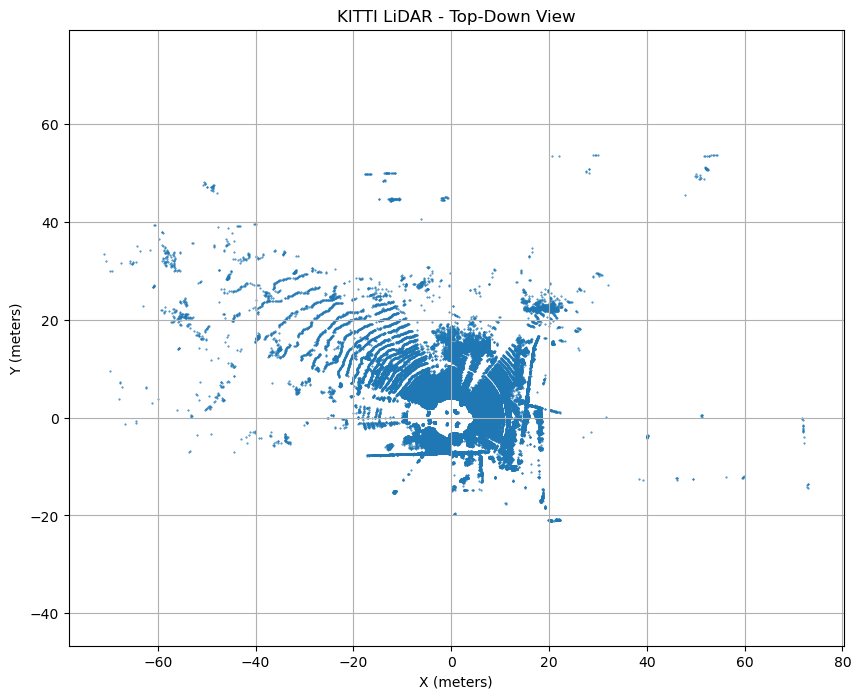

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    points[:, 0],   # x
    points[:, 1],   # y
    s=0.2
)

plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title("KITTI LiDAR - Top-Down View")

plt.axis("equal")
plt.grid(True)

plt.show()

Frame: 000201

LiDAR file exists: True
Label file exists: True
Calibration file exists: True

Number of LiDAR points: 106919
Point-cloud shape: (106919, 4)

First 5 LiDAR points:
[[55.115  0.112  2.073  0.19 ]
 [55.104  0.285  2.072  0.42 ]
 [55.061  0.458  2.071  0.24 ]
 [55.029  0.631  2.07   0.19 ]
 [54.995  0.803  2.069  0.41 ]]


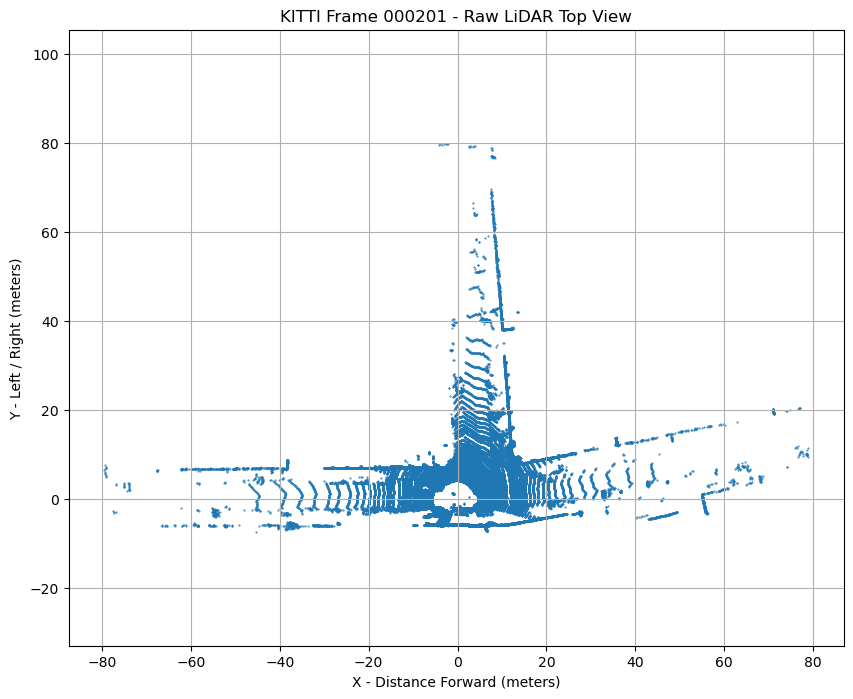

In [8]:
# ============================================================
# Load KITTI multi-object scene: Frame 000201
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ------------------------------------------------------------
# 1. Select the frame
# ------------------------------------------------------------

frame_id = "000201"


# ------------------------------------------------------------
# 2. Define file paths
# ------------------------------------------------------------

lidar_file_201 = Path(
    f"Data/training/velodyne/{frame_id}.bin"
)

label_file_201 = Path(
    f"Data/training/label_2/{frame_id}.txt"
)

calib_file_201 = Path(
    f"Data/training/calib/{frame_id}.txt"
)


# ------------------------------------------------------------
# 3. Check files
# ------------------------------------------------------------

print("Frame:", frame_id)

print("\nLiDAR file exists:", lidar_file_201.exists())
print("Label file exists:", label_file_201.exists())
print("Calibration file exists:", calib_file_201.exists())


# ------------------------------------------------------------
# 4. Load the LiDAR point cloud
# ------------------------------------------------------------

points_201 = np.fromfile(
    lidar_file_201,
    dtype=np.float32
).reshape(-1, 4)


print("\nNumber of LiDAR points:", len(points_201))
print("Point-cloud shape:", points_201.shape)


# ------------------------------------------------------------
# 5. Print first 5 points
# ------------------------------------------------------------

print("\nFirst 5 LiDAR points:")

print(points_201[:5])


# ============================================================
# 6. Raw top-down visualization
# ============================================================

plt.figure(figsize=(10, 8))

plt.scatter(
    points_201[:, 0],
    points_201[:, 1],
    s=0.2
)

plt.xlabel("X - Distance Forward (meters)")
plt.ylabel("Y - Left / Right (meters)")

plt.title(
    "KITTI Frame 000201 - Raw LiDAR Top View"
)

plt.axis("equal")
plt.grid(True)

plt.show()

Original points: 106919
ROI points: 48394
Points removed: 58525
Reduction: 54.74 %


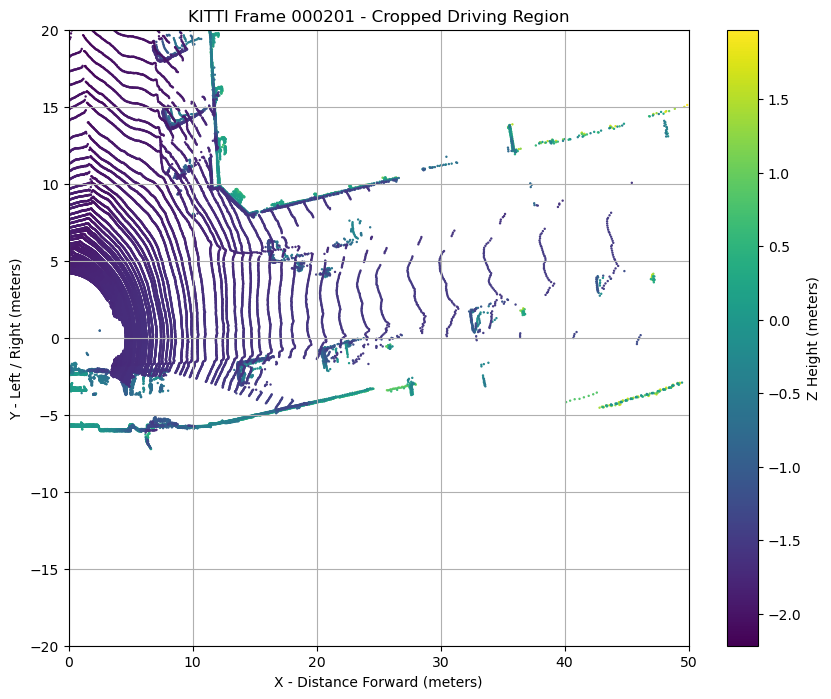

In [9]:
# ============================================================
# Crop Frame 000201 to a useful driving region
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Define Region of Interest (ROI)
# ------------------------------------------------------------

x_min_201, x_max_201 = 0, 50
y_min_201, y_max_201 = -20, 20
z_min_201, z_max_201 = -3, 2


# ------------------------------------------------------------
# 2. Create ROI mask
# ------------------------------------------------------------

roi_mask_201 = (
    (points_201[:, 0] >= x_min_201) &
    (points_201[:, 0] <= x_max_201) &

    (points_201[:, 1] >= y_min_201) &
    (points_201[:, 1] <= y_max_201) &

    (points_201[:, 2] >= z_min_201) &
    (points_201[:, 2] <= z_max_201)
)


# ------------------------------------------------------------
# 3. Apply the mask
# ------------------------------------------------------------

roi_points_201 = points_201[roi_mask_201]


# ------------------------------------------------------------
# 4. Print statistics
# ------------------------------------------------------------

print("Original points:", len(points_201))
print("ROI points:", len(roi_points_201))

points_removed_201 = (
    len(points_201) - len(roi_points_201)
)

print("Points removed:", points_removed_201)


reduction_201 = (
    points_removed_201 / len(points_201)
) * 100

print(
    "Reduction:",
    round(reduction_201, 2),
    "%"
)


# ============================================================
# 5. Plot cropped scene colored by height
# ============================================================

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    roi_points_201[:, 0],
    roi_points_201[:, 1],
    c=roi_points_201[:, 2],
    s=0.5,
    cmap="viridis"
)


plt.xlabel("X - Distance Forward (meters)")
plt.ylabel("Y - Left / Right (meters)")

plt.title(
    "KITTI Frame 000201 - Cropped Driving Region"
)


plt.xlim(
    x_min_201,
    x_max_201
)

plt.ylim(
    y_min_201,
    y_max_201
)


cbar = plt.colorbar(scatter)
cbar.set_label("Z Height (meters)")


plt.grid(True)
plt.show()

Detected ground plane:
0.0119x + -0.0203y + -0.9997z + -1.7417 = 0

ROI points: 48394
Ground points: 26665
Non-ground points: 21729
Ground percentage: 55.1 %


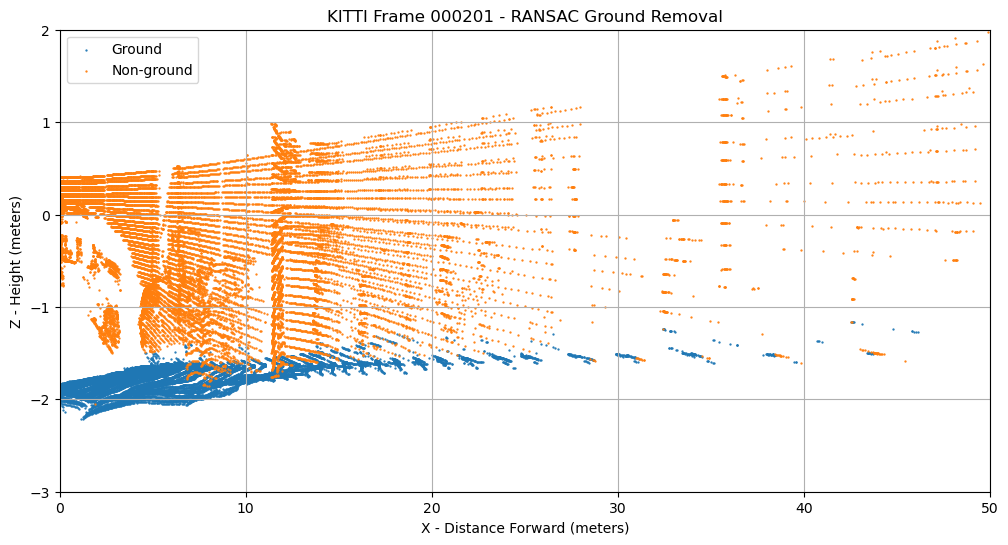

In [10]:
# ============================================================
# RANSAC Ground Plane Detection - Frame 000201
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Use XYZ coordinates from the cropped point cloud
# ------------------------------------------------------------

xyz_201 = roi_points_201[:, :3]


# ------------------------------------------------------------
# 2. RANSAC parameters
# ------------------------------------------------------------

num_iterations_201 = 300

# Points within 15 cm of the plane are treated as ground
distance_threshold_201 = 0.15

best_inliers_201 = None
best_plane_201 = None
best_inlier_count_201 = 0


# Reproducible randomness
rng_201 = np.random.default_rng(42)


# ============================================================
# 3. Run RANSAC
# ============================================================

for _ in range(num_iterations_201):

    # Randomly select 3 points
    sample_indices = rng_201.choice(
        len(xyz_201),
        size=3,
        replace=False
    )

    p1, p2, p3 = xyz_201[sample_indices]


    # Two vectors lying on the candidate plane
    v1 = p2 - p1
    v2 = p3 - p1


    # Plane normal
    normal = np.cross(v1, v2)

    normal_length = np.linalg.norm(normal)


    # Ignore bad / degenerate samples
    if normal_length < 1e-6:
        continue


    # Normalize the normal vector
    normal = normal / normal_length

    a, b, c = normal


    # --------------------------------------------------------
    # Ground plane should be approximately horizontal.
    #
    # Therefore its normal should point mostly along Z.
    # --------------------------------------------------------

    if abs(c) < 0.85:
        continue


    # Plane equation:
    #
    # ax + by + cz + d = 0
    # --------------------------------------------------------

    d = -np.dot(normal, p1)


    # Distance of every point from this candidate plane
    distances = np.abs(
        a * xyz_201[:, 0] +
        b * xyz_201[:, 1] +
        c * xyz_201[:, 2] +
        d
    )


    # Points close enough to the plane
    inliers = (
        distances < distance_threshold_201
    )


    inlier_count = np.sum(inliers)


    # Keep the best plane found so far
    if inlier_count > best_inlier_count_201:

        best_inlier_count_201 = inlier_count
        best_inliers_201 = inliers
        best_plane_201 = (
            a,
            b,
            c,
            d
        )


# ============================================================
# 4. Separate ground and non-ground points
# ============================================================

ground_points_201 = (
    roi_points_201[best_inliers_201]
)

non_ground_points_201 = (
    roi_points_201[~best_inliers_201]
)


# ============================================================
# 5. Print results
# ============================================================

print("Detected ground plane:")

print(
    f"{best_plane_201[0]:.4f}x + "
    f"{best_plane_201[1]:.4f}y + "
    f"{best_plane_201[2]:.4f}z + "
    f"{best_plane_201[3]:.4f} = 0"
)


print("\nROI points:", len(roi_points_201))

print(
    "Ground points:",
    len(ground_points_201)
)

print(
    "Non-ground points:",
    len(non_ground_points_201)
)


ground_percentage_201 = (
    len(ground_points_201)
    / len(roi_points_201)
) * 100


print(
    "Ground percentage:",
    round(ground_percentage_201, 2),
    "%"
)


# ============================================================
# 6. Side-view visualization
# ============================================================

plt.figure(figsize=(12, 6))


# Ground
plt.scatter(
    ground_points_201[:, 0],
    ground_points_201[:, 2],
    s=0.4,
    label="Ground"
)


# Everything above / outside the ground plane
plt.scatter(
    non_ground_points_201[:, 0],
    non_ground_points_201[:, 2],
    s=0.4,
    label="Non-ground"
)


plt.xlabel(
    "X - Distance Forward (meters)"
)

plt.ylabel(
    "Z - Height (meters)"
)

plt.title(
    "KITTI Frame 000201 - RANSAC Ground Removal"
)

plt.xlim(0, 50)
plt.ylim(-3, 2)

plt.legend()
plt.grid(True)

plt.show()

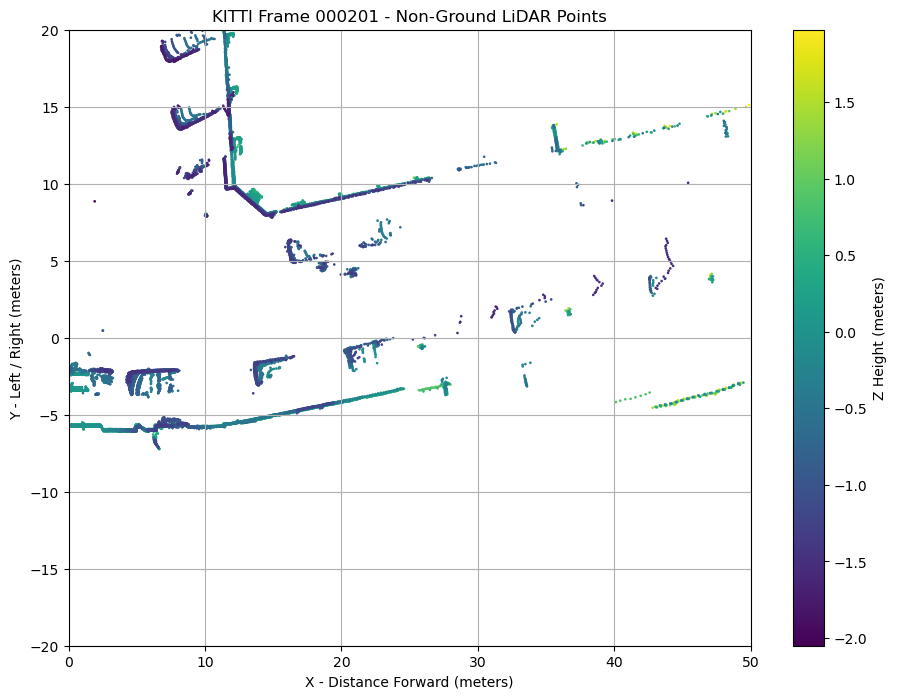

In [11]:
# ============================================================
# Top View AFTER Ground Removal - Frame 000201
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Plot only NON-GROUND points
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))

scatter = plt.scatter(
    non_ground_points_201[:, 0],      # X = forward
    non_ground_points_201[:, 1],      # Y = left/right
    c=non_ground_points_201[:, 2],    # color by Z height
    s=0.8,
    cmap="viridis"
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel(
    "X - Distance Forward (meters)"
)

plt.ylabel(
    "Y - Left / Right (meters)"
)

plt.title(
    "KITTI Frame 000201 - Non-Ground LiDAR Points"
)


# ------------------------------------------------------------
# Keep same driving region
# ------------------------------------------------------------

plt.xlim(0, 50)
plt.ylim(-20, 20)


# ------------------------------------------------------------
# Height color bar
# ------------------------------------------------------------

cbar = plt.colorbar(scatter)

cbar.set_label(
    "Z Height (meters)"
)


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

plt.grid(True)

plt.show()

Before downsampling: 21729
After downsampling : 7068
Points removed      : 14661
Reduction           : 67.47 %


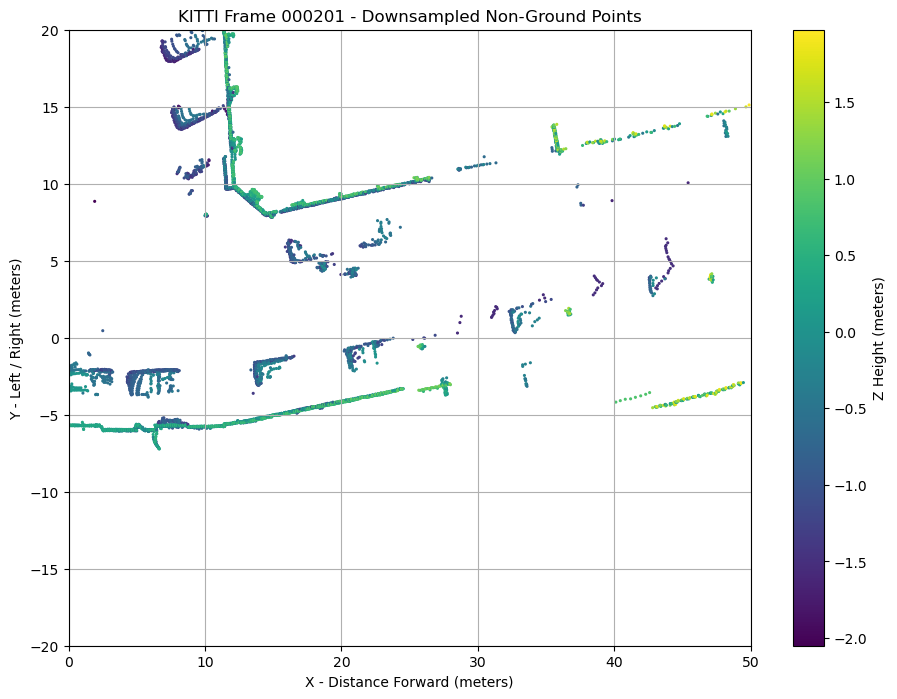

In [12]:
# ============================================================
# Voxel Downsampling - Frame 000201
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Set voxel size
# ------------------------------------------------------------

voxel_size_201 = 0.15   # 15 cm


# ------------------------------------------------------------
# 2. Use XYZ coordinates
# ------------------------------------------------------------

xyz_non_ground_201 = non_ground_points_201[:, :3]


# ------------------------------------------------------------
# 3. Convert every point into a voxel index
# ------------------------------------------------------------

voxel_indices_201 = np.floor(
    xyz_non_ground_201 / voxel_size_201
).astype(np.int32)


# ------------------------------------------------------------
# 4. Keep one point from each unique voxel
# ------------------------------------------------------------

_, unique_indices_201 = np.unique(
    voxel_indices_201,
    axis=0,
    return_index=True
)


downsampled_points_201 = (
    non_ground_points_201[unique_indices_201]
)


# ============================================================
# 5. Print statistics
# ============================================================

before_201 = len(non_ground_points_201)
after_201 = len(downsampled_points_201)

removed_201 = before_201 - after_201

reduction_voxel_201 = (
    removed_201 / before_201
) * 100


print("Before downsampling:", before_201)

print(
    "After downsampling :",
    after_201
)

print(
    "Points removed      :",
    removed_201
)

print(
    "Reduction           :",
    round(reduction_voxel_201, 2),
    "%"
)


# ============================================================
# 6. Plot downsampled point cloud
# ============================================================

plt.figure(figsize=(11, 8))


scatter = plt.scatter(
    downsampled_points_201[:, 0],
    downsampled_points_201[:, 1],
    c=downsampled_points_201[:, 2],
    s=1.5,
    cmap="viridis"
)


plt.xlabel(
    "X - Distance Forward (meters)"
)

plt.ylabel(
    "Y - Left / Right (meters)"
)

plt.title(
    "KITTI Frame 000201 - Downsampled Non-Ground Points"
)


plt.xlim(0, 50)
plt.ylim(-20, 20)


cbar = plt.colorbar(scatter)

cbar.set_label(
    "Z Height (meters)"
)


plt.grid(True)

plt.show()

Total downsampled points: 7068
Number of DBSCAN clusters: 28
Noise points: 132

Largest 20 clusters:

Cluster   4: 2666 points
Cluster   0: 2094 points
Cluster   2:  366 points
Cluster   8:  225 points
Cluster   1:  221 points
Cluster   9:  199 points
Cluster   3:  192 points
Cluster  10:  144 points
Cluster  19:  131 points
Cluster  24:  109 points
Cluster   5:  100 points
Cluster  14:   80 points
Cluster  17:   65 points
Cluster  11:   60 points
Cluster  12:   49 points
Cluster   7:   26 points
Cluster  15:   24 points
Cluster  23:   24 points
Cluster  26:   23 points
Cluster  13:   22 points


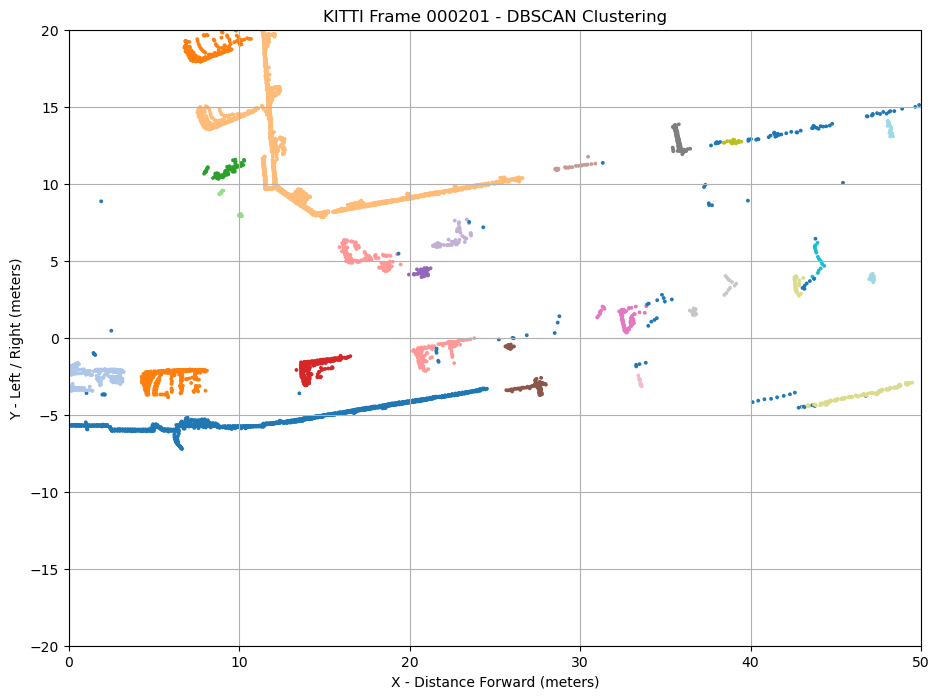

In [13]:
# ============================================================
# DBSCAN Clustering - KITTI Frame 000201
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN


# ------------------------------------------------------------
# 1. Use XYZ coordinates from downsampled point cloud
# ------------------------------------------------------------

xyz_down_201 = downsampled_points_201[:, :3]


# ------------------------------------------------------------
# 2. Create DBSCAN model
# ------------------------------------------------------------

dbscan_201 = DBSCAN(
    eps=0.6,          # points within 60 cm can be connected
    min_samples=8     # minimum points required for a cluster
)


# ------------------------------------------------------------
# 3. Run clustering
# ------------------------------------------------------------

cluster_labels_201 = dbscan_201.fit_predict(
    xyz_down_201
)


# ============================================================
# 4. Count clusters and noise
# ============================================================

unique_labels_201 = np.unique(
    cluster_labels_201
)


# DBSCAN uses -1 for noise
num_clusters_201 = len(
    unique_labels_201[
        unique_labels_201 != -1
    ]
)


num_noise_201 = np.sum(
    cluster_labels_201 == -1
)


print(
    "Total downsampled points:",
    len(downsampled_points_201)
)

print(
    "Number of DBSCAN clusters:",
    num_clusters_201
)

print(
    "Noise points:",
    num_noise_201
)


# ============================================================
# 5. Calculate cluster sizes
# ============================================================

cluster_sizes_201 = []


for label in unique_labels_201:

    if label == -1:
        continue

    cluster_size = np.sum(
        cluster_labels_201 == label
    )

    cluster_sizes_201.append(
        (label, cluster_size)
    )


# Sort biggest clusters first
cluster_sizes_201.sort(
    key=lambda x: x[1],
    reverse=True
)


print("\nLargest 20 clusters:\n")


for label, size in cluster_sizes_201[:20]:

    print(
        f"Cluster {label:3d}: "
        f"{size:4d} points"
    )


# ============================================================
# 6. Visualize DBSCAN clusters
# ============================================================

plt.figure(figsize=(11, 8))


plt.scatter(
    downsampled_points_201[:, 0],
    downsampled_points_201[:, 1],
    c=cluster_labels_201,
    s=3,
    cmap="tab20"
)


plt.xlabel(
    "X - Distance Forward (meters)"
)

plt.ylabel(
    "Y - Left / Right (meters)"
)

plt.title(
    "KITTI Frame 000201 - DBSCAN Clustering"
)


plt.xlim(0, 50)
plt.ylim(-20, 20)


plt.grid(True)

plt.show()

Original DBSCAN clusters: 28
Reasonable object candidates: 20

Candidate dimensions:

Cluster   1 | Points:  221 | X=3.23 m, Y=1.83 m, Z=1.56 m
Cluster   2 | Points:  366 | X=3.84 m, Y=1.80 m, Z=1.32 m
Cluster   3 | Points:  192 | X=3.91 m, Y=2.06 m, Z=1.38 m
Cluster   5 | Points:  100 | X=2.35 m, Y=1.25 m, Z=1.15 m
Cluster   8 | Points:  225 | X=3.16 m, Y=1.93 m, Z=1.27 m
Cluster   9 | Points:  199 | X=3.59 m, Y=2.02 m, Z=1.57 m
Cluster  10 | Points:  144 | X=3.60 m, Y=2.13 m, Z=1.30 m
Cluster  11 | Points:   60 | X=1.27 m, Y=0.59 m, Z=1.47 m
Cluster  12 | Points:   49 | X=2.25 m, Y=1.80 m, Z=1.09 m
Cluster  13 | Points:   22 | X=0.51 m, Y=0.28 m, Z=1.42 m
Cluster  14 | Points:   80 | X=2.32 m, Y=1.12 m, Z=1.54 m
Cluster  15 | Points:   24 | X=2.35 m, Y=0.88 m, Z=0.94 m
Cluster  17 | Points:   65 | X=1.58 m, Y=1.71 m, Z=1.19 m
Cluster  19 | Points:  131 | X=1.03 m, Y=1.94 m, Z=2.29 m
Cluster  20 | Points:   21 | X=0.38 m, Y=0.44 m, Z=1.30 m
Cluster  22 | Points:   21 | X=1.04 m, Y=0.2

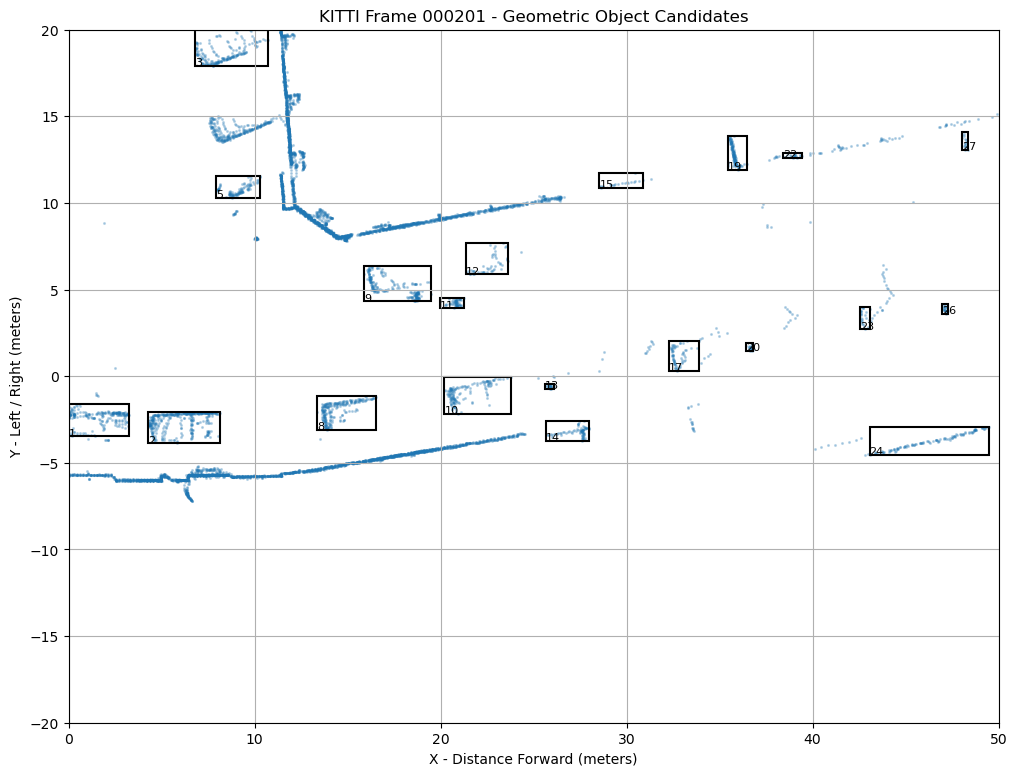

In [14]:
# ============================================================
# Create Geometric Object Candidates from DBSCAN Clusters
# KITTI Frame 000201
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# ------------------------------------------------------------
# 1. Store reasonable object candidates
# ------------------------------------------------------------

object_candidates_201 = []


# ------------------------------------------------------------
# 2. Examine every DBSCAN cluster
# ------------------------------------------------------------

for label in np.unique(cluster_labels_201):

    # DBSCAN label -1 means noise
    if label == -1:
        continue


    # Points belonging to this cluster
    cluster_points = downsampled_points_201[
        cluster_labels_201 == label
    ]


    # Ignore extremely small clusters
    if len(cluster_points) < 15:
        continue


    # --------------------------------------------------------
    # Find minimum and maximum XYZ coordinates
    # --------------------------------------------------------

    xyz_min = cluster_points[:, :3].min(axis=0)
    xyz_max = cluster_points[:, :3].max(axis=0)


    # Physical dimensions
    dimensions = xyz_max - xyz_min

    dx = dimensions[0]
    dy = dimensions[1]
    dz = dimensions[2]


    # Longest and shortest horizontal dimensions
    horizontal_long = max(dx, dy)
    horizontal_short = min(dx, dy)


    # --------------------------------------------------------
    # Basic object-size filter
    #
    # This is NOT classification.
    #
    # We are simply trying to remove:
    # - huge walls
    # - long fences
    # - tiny fragments
    #
    # while keeping possible:
    # - cars
    # - pedestrians
    # - cyclists
    # - vans
    # - small road objects
    # --------------------------------------------------------

    reasonable_size = (
        0.25 <= horizontal_long <= 7.0 and
        0.15 <= horizontal_short <= 4.0 and
        0.30 <= dz <= 3.5
    )


    if reasonable_size:

        object_candidates_201.append({

            "label": label,

            "points": cluster_points,

            "min": xyz_min,

            "max": xyz_max,

            "dimensions": dimensions,

            "num_points": len(cluster_points)

        })


# ============================================================
# 3. Print summary
# ============================================================

print(
    "Original DBSCAN clusters:",
    num_clusters_201
)

print(
    "Reasonable object candidates:",
    len(object_candidates_201)
)


print("\nCandidate dimensions:\n")


for obj in object_candidates_201:

    dx, dy, dz = obj["dimensions"]

    print(
        f"Cluster {obj['label']:3d} | "
        f"Points: {obj['num_points']:4d} | "
        f"X={dx:.2f} m, "
        f"Y={dy:.2f} m, "
        f"Z={dz:.2f} m"
    )


# ============================================================
# 4. Visualize candidates with bounding boxes
# ============================================================

plt.figure(figsize=(12, 9))

ax = plt.gca()


# ------------------------------------------------------------
# Plot all downsampled points lightly
# ------------------------------------------------------------

plt.scatter(
    downsampled_points_201[:, 0],
    downsampled_points_201[:, 1],
    s=1.5,
    alpha=0.25,
    label="LiDAR points"
)


# ------------------------------------------------------------
# Draw bounding box around every candidate
# ------------------------------------------------------------

for obj in object_candidates_201:

    xyz_min = obj["min"]
    xyz_max = obj["max"]


    x_min_box = xyz_min[0]
    y_min_box = xyz_min[1]


    width_x = (
        xyz_max[0] - xyz_min[0]
    )

    width_y = (
        xyz_max[1] - xyz_min[1]
    )


    rectangle = patches.Rectangle(

        (x_min_box, y_min_box),

        width_x,
        width_y,

        fill=False,
        linewidth=1.5
    )

    ax.add_patch(rectangle)


    # Write DBSCAN cluster ID next to box
    ax.text(

        x_min_box,
        y_min_box,

        str(obj["label"]),

        fontsize=8
    )


# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

plt.xlabel(
    "X - Distance Forward (meters)"
)

plt.ylabel(
    "Y - Left / Right (meters)"
)

plt.title(
    "KITTI Frame 000201 - Geometric Object Candidates"
)


plt.xlim(0, 50)
plt.ylim(-20, 20)

plt.grid(True)

plt.show()

KITTI ground-truth road users:

Car: 8
Cyclist: 2
Pedestrian: 2

Total road users: 12

Ground-truth object locations:

GT  0 | Car        | X=  1.17 m | Y= -2.87 m | L=4.33 W=1.59 H=1.78
GT  1 | Car        | X=  6.00 m | Y= -2.87 m | L=3.87 W=1.57 H=1.53
GT  2 | Car        | X= 15.12 m | Y= -2.13 m | L=3.34 W=1.61 H=1.45
GT  3 | Cyclist    | X= 18.71 m | Y=  4.63 m | L=1.83 W=0.57 H=1.76
GT  4 | Car        | X= 17.81 m | Y=  5.89 m | L=3.60 W=1.69 H=1.34
GT  5 | Car        | X= 22.17 m | Y= -1.06 m | L=3.77 W=1.59 H=1.69
GT  6 | Car        | X= 34.19 m | Y=  1.33 m | L=3.58 W=1.71 H=1.49
GT  7 | Car        | X= 39.13 m | Y=  9.62 m | L=3.46 W=1.81 H=1.39
GT  8 | Car        | X= 44.01 m | Y=  3.50 m | L=3.37 W=1.55 H=1.47
GT  9 | Pedestrian | X= 48.27 m | Y= 13.19 m | L=0.72 W=0.68 H=1.80
GT 10 | Pedestrian | X= 48.12 m | Y= 13.72 m | L=0.67 W=0.65 H=1.80
GT 11 | Cyclist    | X= 20.79 m | Y=  4.20 m | L=2.00 W=0.66 H=1.69


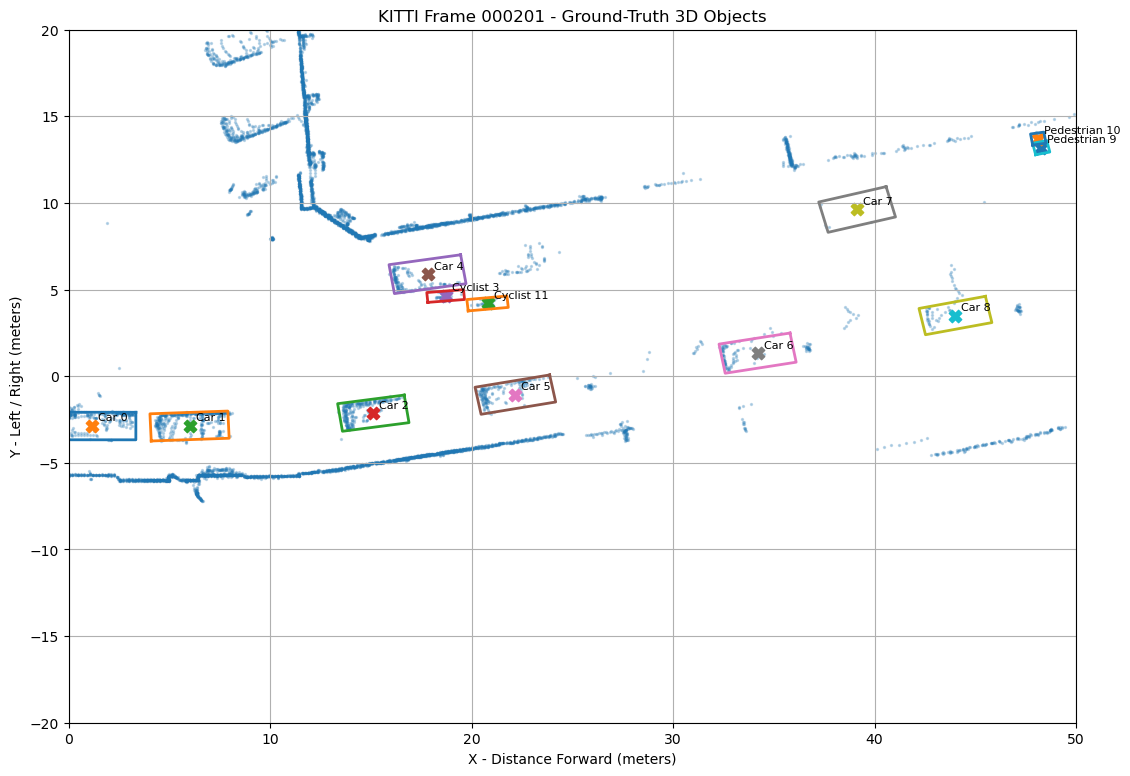

In [15]:
# ============================================================
# Load and Overlay KITTI Ground-Truth 3D Boxes
# Frame 000201
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter


# ============================================================
# 1. Load calibration for frame 000201
# ============================================================

calib_201 = {}

with open(calib_file_201, "r") as f:

    for line in f:

        line = line.strip()

        if not line:
            continue

        if ":" not in line:
            continue

        key, value = line.split(":", 1)

        calib_201[key] = np.array(
            [float(x) for x in value.split()],
            dtype=np.float64
        )


# ------------------------------------------------------------
# Camera rectification matrix
# ------------------------------------------------------------

R0_rect_201 = calib_201["R0_rect"].reshape(3, 3)

R0_rect_4x4_201 = np.eye(4)

R0_rect_4x4_201[:3, :3] = R0_rect_201


# ------------------------------------------------------------
# LiDAR -> Camera transformation
# ------------------------------------------------------------

Tr_velo_to_cam_201 = (
    calib_201["Tr_velo_to_cam"].reshape(3, 4)
)

Tr_velo_to_cam_4x4_201 = np.eye(4)

Tr_velo_to_cam_4x4_201[:3, :] = (
    Tr_velo_to_cam_201
)


# ------------------------------------------------------------
# Complete LiDAR -> Rectified Camera transform
# ------------------------------------------------------------

T_camera_from_lidar_201 = (
    R0_rect_4x4_201 @
    Tr_velo_to_cam_4x4_201
)


# ------------------------------------------------------------
# Camera -> LiDAR
# ------------------------------------------------------------

T_lidar_from_camera_201 = np.linalg.inv(
    T_camera_from_lidar_201
)


# ============================================================
# 2. Read KITTI labels
# ============================================================

gt_objects_201 = []


with open(label_file_201, "r") as f:

    for line in f:

        values = line.strip().split()

        if len(values) < 15:
            continue


        object_type = values[0]


        # Keep only the three main road-user classes
        if object_type not in [
            "Car",
            "Pedestrian",
            "Cyclist"
        ]:
            continue


        # KITTI dimensions:
        # height, width, length
        h = float(values[8])
        w = float(values[9])
        l = float(values[10])


        # Object position in camera coordinates
        x = float(values[11])
        y = float(values[12])
        z = float(values[13])


        # Rotation around camera Y-axis
        rotation_y = float(values[14])


        gt_objects_201.append({

            "type": object_type,

            "height": h,
            "width": w,
            "length": l,

            "x_camera": x,
            "y_camera": y,
            "z_camera": z,

            "rotation_y": rotation_y

        })


# ============================================================
# 3. Print class summary
# ============================================================

class_counts_201 = Counter(
    obj["type"]
    for obj in gt_objects_201
)


print("KITTI ground-truth road users:\n")

for class_name, count in class_counts_201.items():

    print(
        f"{class_name}: {count}"
    )


print(
    "\nTotal road users:",
    len(gt_objects_201)
)


# ============================================================
# 4. Construct every 3D box
#    Camera coordinates -> LiDAR coordinates
# ============================================================

gt_boxes_lidar_201 = []


for i, obj in enumerate(gt_objects_201):

    h = obj["height"]
    w = obj["width"]
    l = obj["length"]

    x = obj["x_camera"]
    y = obj["y_camera"]
    z = obj["z_camera"]

    rotation_y = obj["rotation_y"]


    # --------------------------------------------------------
    # Box corners in object-local coordinates
    #
    # KITTI object location = bottom-center
    # --------------------------------------------------------

    x_corners = np.array([
         l/2,  l/2, -l/2, -l/2,
         l/2,  l/2, -l/2, -l/2
    ])

    y_corners = np.array([
         0, 0, 0, 0,
        -h, -h, -h, -h
    ])

    z_corners = np.array([
         w/2, -w/2, -w/2,  w/2,
         w/2, -w/2, -w/2,  w/2
    ])


    corners_local = np.vstack([
        x_corners,
        y_corners,
        z_corners
    ])


    # --------------------------------------------------------
    # Rotation matrix around KITTI Camera-Y axis
    # --------------------------------------------------------

    cos_y = np.cos(rotation_y)
    sin_y = np.sin(rotation_y)


    R_y = np.array([
        [ cos_y, 0, sin_y],
        [     0, 1,     0],
        [-sin_y, 0, cos_y]
    ])


    # Rotate
    corners_camera = (
        R_y @ corners_local
    )


    # Translate to object position
    corners_camera[0, :] += x
    corners_camera[1, :] += y
    corners_camera[2, :] += z


    # --------------------------------------------------------
    # Homogeneous coordinates
    # --------------------------------------------------------

    corners_camera_h = np.vstack([
        corners_camera,
        np.ones(8)
    ])


    # --------------------------------------------------------
    # Camera -> LiDAR
    # --------------------------------------------------------

    corners_lidar_h = (
        T_lidar_from_camera_201 @
        corners_camera_h
    )


    corners_lidar = (
        corners_lidar_h[:3, :].T
    )


    # --------------------------------------------------------
    # Convert bottom-center into LiDAR coordinates too
    # --------------------------------------------------------

    center_camera = np.array([
        x,
        y,
        z,
        1.0
    ])


    center_lidar = (
        T_lidar_from_camera_201 @
        center_camera
    )


    gt_boxes_lidar_201.append({

        "id": i,

        "type": obj["type"],

        "corners": corners_lidar,

        "center": center_lidar[:3],

        "dimensions": (
            l,
            w,
            h
        )

    })


# ============================================================
# 5. Print object positions in LiDAR coordinates
# ============================================================

print("\nGround-truth object locations:\n")


for obj in gt_boxes_lidar_201:

    cx, cy, cz = obj["center"]

    l, w, h = obj["dimensions"]

    print(
        f"GT {obj['id']:2d} | "
        f"{obj['type']:10s} | "
        f"X={cx:6.2f} m | "
        f"Y={cy:6.2f} m | "
        f"L={l:.2f} "
        f"W={w:.2f} "
        f"H={h:.2f}"
    )


# ============================================================
# 6. Plot LiDAR + KITTI Ground-Truth Boxes
# ============================================================

plt.figure(figsize=(13, 9))


# ------------------------------------------------------------
# Background LiDAR
# ------------------------------------------------------------

plt.scatter(
    downsampled_points_201[:, 0],
    downsampled_points_201[:, 1],
    s=2,
    alpha=0.25,
    label="LiDAR points"
)


# ------------------------------------------------------------
# Draw each GT box
# ------------------------------------------------------------

bottom_order = [0, 1, 2, 3, 0]


for obj in gt_boxes_lidar_201:

    corners = obj["corners"]

    center = obj["center"]


    # Skip objects outside our current ROI
    if not (
        0 <= center[0] <= 50
        and
        -20 <= center[1] <= 20
    ):
        continue


    # Draw actual rotated KITTI box
    plt.plot(
        corners[bottom_order, 0],
        corners[bottom_order, 1],
        linewidth=2
    )


    # Ground-truth center
    plt.scatter(
        center[0],
        center[1],
        marker="X",
        s=80
    )


    # Object class + ID
    plt.text(
        center[0] + 0.3,
        center[1] + 0.3,
        f"{obj['type']} {obj['id']}",
        fontsize=8
    )


# ============================================================
# 7. Plot configuration
# ============================================================

plt.xlabel(
    "X - Distance Forward (meters)"
)

plt.ylabel(
    "Y - Left / Right (meters)"
)

plt.title(
    "KITTI Frame 000201 - Ground-Truth 3D Objects"
)


plt.xlim(0, 50)
plt.ylim(-20, 20)

plt.grid(True)

plt.show()

GT   Class       DBSCAN    BEV IoU     Center Dist.   
------------------------------------------------------
0    Car         1         0.528       0.56 m         
1    Car         2         0.827       0.21 m         
2    Car         8         0.813       0.18 m         
3    Cyclist     9         0.155       1.25 m         
4    Car         9         0.557       0.58 m         
5    Car         10        0.833       0.17 m         
6    Car         17        0.302       1.12 m         
7    Car         22        0.000       3.12 m         
8    Car         23        0.082       1.19 m         
9    Pedestrian  27        0.191       0.39 m         
10   Pedestrian  27        0.350       0.16 m         
11   Cyclist     11        0.410       0.20 m         

------------------------------------------
GT objects evaluated: 12
Objects with IoU > 0: 11
Objects with IoU >= 0.25: 8
Objects with IoU >= 0.50: 5
Mean best IoU: 0.421


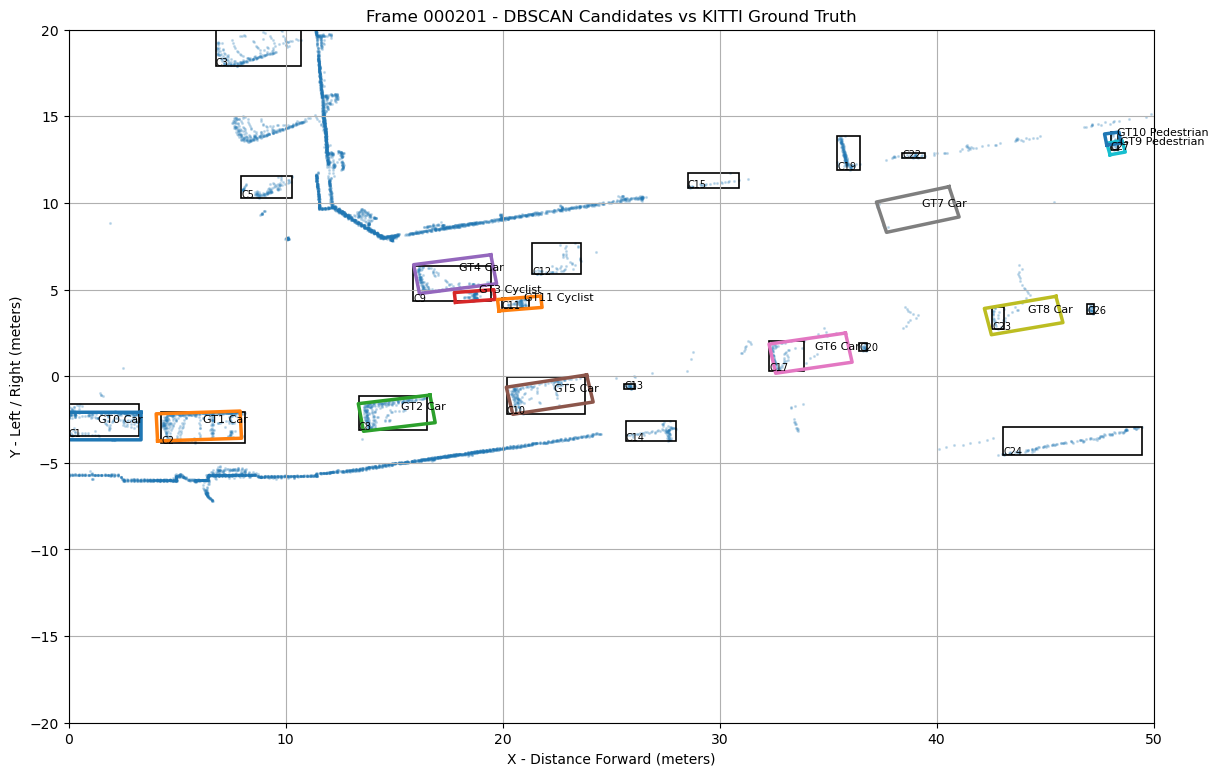

In [16]:
# ============================================================
# Match DBSCAN Object Candidates to KITTI Ground Truth
# Frame 000201
#
# Metric used here:
# Axis-Aligned BEV IoU
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# ============================================================
# 1. Function for axis-aligned BEV IoU
# ============================================================

def bev_iou_axis_aligned(box_a, box_b):
    """
    box format:
    [x_min, y_min, x_max, y_max]
    """

    ax_min, ay_min, ax_max, ay_max = box_a
    bx_min, by_min, bx_max, by_max = box_b

    # Intersection boundaries
    inter_x_min = max(ax_min, bx_min)
    inter_y_min = max(ay_min, by_min)

    inter_x_max = min(ax_max, bx_max)
    inter_y_max = min(ay_max, by_max)

    # Intersection size
    inter_width = max(
        0.0,
        inter_x_max - inter_x_min
    )

    inter_height = max(
        0.0,
        inter_y_max - inter_y_min
    )

    intersection = (
        inter_width * inter_height
    )

    # Box areas
    area_a = (
        (ax_max - ax_min) *
        (ay_max - ay_min)
    )

    area_b = (
        (bx_max - bx_min) *
        (by_max - by_min)
    )

    union = (
        area_a +
        area_b -
        intersection
    )

    if union <= 0:
        return 0.0

    return intersection / union


# ============================================================
# 2. Convert DBSCAN candidates into BEV boxes
# ============================================================

candidate_boxes_201 = []


for obj in object_candidates_201:

    xyz_min = obj["min"]
    xyz_max = obj["max"]

    box = np.array([
        xyz_min[0],
        xyz_min[1],
        xyz_max[0],
        xyz_max[1]
    ])

    center = np.array([
        (xyz_min[0] + xyz_max[0]) / 2,
        (xyz_min[1] + xyz_max[1]) / 2
    ])

    candidate_boxes_201.append({

        "cluster": obj["label"],

        "box": box,

        "center": center,

        "points": obj["num_points"]

    })


# ============================================================
# 3. Convert KITTI GT boxes into axis-aligned BEV boxes
# ============================================================

gt_bev_boxes_201 = []


for obj in gt_boxes_lidar_201:

    center = obj["center"]


    # Skip GT objects outside our ROI
    if not (
        0 <= center[0] <= 50
        and
        -20 <= center[1] <= 20
    ):
        continue


    corners = obj["corners"]


    gt_x_min = corners[:, 0].min()
    gt_x_max = corners[:, 0].max()

    gt_y_min = corners[:, 1].min()
    gt_y_max = corners[:, 1].max()


    box = np.array([
        gt_x_min,
        gt_y_min,
        gt_x_max,
        gt_y_max
    ])


    gt_bev_boxes_201.append({

        "id": obj["id"],

        "type": obj["type"],

        "box": box,

        "center": center[:2],

        "corners": corners

    })


# ============================================================
# 4. Find BEST DBSCAN candidate for every KITTI object
# ============================================================

match_results_201 = []


for gt in gt_bev_boxes_201:

    best_iou = 0.0
    best_candidate = None
    best_distance = None


    for candidate in candidate_boxes_201:

        iou = bev_iou_axis_aligned(
            gt["box"],
            candidate["box"]
        )


        # Distance between box centers
        distance = np.linalg.norm(
            gt["center"] -
            candidate["center"]
        )


        if iou > best_iou:

            best_iou = iou
            best_candidate = candidate
            best_distance = distance


    # --------------------------------------------------------
    # In some cases there may be ZERO IoU.
    # Then also find nearest candidate for information.
    # --------------------------------------------------------

    if best_candidate is None:

        distances = []

        for candidate in candidate_boxes_201:

            distance = np.linalg.norm(
                gt["center"] -
                candidate["center"]
            )

            distances.append(
                (distance, candidate)
            )


        if len(distances) > 0:

            distances.sort(
                key=lambda x: x[0]
            )

            best_distance, best_candidate = distances[0]


    match_results_201.append({

        "gt_id": gt["id"],

        "class": gt["type"],

        "gt_center": gt["center"],

        "cluster": (
            best_candidate["cluster"]
            if best_candidate is not None
            else None
        ),

        "iou": best_iou,

        "center_distance": best_distance

    })


# ============================================================
# 5. Print matching table
# ============================================================

print(
    f"{'GT':<5}"
    f"{'Class':<12}"
    f"{'DBSCAN':<10}"
    f"{'BEV IoU':<12}"
    f"{'Center Dist.':<15}"
)

print("-" * 54)


for result in match_results_201:

    cluster_text = (
        str(result["cluster"])
        if result["cluster"] is not None
        else "None"
    )

    distance_text = (
        f"{result['center_distance']:.2f} m"
        if result["center_distance"] is not None
        else "N/A"
    )


    print(
        f"{result['gt_id']:<5}"
        f"{result['class']:<12}"
        f"{cluster_text:<10}"
        f"{result['iou']:<12.3f}"
        f"{distance_text:<15}"
    )


# ============================================================
# 6. Simple summary
# ============================================================

iou_values_201 = np.array([
    result["iou"]
    for result in match_results_201
])


print("\n------------------------------------------")

print(
    "GT objects evaluated:",
    len(match_results_201)
)

print(
    "Objects with IoU > 0:",
    np.sum(iou_values_201 > 0)
)

print(
    "Objects with IoU >= 0.25:",
    np.sum(iou_values_201 >= 0.25)
)

print(
    "Objects with IoU >= 0.50:",
    np.sum(iou_values_201 >= 0.50)
)

print(
    "Mean best IoU:",
    round(
        np.mean(iou_values_201),
        3
    )
)


# ============================================================
# 7. Visualization:
# DBSCAN candidates + KITTI GT boxes
# ============================================================

plt.figure(figsize=(14, 9))

ax = plt.gca()


# ------------------------------------------------------------
# LiDAR background
# ------------------------------------------------------------

plt.scatter(
    downsampled_points_201[:, 0],
    downsampled_points_201[:, 1],
    s=1.5,
    alpha=0.2,
    label="LiDAR"
)


# ------------------------------------------------------------
# DBSCAN candidate boxes
# ------------------------------------------------------------

for candidate in candidate_boxes_201:

    box = candidate["box"]

    x_min_box = box[0]
    y_min_box = box[1]

    width = (
        box[2] - box[0]
    )

    height = (
        box[3] - box[1]
    )


    rectangle = patches.Rectangle(
        (x_min_box, y_min_box),
        width,
        height,
        fill=False,
        linewidth=1.2
    )

    ax.add_patch(rectangle)


    ax.text(
        x_min_box,
        y_min_box,
        f"C{candidate['cluster']}",
        fontsize=7
    )


# ------------------------------------------------------------
# KITTI rotated GT boxes
# ------------------------------------------------------------

bottom_order = [0, 1, 2, 3, 0]


for gt in gt_bev_boxes_201:

    corners = gt["corners"]

    plt.plot(
        corners[bottom_order, 0],
        corners[bottom_order, 1],
        linewidth=2.5
    )

    plt.text(
        gt["center"][0] + 0.2,
        gt["center"][1] + 0.2,
        f"GT{gt['id']} {gt['type']}",
        fontsize=8
    )


# ============================================================
# Plot configuration
# ============================================================

plt.xlabel(
    "X - Distance Forward (meters)"
)

plt.ylabel(
    "Y - Left / Right (meters)"
)

plt.title(
    "Frame 000201 - DBSCAN Candidates vs KITTI Ground Truth"
)


plt.xlim(0, 50)
plt.ylim(-20, 20)

plt.grid(True)

plt.show()

Raw LiDAR points: 106919
Points inside BEV region: 48393

BEV size:
Height: 500
Width : 400

BEV NumPy shape:
(3, 500, 400)

PyTorch BEV tensor:
Shape : torch.Size([1, 3, 500, 400])
Device: cuda:0


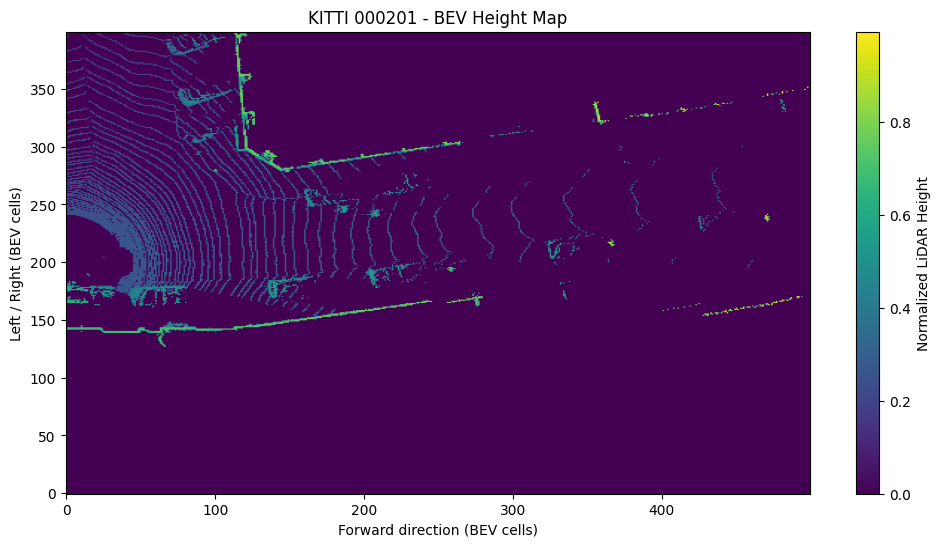

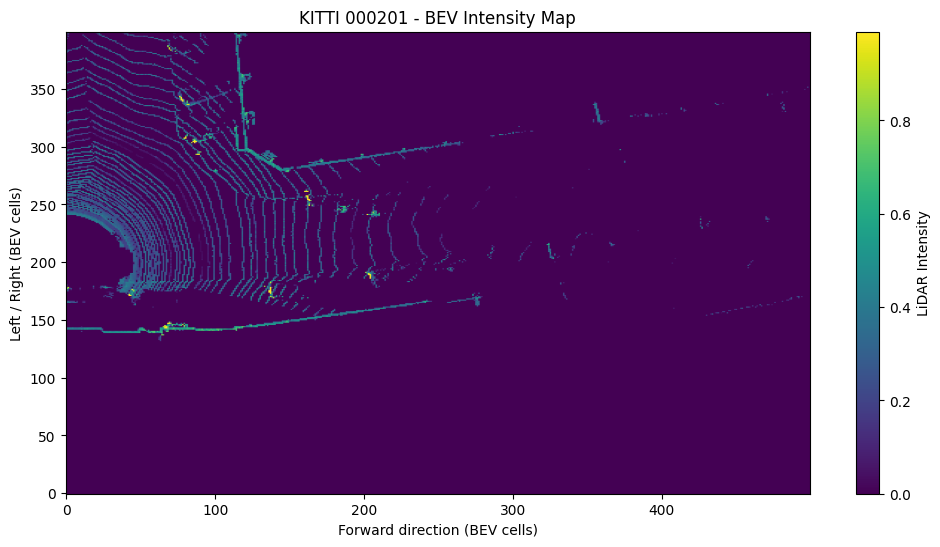

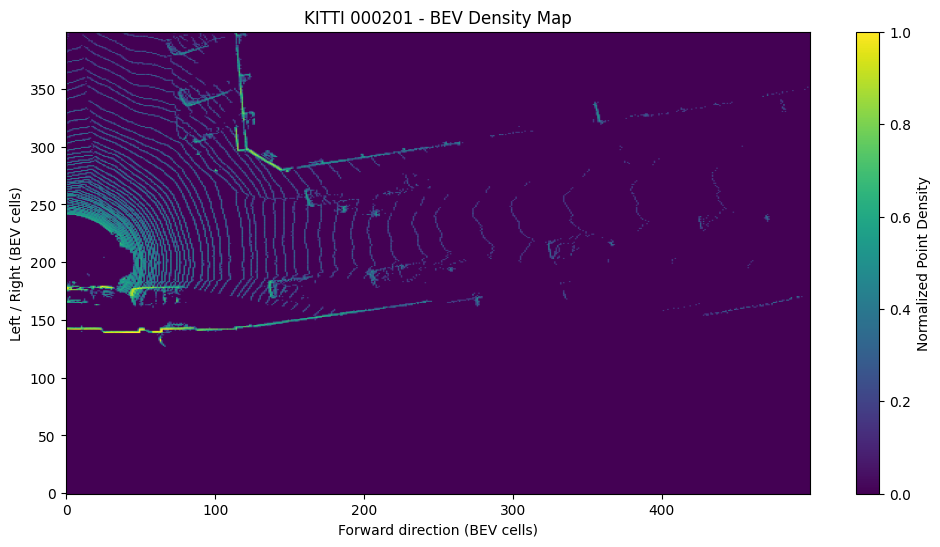

In [19]:
# ============================================================
# Create a Bird's-Eye-View (BEV) representation from LiDAR
# KITTI Frame 000201
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path


# ============================================================
# 1. Load frame 000201 again
# ============================================================

frame_id = "000201"

lidar_path = Path(
    f"Data/training/velodyne/{frame_id}.bin"
)

points_ai = np.fromfile(
    lidar_path,
    dtype=np.float32
).reshape(-1, 4)


print("Raw LiDAR points:", len(points_ai))


# ============================================================
# 2. Define BEV region
#
# X = forward
# Y = left/right
# Z = height
# ============================================================

x_min, x_max = 0.0, 50.0
y_min, y_max = -20.0, 20.0
z_min, z_max = -3.0, 2.0


# Resolution:
# each BEV pixel represents 10 cm x 10 cm
resolution = 0.10


# ============================================================
# 3. Crop LiDAR to our driving region
# ============================================================

roi_mask_ai = (
    (points_ai[:, 0] >= x_min) &
    (points_ai[:, 0] <  x_max) &

    (points_ai[:, 1] >= y_min) &
    (points_ai[:, 1] <  y_max) &

    (points_ai[:, 2] >= z_min) &
    (points_ai[:, 2] <  z_max)
)


points_ai = points_ai[roi_mask_ai]


print("Points inside BEV region:", len(points_ai))


# ============================================================
# 4. Calculate BEV image dimensions
# ============================================================

bev_height = int(
    (x_max - x_min) / resolution
)

bev_width = int(
    (y_max - y_min) / resolution
)


print("\nBEV size:")
print("Height:", bev_height)
print("Width :", bev_width)


# ============================================================
# 5. Convert LiDAR coordinates -> BEV pixel coordinates
# ============================================================

x_indices = (
    (points_ai[:, 0] - x_min) / resolution
).astype(np.int32)


y_indices = (
    (points_ai[:, 1] - y_min) / resolution
).astype(np.int32)


# ============================================================
# 6. Create three BEV channels
#
# Channel 1 = maximum height
# Channel 2 = maximum intensity
# Channel 3 = point density
# ============================================================

height_map = np.zeros(
    (bev_height, bev_width),
    dtype=np.float32
)

intensity_map = np.zeros(
    (bev_height, bev_width),
    dtype=np.float32
)

density_map = np.zeros(
    (bev_height, bev_width),
    dtype=np.float32
)


# ------------------------------------------------------------
# Normalize Z height to 0...1
# ------------------------------------------------------------

normalized_height = (
    points_ai[:, 2] - z_min
) / (
    z_max - z_min
)


# ------------------------------------------------------------
# Keep maximum height per BEV cell
# ------------------------------------------------------------

np.maximum.at(
    height_map,
    (x_indices, y_indices),
    normalized_height
)


# ------------------------------------------------------------
# Keep maximum intensity per BEV cell
# ------------------------------------------------------------

np.maximum.at(
    intensity_map,
    (x_indices, y_indices),
    points_ai[:, 3]
)


# ------------------------------------------------------------
# Count number of LiDAR points in each cell
# ------------------------------------------------------------

np.add.at(
    density_map,
    (x_indices, y_indices),
    1
)


# ------------------------------------------------------------
# Log-normalize density
# ------------------------------------------------------------

density_map = np.minimum(
    1.0,
    np.log1p(density_map) / np.log(64)
)


# ============================================================
# 7. Stack into a 3-channel tensor
#
# Shape:
# [channels, height, width]
# ============================================================

bev = np.stack(
    [
        height_map,
        intensity_map,
        density_map
    ],
    axis=0
)


print("\nBEV NumPy shape:")
print(bev.shape)


# ============================================================
# 8. Convert to PyTorch tensor
# ============================================================

bev_tensor = torch.from_numpy(
    bev
).float()


# Add batch dimension:
#
# [3, H, W]
#       ↓
# [1, 3, H, W]

bev_tensor = bev_tensor.unsqueeze(0)


# Send to GPU
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

bev_tensor = bev_tensor.to(device)


print("\nPyTorch BEV tensor:")
print("Shape :", bev_tensor.shape)
print("Device:", bev_tensor.device)


# ============================================================
# 9. Visualize the three BEV channels
# ============================================================

plt.figure(figsize=(12, 6))

plt.imshow(
    height_map.T,
    origin="lower",
    aspect="auto"
)

plt.xlabel("Forward direction (BEV cells)")
plt.ylabel("Left / Right (BEV cells)")

plt.title(
    "KITTI 000201 - BEV Height Map"
)

plt.colorbar(
    label="Normalized LiDAR Height"
)

plt.show()


plt.figure(figsize=(12, 6))

plt.imshow(
    intensity_map.T,
    origin="lower",
    aspect="auto"
)

plt.xlabel("Forward direction (BEV cells)")
plt.ylabel("Left / Right (BEV cells)")

plt.title(
    "KITTI 000201 - BEV Intensity Map"
)

plt.colorbar(
    label="LiDAR Intensity"
)

plt.show()


plt.figure(figsize=(12, 6))

plt.imshow(
    density_map.T,
    origin="lower",
    aspect="auto"
)

plt.xlabel("Forward direction (BEV cells)")
plt.ylabel("Left / Right (BEV cells)")

plt.title(
    "KITTI 000201 - BEV Density Map"
)

plt.colorbar(
    label="Normalized Point Density"
)

plt.show()

Label file exists: True
Calibration file exists: True

Total GT road users: 12
GT objects inside BEV region: 12

Objects:

GT  0 | Car        | X=  1.17 m | Y= -2.87 m
GT  1 | Car        | X=  6.00 m | Y= -2.87 m
GT  2 | Car        | X= 15.12 m | Y= -2.13 m
GT  3 | Cyclist    | X= 18.71 m | Y=  4.63 m
GT  4 | Car        | X= 17.81 m | Y=  5.89 m
GT  5 | Car        | X= 22.17 m | Y= -1.06 m
GT  6 | Car        | X= 34.19 m | Y=  1.33 m
GT  7 | Car        | X= 39.13 m | Y=  9.62 m
GT  8 | Car        | X= 44.01 m | Y=  3.50 m
GT  9 | Pedestrian | X= 48.27 m | Y= 13.19 m
GT 10 | Pedestrian | X= 48.12 m | Y= 13.72 m
GT 11 | Cyclist    | X= 20.79 m | Y=  4.20 m


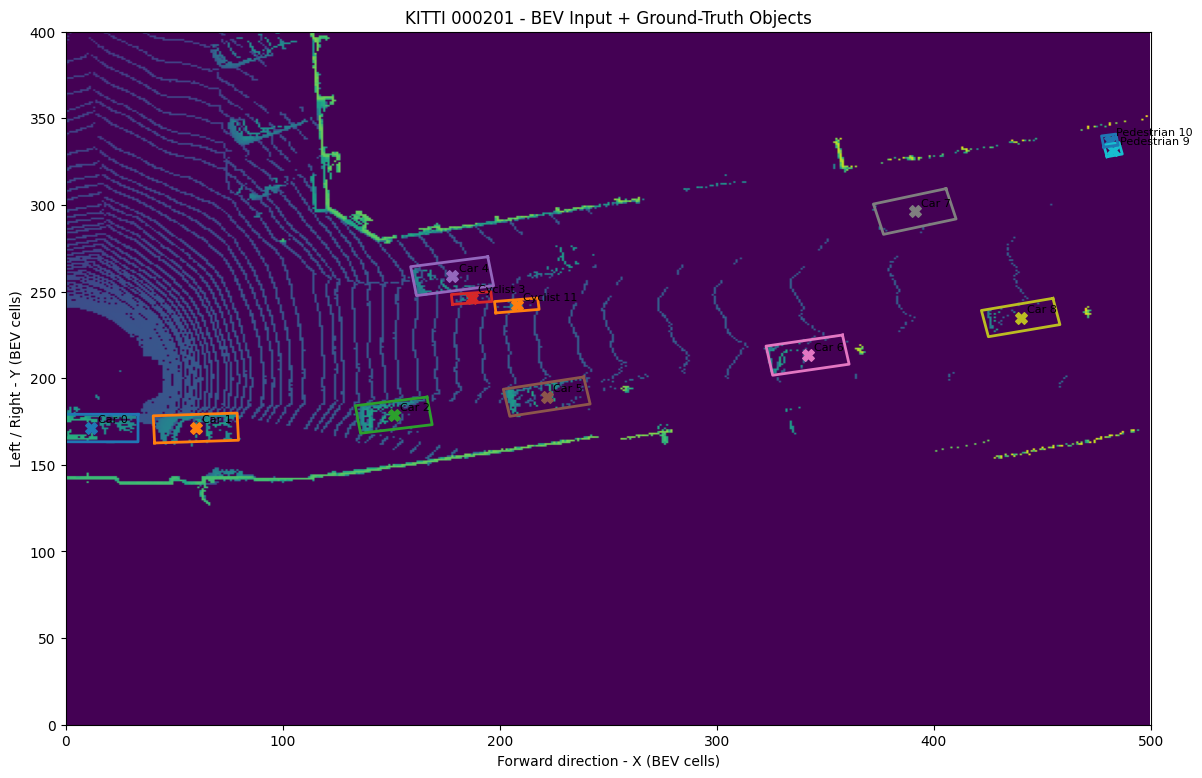

In [20]:
# ============================================================
# Overlay KITTI Ground-Truth Objects on the BEV Height Map
# Frame 000201
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. Frame paths
# ============================================================

frame_id = "000201"

label_path = Path(
    f"Data/training/label_2/{frame_id}.txt"
)

calib_path = Path(
    f"Data/training/calib/{frame_id}.txt"
)


print("Label file exists:", label_path.exists())
print("Calibration file exists:", calib_path.exists())


# ============================================================
# 2. Read calibration file
# ============================================================

calib = {}

with open(calib_path, "r") as f:

    for line in f:

        line = line.strip()

        if not line:
            continue

        if ":" not in line:
            continue

        key, value = line.split(":", 1)

        calib[key] = np.array(
            [float(v) for v in value.split()],
            dtype=np.float64
        )


# Camera rectification matrix
R0_rect = calib["R0_rect"].reshape(3, 3)

R0_rect_4x4 = np.eye(4)
R0_rect_4x4[:3, :3] = R0_rect


# LiDAR -> Camera
Tr_velo_to_cam = (
    calib["Tr_velo_to_cam"]
    .reshape(3, 4)
)

Tr_velo_to_cam_4x4 = np.eye(4)
Tr_velo_to_cam_4x4[:3, :] = Tr_velo_to_cam


# Complete transform:
# LiDAR -> rectified camera
T_camera_from_lidar = (
    R0_rect_4x4 @ Tr_velo_to_cam_4x4
)


# Invert:
# Camera -> LiDAR
T_lidar_from_camera = np.linalg.inv(
    T_camera_from_lidar
)


# ============================================================
# 3. Read KITTI labels
# ============================================================

gt_objects = []


with open(label_path, "r") as f:

    for line in f:

        values = line.strip().split()

        if len(values) < 15:
            continue

        object_type = values[0]

        # Keep only our three important classes
        if object_type not in [
            "Car",
            "Pedestrian",
            "Cyclist"
        ]:
            continue


        # KITTI dimensions
        # order = height, width, length
        h = float(values[8])
        w = float(values[9])
        l = float(values[10])


        # Camera coordinates
        x = float(values[11])
        y = float(values[12])
        z = float(values[13])


        rotation_y = float(values[14])


        gt_objects.append({
            "type": object_type,
            "h": h,
            "w": w,
            "l": l,
            "x": x,
            "y": y,
            "z": z,
            "rotation_y": rotation_y
        })


print("\nTotal GT road users:", len(gt_objects))


# ============================================================
# 4. Build each KITTI 3D bounding box
#    and transform Camera -> LiDAR
# ============================================================

bev_gt_boxes = []


for obj_id, obj in enumerate(gt_objects):

    h = obj["h"]
    w = obj["w"]
    l = obj["l"]

    x = obj["x"]
    y = obj["y"]
    z = obj["z"]

    rotation_y = obj["rotation_y"]


    # --------------------------------------------------------
    # 8 box corners in local camera coordinates
    #
    # KITTI object position = bottom-center
    # --------------------------------------------------------

    x_corners = np.array([
         l/2,  l/2, -l/2, -l/2,
         l/2,  l/2, -l/2, -l/2
    ])

    y_corners = np.array([
         0, 0, 0, 0,
        -h, -h, -h, -h
    ])

    z_corners = np.array([
         w/2, -w/2, -w/2,  w/2,
         w/2, -w/2, -w/2,  w/2
    ])


    corners_local = np.vstack([
        x_corners,
        y_corners,
        z_corners
    ])


    # --------------------------------------------------------
    # Rotation around camera Y axis
    # --------------------------------------------------------

    c = np.cos(rotation_y)
    s = np.sin(rotation_y)


    R_y = np.array([
        [ c, 0, s],
        [ 0, 1, 0],
        [-s, 0, c]
    ])


    corners_camera = (
        R_y @ corners_local
    )


    # Translate to object location
    corners_camera[0, :] += x
    corners_camera[1, :] += y
    corners_camera[2, :] += z


    # Homogeneous coordinates
    corners_camera_h = np.vstack([
        corners_camera,
        np.ones(8)
    ])


    # Camera -> LiDAR
    corners_lidar_h = (
        T_lidar_from_camera @
        corners_camera_h
    )


    corners_lidar = (
        corners_lidar_h[:3, :].T
    )


    # --------------------------------------------------------
    # Bottom center -> LiDAR
    # --------------------------------------------------------

    center_camera = np.array([
        x,
        y,
        z,
        1.0
    ])


    center_lidar = (
        T_lidar_from_camera @
        center_camera
    )[:3]


    # --------------------------------------------------------
    # Keep only objects inside our BEV region
    # --------------------------------------------------------

    if not (
        x_min <= center_lidar[0] < x_max
        and
        y_min <= center_lidar[1] < y_max
    ):
        continue


    # --------------------------------------------------------
    # Convert LiDAR coordinates -> BEV pixel coordinates
    # --------------------------------------------------------

    corners_bev_x = (
        corners_lidar[:, 0] - x_min
    ) / resolution


    corners_bev_y = (
        corners_lidar[:, 1] - y_min
    ) / resolution


    center_bev_x = (
        center_lidar[0] - x_min
    ) / resolution


    center_bev_y = (
        center_lidar[1] - y_min
    ) / resolution


    bev_gt_boxes.append({

        "id": obj_id,

        "type": obj["type"],

        "corners_x": corners_bev_x,
        "corners_y": corners_bev_y,

        "center_x": center_bev_x,
        "center_y": center_bev_y,

        "center_lidar": center_lidar
    })


# ============================================================
# 5. Print objects inside BEV
# ============================================================

print(
    "GT objects inside BEV region:",
    len(bev_gt_boxes)
)

print("\nObjects:\n")


for obj in bev_gt_boxes:

    center = obj["center_lidar"]

    print(
        f"GT {obj['id']:2d} | "
        f"{obj['type']:10s} | "
        f"X={center[0]:6.2f} m | "
        f"Y={center[1]:6.2f} m"
    )


# ============================================================
# 6. Visualize BEV + Ground Truth Boxes
# ============================================================

plt.figure(figsize=(14, 9))


# Our AI input
plt.imshow(
    height_map.T,
    origin="lower",
    aspect="auto"
)


# Bottom face of each 3D box
bottom_order = [0, 1, 2, 3, 0]


for obj in bev_gt_boxes:

    plt.plot(
        obj["corners_x"][bottom_order],
        obj["corners_y"][bottom_order],
        linewidth=2
    )


    # Ground-truth object center
    plt.scatter(
        obj["center_x"],
        obj["center_y"],
        marker="X",
        s=70
    )


    # Label
    plt.text(
        obj["center_x"] + 3,
        obj["center_y"] + 3,
        f"{obj['type']} {obj['id']}",
        fontsize=8
    )


plt.xlabel(
    "Forward direction - X (BEV cells)"
)

plt.ylabel(
    "Left / Right - Y (BEV cells)"
)

plt.title(
    "KITTI 000201 - BEV Input + Ground-Truth Objects"
)

plt.xlim(0, bev_height)
plt.ylim(0, bev_width)

plt.grid(False)

plt.show()

Creating targets:

Car        | class=0 | BEV center=(11.7, 171.3)
Car        | class=0 | BEV center=(60.0, 171.3)
Car        | class=0 | BEV center=(151.2, 178.7)
Cyclist    | class=2 | BEV center=(187.1, 246.3)
Car        | class=0 | BEV center=(178.1, 258.9)
Car        | class=0 | BEV center=(221.7, 189.4)
Car        | class=0 | BEV center=(341.9, 213.3)
Car        | class=0 | BEV center=(391.3, 296.2)
Car        | class=0 | BEV center=(440.1, 235.0)
Pedestrian | class=1 | BEV center=(482.7, 331.9)
Pedestrian | class=1 | BEV center=(481.2, 337.2)
Cyclist    | class=2 | BEV center=(207.9, 242.0)

TRAINING DATA SHAPES
Input BEV tensor : torch.Size([1, 3, 500, 400])
Target tensor    : torch.Size([1, 3, 500, 400])
Input device     : cuda:0
Target device    : cuda:0
Car        heatmap max = 1.0
Pedestrian heatmap max = 1.0
Cyclist    heatmap max = 1.0


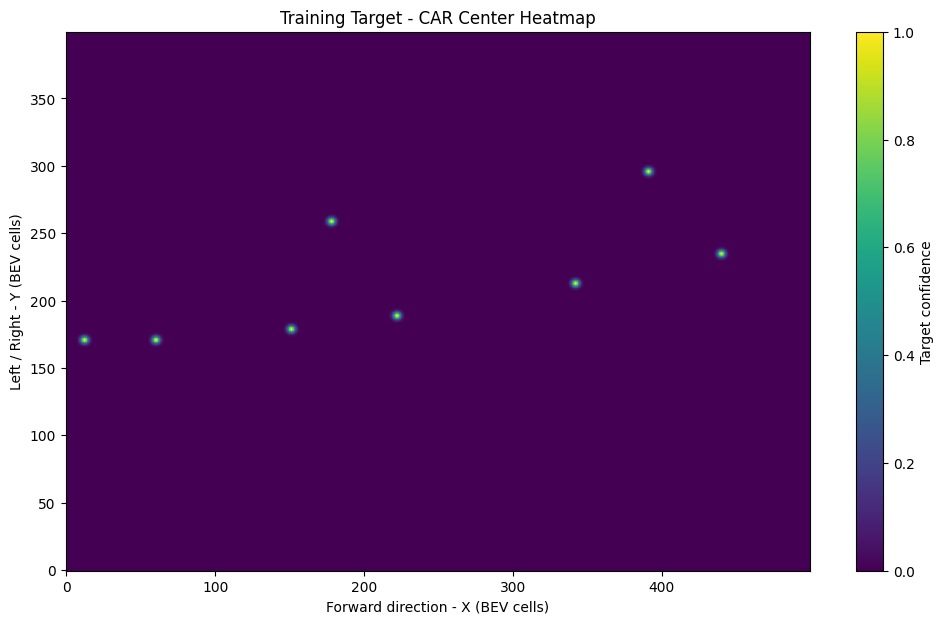

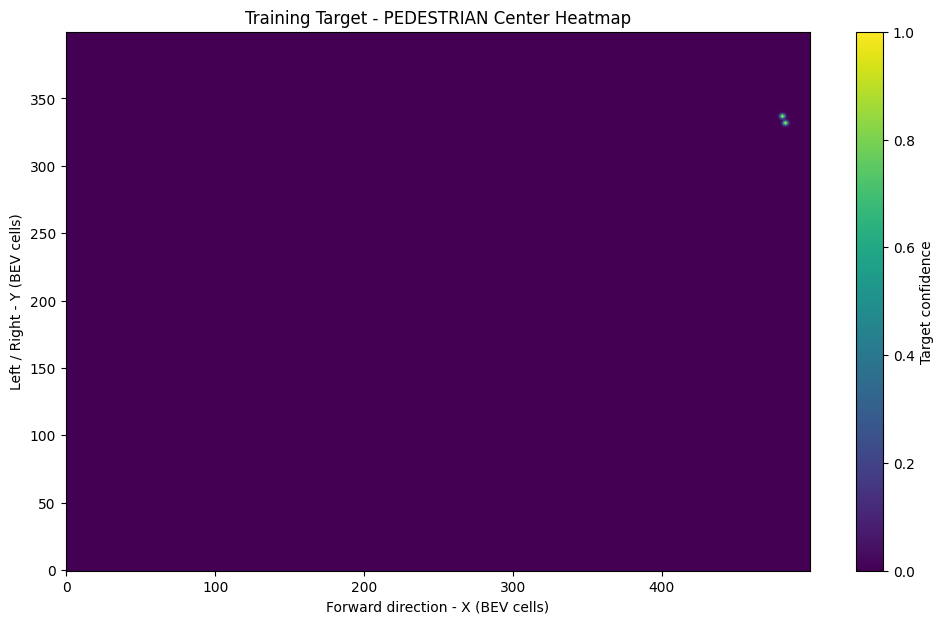

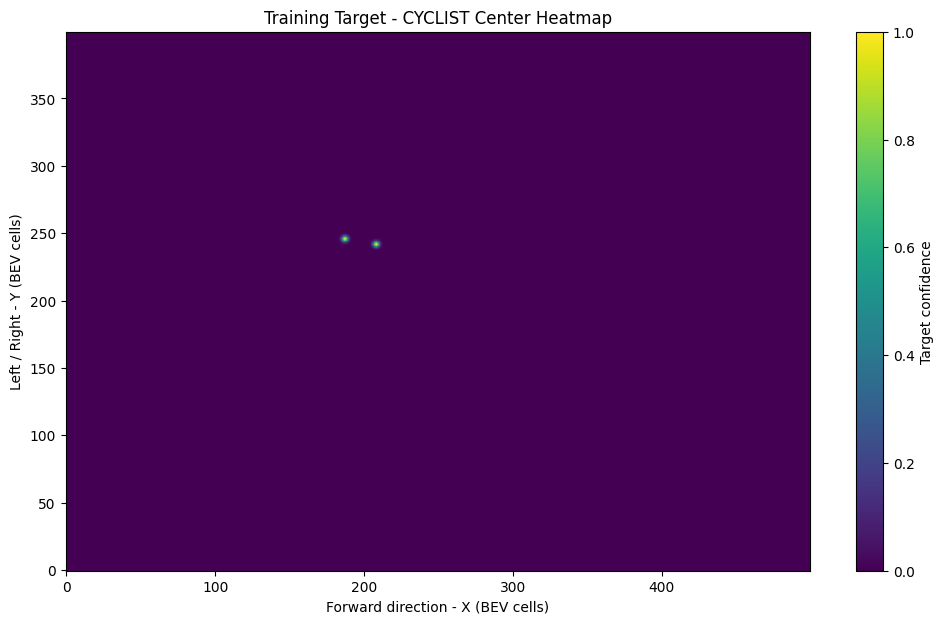

In [21]:
# ============================================================
# Create AI Training Target Heatmaps
# KITTI Frame 000201
#
# Channel 0 = Car
# Channel 1 = Pedestrian
# Channel 2 = Cyclist
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch


# ============================================================
# 1. Define our classes
# ============================================================

class_to_id = {
    "Car": 0,
    "Pedestrian": 1,
    "Cyclist": 2
}

id_to_class = {
    0: "Car",
    1: "Pedestrian",
    2: "Cyclist"
}

num_classes = len(class_to_id)


# ============================================================
# 2. Create empty target heatmaps
#
# Shape:
# [3, 500, 400]
# ============================================================

target_heatmaps = np.zeros(
    (
        num_classes,
        bev_height,
        bev_width
    ),
    dtype=np.float32
)


# ============================================================
# 3. Function to draw a Gaussian around an object center
# ============================================================

def draw_gaussian(
    heatmap,
    center_x,
    center_y,
    radius=4
):
    """
    Draw a 2D Gaussian peak on a BEV heatmap.

    center_x corresponds to forward direction.
    center_y corresponds to left/right direction.
    """

    center_x = int(round(center_x))
    center_y = int(round(center_y))


    # --------------------------------------------------------
    # Ignore invalid centers
    # --------------------------------------------------------

    if not (
        0 <= center_x < heatmap.shape[0]
        and
        0 <= center_y < heatmap.shape[1]
    ):
        return


    # Gaussian size
    diameter = 2 * radius + 1


    # --------------------------------------------------------
    # Create Gaussian kernel
    # --------------------------------------------------------

    sigma = diameter / 6.0

    x = np.arange(
        -radius,
        radius + 1
    )

    y = np.arange(
        -radius,
        radius + 1
    )

    xx, yy = np.meshgrid(
        x,
        y,
        indexing="ij"
    )


    gaussian = np.exp(
        -(
            xx**2 + yy**2
        ) / (
            2 * sigma**2
        )
    )


    # --------------------------------------------------------
    # Determine valid region in heatmap
    # --------------------------------------------------------

    x_min = max(
        0,
        center_x - radius
    )

    x_max = min(
        heatmap.shape[0],
        center_x + radius + 1
    )

    y_min = max(
        0,
        center_y - radius
    )

    y_max = min(
        heatmap.shape[1],
        center_y + radius + 1
    )


    # --------------------------------------------------------
    # Corresponding Gaussian crop
    # --------------------------------------------------------

    gx_min = x_min - (
        center_x - radius
    )

    gx_max = diameter - (
        center_x + radius + 1 - x_max
    )

    gy_min = y_min - (
        center_y - radius
    )

    gy_max = diameter - (
        center_y + radius + 1 - y_max
    )


    # --------------------------------------------------------
    # Write Gaussian using maximum
    # --------------------------------------------------------

    heatmap[
        x_min:x_max,
        y_min:y_max
    ] = np.maximum(
        heatmap[
            x_min:x_max,
            y_min:y_max
        ],
        gaussian[
            gx_min:gx_max,
            gy_min:gy_max
        ]
    )


# ============================================================
# 4. Add every KITTI object to its class heatmap
# ============================================================

print("Creating targets:\n")


for obj in bev_gt_boxes:

    object_type = obj["type"]

    class_id = class_to_id[
        object_type
    ]


    center_x = obj["center_x"]
    center_y = obj["center_y"]


    # --------------------------------------------------------
    # Use slightly different radius depending on class
    # --------------------------------------------------------

    if object_type == "Car":
        radius = 5

    elif object_type == "Pedestrian":
        radius = 3

    else:
        radius = 4


    draw_gaussian(
        target_heatmaps[class_id],
        center_x,
        center_y,
        radius=radius
    )


    print(
        f"{object_type:10s} | "
        f"class={class_id} | "
        f"BEV center=({center_x:.1f}, {center_y:.1f})"
    )


# ============================================================
# 5. Convert target heatmaps to PyTorch
# ============================================================

target_tensor = torch.from_numpy(
    target_heatmaps
).float()


# Add batch dimension
target_tensor = (
    target_tensor
    .unsqueeze(0)
    .to(device)
)


print("\n==========================================")
print("TRAINING DATA SHAPES")
print("==========================================")

print(
    "Input BEV tensor :",
    bev_tensor.shape
)

print(
    "Target tensor    :",
    target_tensor.shape
)

print(
    "Input device     :",
    bev_tensor.device
)

print(
    "Target device    :",
    target_tensor.device
)


# ============================================================
# 6. Count target peaks
# ============================================================

for class_id in range(num_classes):

    class_name = id_to_class[class_id]

    max_value = (
        target_heatmaps[class_id].max()
    )

    print(
        f"{class_name:10s} "
        f"heatmap max = {max_value:.1f}"
    )


# ============================================================
# 7. Visualize CAR target heatmap
# ============================================================

plt.figure(figsize=(12, 7))

plt.imshow(
    target_heatmaps[0].T,
    origin="lower",
    aspect="auto"
)

plt.xlabel(
    "Forward direction - X (BEV cells)"
)

plt.ylabel(
    "Left / Right - Y (BEV cells)"
)

plt.title(
    "Training Target - CAR Center Heatmap"
)

plt.colorbar(
    label="Target confidence"
)

plt.show()


# ============================================================
# 8. Visualize PEDESTRIAN target heatmap
# ============================================================

plt.figure(figsize=(12, 7))

plt.imshow(
    target_heatmaps[1].T,
    origin="lower",
    aspect="auto"
)

plt.xlabel(
    "Forward direction - X (BEV cells)"
)

plt.ylabel(
    "Left / Right - Y (BEV cells)"
)

plt.title(
    "Training Target - PEDESTRIAN Center Heatmap"
)

plt.colorbar(
    label="Target confidence"
)

plt.show()


# ============================================================
# 9. Visualize CYCLIST target heatmap
# ============================================================

plt.figure(figsize=(12, 7))

plt.imshow(
    target_heatmaps[2].T,
    origin="lower",
    aspect="auto"
)

plt.xlabel(
    "Forward direction - X (BEV cells)"
)

plt.ylabel(
    "Left / Right - Y (BEV cells)"
)

plt.title(
    "Training Target - CYCLIST Center Heatmap"
)

plt.colorbar(
    label="Target confidence"
)

plt.show()

In [24]:
# ============================================================
# Build a reusable KITTI -> BEV training-sample function
#
# Input:
#   frame ID, e.g. "000201"
#
# Output:
#   BEV input   : [3, 500, 400]
#   GT heatmaps : [3, 500, 400]
# ============================================================

import numpy as np
import torch
from pathlib import Path


# ============================================================
# Configuration
# ============================================================

DATA_ROOT = Path("Data/training")

X_MIN, X_MAX = 0.0, 50.0
Y_MIN, Y_MAX = -20.0, 20.0
Z_MIN, Z_MAX = -3.0, 2.0

RESOLUTION = 0.10

BEV_H = int((X_MAX - X_MIN) / RESOLUTION)   # 500
BEV_W = int((Y_MAX - Y_MIN) / RESOLUTION)   # 400


CLASS_TO_ID = {
    "Car": 0,
    "Pedestrian": 1,
    "Cyclist": 2
}


# ============================================================
# Gaussian helper
# ============================================================

def draw_gaussian_target(
    heatmap,
    center_x,
    center_y,
    radius
):

    center_x = int(round(center_x))
    center_y = int(round(center_y))

    if not (
        0 <= center_x < heatmap.shape[0]
        and
        0 <= center_y < heatmap.shape[1]
    ):
        return

    diameter = 2 * radius + 1
    sigma = diameter / 6.0

    coords = np.arange(
        -radius,
        radius + 1
    )

    xx, yy = np.meshgrid(
        coords,
        coords,
        indexing="ij"
    )

    gaussian = np.exp(
        -(xx**2 + yy**2)
        /
        (2 * sigma**2)
    )


    x_min = max(
        0,
        center_x - radius
    )

    x_max = min(
        heatmap.shape[0],
        center_x + radius + 1
    )

    y_min = max(
        0,
        center_y - radius
    )

    y_max = min(
        heatmap.shape[1],
        center_y + radius + 1
    )


    gx_min = x_min - (
        center_x - radius
    )

    gx_max = diameter - (
        center_x + radius + 1 - x_max
    )

    gy_min = y_min - (
        center_y - radius
    )

    gy_max = diameter - (
        center_y + radius + 1 - y_max
    )


    heatmap[
        x_min:x_max,
        y_min:y_max
    ] = np.maximum(
        heatmap[
            x_min:x_max,
            y_min:y_max
        ],
        gaussian[
            gx_min:gx_max,
            gy_min:gy_max
        ]
    )


# ============================================================
# Main sample-building function
# ============================================================

def build_kitti_training_sample(frame_id):

    # --------------------------------------------------------
    # File paths
    # --------------------------------------------------------

    lidar_file = (
        DATA_ROOT
        / "velodyne"
        / f"{frame_id}.bin"
    )

    label_file = (
        DATA_ROOT
        / "label_2"
        / f"{frame_id}.txt"
    )

    calib_file = (
        DATA_ROOT
        / "calib"
        / f"{frame_id}.txt"
    )


    # ========================================================
    # 1. Load LiDAR
    # ========================================================

    points = np.fromfile(
        lidar_file,
        dtype=np.float32
    ).reshape(-1, 4)


    # ROI
    mask = (
        (points[:, 0] >= X_MIN) &
        (points[:, 0] <  X_MAX) &

        (points[:, 1] >= Y_MIN) &
        (points[:, 1] <  Y_MAX) &

        (points[:, 2] >= Z_MIN) &
        (points[:, 2] <  Z_MAX)
    )

    points = points[mask]


    # ========================================================
    # 2. Build BEV input
    # ========================================================

    height_map = np.zeros(
        (BEV_H, BEV_W),
        dtype=np.float32
    )

    intensity_map = np.zeros(
        (BEV_H, BEV_W),
        dtype=np.float32
    )

    density_map = np.zeros(
        (BEV_H, BEV_W),
        dtype=np.float32
    )


    xi = (
        (points[:, 0] - X_MIN)
        / RESOLUTION
    ).astype(np.int32)

    yi = (
        (points[:, 1] - Y_MIN)
        / RESOLUTION
    ).astype(np.int32)


    normalized_z = (
        points[:, 2] - Z_MIN
    ) / (
        Z_MAX - Z_MIN
    )


    np.maximum.at(
        height_map,
        (xi, yi),
        normalized_z
    )


    np.maximum.at(
        intensity_map,
        (xi, yi),
        points[:, 3]
    )


    np.add.at(
        density_map,
        (xi, yi),
        1
    )


    density_map = np.minimum(
        1.0,
        np.log1p(density_map)
        / np.log(64)
    )


    bev = np.stack(
        [
            height_map,
            intensity_map,
            density_map
        ],
        axis=0
    )


    # ========================================================
    # 3. Read calibration
    # ========================================================

    calib = {}

    with open(calib_file, "r") as f:

        for line in f:

            line = line.strip()

            if not line or ":" not in line:
                continue

            key, value = line.split(
                ":",
                1
            )

            calib[key] = np.array(
                [
                    float(v)
                    for v in value.split()
                ],
                dtype=np.float64
            )


    R0 = calib[
        "R0_rect"
    ].reshape(3, 3)

    R0_4 = np.eye(4)

    R0_4[:3, :3] = R0


    Tr = calib[
        "Tr_velo_to_cam"
    ].reshape(3, 4)

    Tr_4 = np.eye(4)

    Tr_4[:3, :] = Tr


    T_camera_from_lidar = (
        R0_4 @ Tr_4
    )

    T_lidar_from_camera = (
        np.linalg.inv(
            T_camera_from_lidar
        )
    )


    # ========================================================
    # 4. Create target heatmaps
    # ========================================================

    targets = np.zeros(
        (
            3,
            BEV_H,
            BEV_W
        ),
        dtype=np.float32
    )


    object_counts = {
        "Car": 0,
        "Pedestrian": 0,
        "Cyclist": 0
    }


    with open(label_file, "r") as f:

        for line in f:

            values = (
                line.strip().split()
            )

            if len(values) < 15:
                continue


            object_type = values[0]


            if object_type not in CLASS_TO_ID:
                continue


            # KITTI camera position
            x_cam = float(values[11])
            y_cam = float(values[12])
            z_cam = float(values[13])


            camera_point = np.array(
                [
                    x_cam,
                    y_cam,
                    z_cam,
                    1.0
                ]
            )


            lidar_point = (
                T_lidar_from_camera
                @ camera_point
            )


            x_lidar = lidar_point[0]
            y_lidar = lidar_point[1]


            # Object outside our BEV region
            if not (
                X_MIN <= x_lidar < X_MAX
                and
                Y_MIN <= y_lidar < Y_MAX
            ):
                continue


            center_x = (
                x_lidar - X_MIN
            ) / RESOLUTION

            center_y = (
                y_lidar - Y_MIN
            ) / RESOLUTION


            class_id = CLASS_TO_ID[
                object_type
            ]


            if object_type == "Car":
                radius = 5

            elif object_type == "Pedestrian":
                radius = 3

            else:
                radius = 4


            draw_gaussian_target(
                targets[class_id],
                center_x,
                center_y,
                radius
            )


            object_counts[
                object_type
            ] += 1


    # ========================================================
    # 5. Convert to PyTorch tensors
    # ========================================================

    bev_tensor_sample = (
        torch.from_numpy(bev)
        .float()
    )

    target_tensor_sample = (
        torch.from_numpy(targets)
        .float()
    )


    return (
        bev_tensor_sample,
        target_tensor_sample,
        object_counts
    )


# ============================================================
# TEST the function on several different KITTI frames
# ============================================================

test_frames = [
    "000049",
    "000146",
    "000169",
    "000201"
]


print("==========================================")
print("MULTI-FRAME DATA PIPELINE TEST")
print("==========================================\n")


for frame in test_frames:

    bev_sample, target_sample, counts = (
        build_kitti_training_sample(
            frame
        )
    )


    print(
        f"Frame {frame}"
    )

    print(
        "  BEV shape   :",
        tuple(bev_sample.shape)
    )

    print(
        "  Target shape:",
        tuple(target_sample.shape)
    )

    print(
        "  Objects     :",
        counts
    )

    print(
        "  Target max  :",
        target_sample.max().item()
    )

    print()

MULTI-FRAME DATA PIPELINE TEST

Frame 000049
  BEV shape   : (3, 500, 400)
  Target shape: (3, 500, 400)
  Objects     : {'Car': 14, 'Pedestrian': 2, 'Cyclist': 0}
  Target max  : 1.0

Frame 000146
  BEV shape   : (3, 500, 400)
  Target shape: (3, 500, 400)
  Objects     : {'Car': 15, 'Pedestrian': 1, 'Cyclist': 0}
  Target max  : 1.0

Frame 000169
  BEV shape   : (3, 500, 400)
  Target shape: (3, 500, 400)
  Objects     : {'Car': 14, 'Pedestrian': 0, 'Cyclist': 0}
  Target max  : 1.0

Frame 000201
  BEV shape   : (3, 500, 400)
  Target shape: (3, 500, 400)
  Objects     : {'Car': 8, 'Pedestrian': 2, 'Cyclist': 2}
  Target max  : 1.0



In [25]:
# ============================================================
# Create PyTorch Dataset + DataLoader for KITTI LiDAR
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np


# ============================================================
# 1. Find valid KITTI frames
# ============================================================

velodyne_dir = DATA_ROOT / "velodyne"
label_dir = DATA_ROOT / "label_2"
calib_dir = DATA_ROOT / "calib"


all_frame_ids = []


for lidar_file in sorted(
    velodyne_dir.glob("*.bin")
):

    frame_id = lidar_file.stem

    label_file = (
        label_dir /
        f"{frame_id}.txt"
    )

    calib_file = (
        calib_dir /
        f"{frame_id}.txt"
    )

    if (
        label_file.exists()
        and
        calib_file.exists()
    ):

        all_frame_ids.append(
            frame_id
        )


print(
    "Total valid KITTI frames:",
    len(all_frame_ids)
)


# ============================================================
# 2. Keep frames containing at least one useful road user
# ============================================================

def frame_has_target_object(
    frame_id
):

    label_file = (
        label_dir /
        f"{frame_id}.txt"
    )

    with open(
        label_file,
        "r"
    ) as f:

        for line in f:

            values = (
                line.strip()
                .split()
            )

            if len(values) == 0:
                continue

            if values[0] in [
                "Car",
                "Pedestrian",
                "Cyclist"
            ]:

                return True

    return False


usable_frame_ids = [
    frame_id
    for frame_id in all_frame_ids
    if frame_has_target_object(
        frame_id
    )
]


print(
    "Frames with target objects:",
    len(usable_frame_ids)
)


# ============================================================
# 3. Shuffle reproducibly
# ============================================================

rng = np.random.default_rng(
    42
)

usable_frame_ids = np.array(
    usable_frame_ids
)

rng.shuffle(
    usable_frame_ids
)


# ============================================================
# 4. Create a DEVELOPMENT subset first
#
# We will scale this later.
# ============================================================

development_frames = (
    usable_frame_ids[:320]
)


train_frame_ids = (
    development_frames[:256]
)

validation_frame_ids = (
    development_frames[256:320]
)


print(
    "\nTraining frames:",
    len(train_frame_ids)
)

print(
    "Validation frames:",
    len(validation_frame_ids)
)


# ============================================================
# 5. PyTorch Dataset
# ============================================================

class KITTIBEVDataSet(
    Dataset
):

    def __init__(
        self,
        frame_ids
    ):

        self.frame_ids = list(
            frame_ids
        )


    def __len__(
        self
    ):

        return len(
            self.frame_ids
        )


    def __getitem__(
        self,
        index
    ):

        frame_id = (
            self.frame_ids[index]
        )


        bev_sample, target_sample, _ = (
            build_kitti_training_sample(
                frame_id
            )
        )


        return (
            bev_sample,
            target_sample,
            frame_id
        )


# ============================================================
# 6. Create training and validation datasets
# ============================================================

train_dataset = KITTIBEVDataSet(
    train_frame_ids
)

validation_dataset = KITTIBEVDataSet(
    validation_frame_ids
)


print(
    "\nTrain dataset length:",
    len(train_dataset)
)

print(
    "Validation dataset length:",
    len(validation_dataset)
)


# ============================================================
# 7. Create DataLoader
#
# IMPORTANT:
# num_workers=0 is intentional for Jupyter + Windows.
# ============================================================

BATCH_SIZE = 4


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True,

    drop_last=True
)


validation_loader = DataLoader(

    validation_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True
)


print(
    "\nTraining batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(validation_loader)
)


# ============================================================
# 8. Load ONE batch
# ============================================================

bev_batch, target_batch, frame_batch = (
    next(
        iter(train_loader)
    )
)


print(
    "\n=========================================="
)

print(
    "FIRST TRAINING BATCH"
)

print(
    "=========================================="
)


print(
    "\nFrames:"
)

print(
    list(frame_batch)
)


print(
    "\nBEV batch shape:"
)

print(
    bev_batch.shape
)


print(
    "\nTarget batch shape:"
)

print(
    target_batch.shape
)


# ============================================================
# 9. Move batch to GPU
# ============================================================

bev_batch = bev_batch.to(
    device,
    non_blocking=True
)

target_batch = target_batch.to(
    device,
    non_blocking=True
)


print(
    "\nBEV device:",
    bev_batch.device
)

print(
    "Target device:",
    target_batch.device
)


# ============================================================
# 10. GPU memory check
# ============================================================

if torch.cuda.is_available():

    torch.cuda.synchronize()

    allocated = (
        torch.cuda.memory_allocated()
        /
        1024**3
    )

    reserved = (
        torch.cuda.memory_reserved()
        /
        1024**3
    )


    print(
        "\nGPU memory allocated:",
        round(
            allocated,
            3
        ),
        "GB"
    )

    print(
        "GPU memory reserved:",
        round(
            reserved,
            3
        ),
        "GB"
    )


print(
    "\n✅ Multi-frame DataLoader works!"
)

Total valid KITTI frames: 7481
Frames with target objects: 7481

Training frames: 256
Validation frames: 64

Train dataset length: 256
Validation dataset length: 64

Training batches: 64
Validation batches: 16

FIRST TRAINING BATCH

Frames:
[np.str_('005302'), np.str_('002904'), np.str_('006542'), np.str_('007107')]

BEV batch shape:
torch.Size([4, 3, 500, 400])

Target batch shape:
torch.Size([4, 3, 500, 400])

BEV device: cuda:0
Target device: cuda:0

GPU memory allocated: 0.029 GB
GPU memory reserved: 0.156 GB

✅ Multi-frame DataLoader works!


STRIDE-4 CENTER DETECTOR TEST

Input BEV size:
500 x 400

Output heatmap size:
125 x 100

Output cell resolution: 0.4 meters

Objects in frame: {'Car': 8, 'Pedestrian': 2, 'Cyclist': 2}

Full target shape: torch.Size([3, 500, 400])
Low-resolution target shape: torch.Size([3, 125, 100])

Model parameters: 850,851
Input shape : torch.Size([1, 3, 500, 400])
Output shape: torch.Size([1, 3, 125, 100])
Target shape: torch.Size([1, 3, 125, 100])
Step   1/400 | Loss = 6.75876
Step  50/400 | Loss = 0.23577
Step 100/400 | Loss = 0.00013
Step 150/400 | Loss = 0.00003
Step 200/400 | Loss = 0.00002
Step 250/400 | Loss = 0.00002
Step 300/400 | Loss = 0.00001
Step 350/400 | Loss = 0.00001
Step 400/400 | Loss = 0.00001

Training time: 25.0 seconds

Initial loss: 6.75876
Final loss: 1e-05

LOCALIZATION SANITY CHECK

Car
GT centers: 8
Max confidence: 0.9947

Pedestrian
GT centers: 2
Max confidence: 0.9808

Cyclist
GT centers: 2
Max confidence: 0.9886

OVERALL ONE-FRAME RESULT

Objects tested: 12
Peak wi

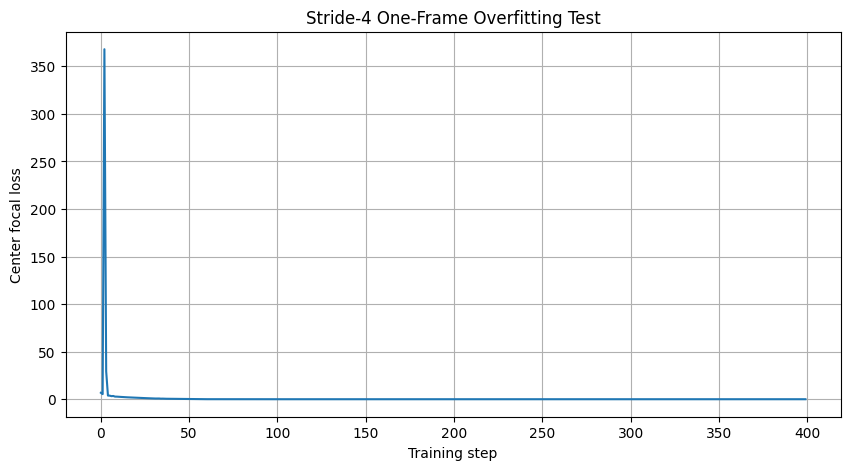

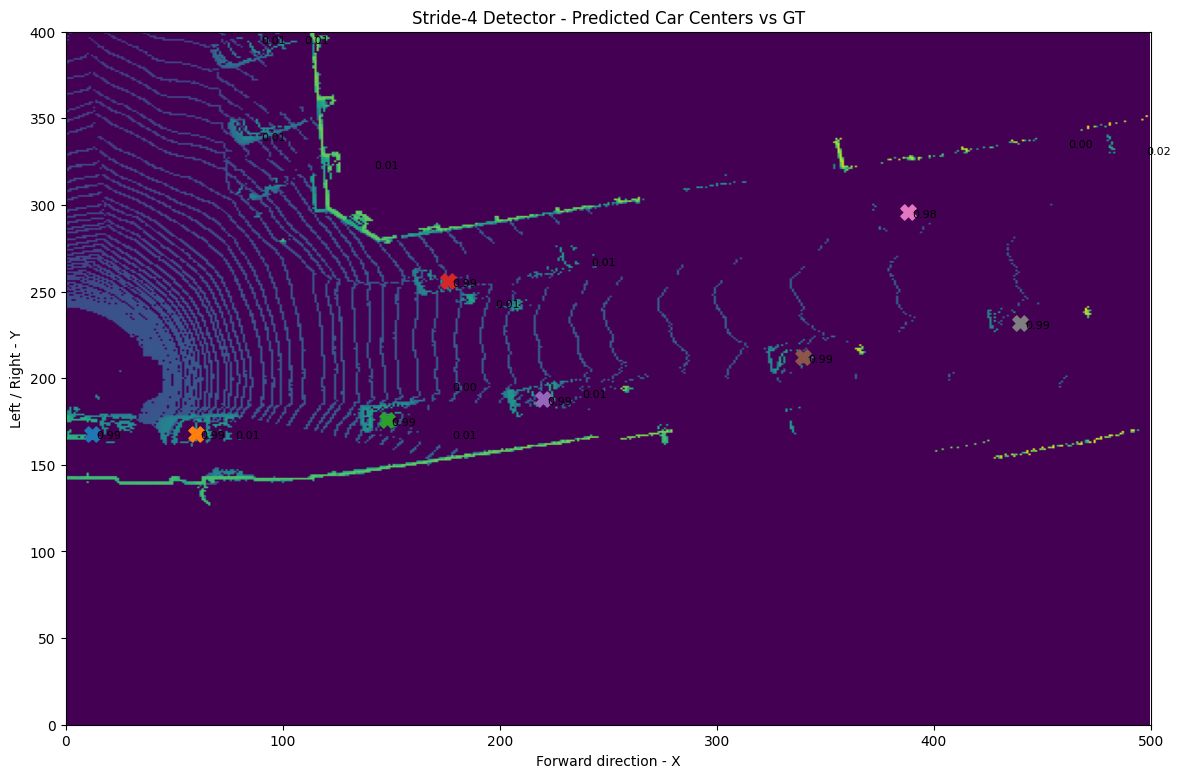

In [31]:
# ============================================================
# REDESIGNED CENTER DETECTOR - STRIDE 4
#
# Goal:
# Prove that a lower-resolution detection head can actually
# learn WHERE objects are before we train many KITTI frames.
#
# Input:
#   [1, 3, 500, 400]
#
# Output:
#   [1, 3, 125, 100]
#
# Output resolution:
#   0.4 meter per cell
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
import gc


# ============================================================
# 1. Configuration
# ============================================================

DEBUG_FRAME = "000201"

OUTPUT_STRIDE = 4

OUTPUT_H = BEV_H // OUTPUT_STRIDE
OUTPUT_W = BEV_W // OUTPUT_STRIDE

OUTPUT_RESOLUTION = (
    RESOLUTION * OUTPUT_STRIDE
)


print("==========================================")
print("STRIDE-4 CENTER DETECTOR TEST")
print("==========================================")

print("\nInput BEV size:")
print(BEV_H, "x", BEV_W)

print("\nOutput heatmap size:")
print(OUTPUT_H, "x", OUTPUT_W)

print(
    "\nOutput cell resolution:",
    OUTPUT_RESOLUTION,
    "meters"
)


# ============================================================
# 2. Load one known frame
# ============================================================

bev_debug, target_full_debug, counts_debug = (
    build_kitti_training_sample(
        DEBUG_FRAME
    )
)


print(
    "\nObjects in frame:",
    counts_debug
)


# ============================================================
# 3. Downsample GT target heatmap by 4
#
# Full target:
# [3, 500, 400]
#
# New target:
# [3, 125, 100]
#
# Max pooling preserves object-center peaks.
# ============================================================

target_low_debug = F.max_pool2d(
    target_full_debug.unsqueeze(0),
    kernel_size=OUTPUT_STRIDE,
    stride=OUTPUT_STRIDE
)[0]


print(
    "\nFull target shape:",
    target_full_debug.shape
)

print(
    "Low-resolution target shape:",
    target_low_debug.shape
)


# ============================================================
# 4. Small residual block using GROUP NORM
#
# GroupNorm is more stable than BatchNorm
# for small LiDAR batch sizes.
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.norm1 = nn.GroupNorm(
            8,
            channels
        )

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.norm2 = nn.GroupNorm(
            8,
            channels
        )


    def forward(self, x):

        residual = x

        x = self.conv1(x)
        x = self.norm1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = self.norm2(x)

        x = x + residual

        return F.relu(x)


# ============================================================
# 5. Stride-4 BEV center detector
# ============================================================

class Stride4CenterDetector(nn.Module):

    def __init__(
        self,
        num_classes=3
    ):

        super().__init__()


        # ----------------------------------------------------
        # 500 x 400
        # ----------------------------------------------------

        self.stem = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                32
            ),

            nn.ReLU(inplace=True),

            ResidualBlock(32)
        )


        # ----------------------------------------------------
        # 500 x 400
        # ->
        # 250 x 200
        # ----------------------------------------------------

        self.down1 = nn.Sequential(

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                64
            ),

            nn.ReLU(inplace=True),

            ResidualBlock(64)
        )


        # ----------------------------------------------------
        # 250 x 200
        # ->
        # 125 x 100
        # ----------------------------------------------------

        self.down2 = nn.Sequential(

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                16,
                128
            ),

            nn.ReLU(inplace=True),

            ResidualBlock(128),

            ResidualBlock(128)
        )


        # ----------------------------------------------------
        # Detection head
        #
        # 128 channels
        # ->
        # 3 center heatmaps
        # ----------------------------------------------------

        self.head = nn.Sequential(

            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                num_classes,
                kernel_size=1
            )
        )


        # ----------------------------------------------------
        # Start with low confidence everywhere
        # ----------------------------------------------------

        nn.init.constant_(
            self.head[-1].bias,
            -2.19
        )


    def forward(self, x):

        x = self.stem(x)

        x = self.down1(x)

        x = self.down2(x)

        x = self.head(x)

        return x


# ============================================================
# 6. Stable CenterNet-style focal loss
# ============================================================

def center_focal_loss(
    logits,
    targets,
    alpha=2.0,
    beta=4.0
):

    probabilities = torch.sigmoid(
        logits
    )

    probabilities = torch.clamp(
        probabilities,
        1e-6,
        1.0 - 1e-6
    )


    positive_mask = (
        targets == 1.0
    ).float()


    negative_mask = (
        targets < 1.0
    ).float()


    negative_weights = (
        1.0 - targets
    ) ** beta


    positive_loss = (

        torch.log(
            probabilities
        )

        *

        (
            1.0 - probabilities
        ) ** alpha

        *

        positive_mask
    )


    negative_loss = (

        torch.log(
            1.0 - probabilities
        )

        *

        probabilities ** alpha

        *

        negative_weights

        *

        negative_mask
    )


    num_positive = (
        positive_mask.sum()
        .clamp(min=1.0)
    )


    loss = -(

        positive_loss.sum()
        +
        negative_loss.sum()

    ) / num_positive


    return loss


# ============================================================
# 7. Put model + one frame on GPU
# ============================================================

gc.collect()

torch.cuda.empty_cache()


debug_model_stride4 = (
    Stride4CenterDetector(
        num_classes=3
    )
    .to(device)
)


bev_debug_gpu = (
    bev_debug
    .unsqueeze(0)
    .to(device)
)


target_low_gpu = (
    target_low_debug
    .unsqueeze(0)
    .to(device)
)


# ============================================================
# 8. Model information
# ============================================================

parameter_count = sum(

    p.numel()

    for p in debug_model_stride4.parameters()
)


print(
    "\nModel parameters:",
    f"{parameter_count:,}"
)


# Test output shape
with torch.no_grad():

    test_output = (
        debug_model_stride4(
            bev_debug_gpu
        )
    )


print(
    "Input shape :",
    bev_debug_gpu.shape
)

print(
    "Output shape:",
    test_output.shape
)

print(
    "Target shape:",
    target_low_gpu.shape
)


# ============================================================
# 9. Optimizer
# ============================================================

debug_optimizer = torch.optim.AdamW(

    debug_model_stride4.parameters(),

    lr=2e-3,

    weight_decay=1e-4
)


# ============================================================
# 10. ONE-FRAME OVERFITTING TEST
#
# If our architecture/target is correct,
# it SHOULD learn this single frame.
# ============================================================

NUM_DEBUG_STEPS = 400


debug_loss_history = []


debug_model_stride4.train()


torch.cuda.synchronize()

start_time = time.perf_counter()


for step in range(
    1,
    NUM_DEBUG_STEPS + 1
):

    debug_optimizer.zero_grad(
        set_to_none=True
    )


    # --------------------------------------------------------
    # Forward
    # --------------------------------------------------------

    logits = debug_model_stride4(
        bev_debug_gpu
    )


    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    loss = center_focal_loss(
        logits,
        target_low_gpu
    )


    # --------------------------------------------------------
    # Backpropagation
    # --------------------------------------------------------

    loss.backward()


    # --------------------------------------------------------
    # Gradient clipping
    # --------------------------------------------------------

    torch.nn.utils.clip_grad_norm_(

        debug_model_stride4.parameters(),

        max_norm=10.0
    )


    # --------------------------------------------------------
    # Update
    # --------------------------------------------------------

    debug_optimizer.step()


    debug_loss_history.append(
        loss.item()
    )


    if (
        step == 1
        or
        step % 50 == 0
    ):

        print(

            f"Step "
            f"{step:3d}/"
            f"{NUM_DEBUG_STEPS} "

            f"| Loss = "
            f"{loss.item():.5f}"
        )


torch.cuda.synchronize()

training_time = (
    time.perf_counter()
    -
    start_time
)


print(
    "\nTraining time:",
    round(
        training_time,
        1
    ),
    "seconds"
)


print(
    "\nInitial loss:",
    round(
        debug_loss_history[0],
        5
    )
)

print(
    "Final loss:",
    round(
        debug_loss_history[-1],
        5
    )
)


# ============================================================
# 11. Run inference on SAME frame
#
# For a sanity check we EXPECT overfitting.
# ============================================================

debug_model_stride4.eval()


with torch.no_grad():

    logits_debug = (
        debug_model_stride4(
            bev_debug_gpu
        )
    )


    probabilities_debug = torch.sigmoid(
        logits_debug
    )[0]


# ============================================================
# 12. Local maximum suppression
# ============================================================

pooled_debug = F.max_pool2d(

    probabilities_debug.unsqueeze(0),

    kernel_size=5,

    stride=1,

    padding=2

)[0]


peak_map_debug = (

    probabilities_debug

    *

    (
        probabilities_debug
        ==
        pooled_debug
    )
)


# ============================================================
# 13. Extract GT centers
# ============================================================

CLASS_NAMES_DEBUG = [
    "Car",
    "Pedestrian",
    "Cyclist"
]


all_distances_debug = []


print("\n==========================================")
print("LOCALIZATION SANITY CHECK")
print("==========================================")


for class_id, class_name in enumerate(
    CLASS_NAMES_DEBUG
):


    # --------------------------------------------------------
    # Ground truth centers
    # --------------------------------------------------------

    gt_positions = np.argwhere(

        target_low_debug[
            class_id
        ].numpy()

        == 1.0
    )


    # --------------------------------------------------------
    # Strongest predicted peaks
    # --------------------------------------------------------

    flat_peaks = (
        peak_map_debug[
            class_id
        ]
        .flatten()
    )


    scores, indices = torch.topk(

        flat_peaks,

        k=min(
            30,
            flat_peaks.numel()
        )
    )


    predicted_peaks = []


    for score, index in zip(
        scores,
        indices
    ):

        index = int(
            index.item()
        )

        px = (
            index // OUTPUT_W
        )

        py = (
            index % OUTPUT_W
        )


        predicted_peaks.append(
            (
                px,
                py,
                float(
                    score.item()
                )
            )
        )


    print(
        f"\n{class_name}"
    )

    print(
        "GT centers:",
        len(gt_positions)
    )

    print(
        "Max confidence:",
        round(
            predicted_peaks[0][2],
            4
        )
    )


    # --------------------------------------------------------
    # Nearest predicted peak to each GT center
    # --------------------------------------------------------

    for gt_index, gt_position in enumerate(
        gt_positions
    ):

        gx = int(
            gt_position[0]
        )

        gy = int(
            gt_position[1]
        )


        best_distance_cells = float(
            "inf"
        )


        for px, py, score in predicted_peaks:

            distance_cells = np.sqrt(

                (gx - px) ** 2

                +

                (gy - py) ** 2
            )


            if (
                distance_cells
                <
                best_distance_cells
            ):

                best_distance_cells = (
                    distance_cells
                )


        distance_meters = (

            best_distance_cells

            *

            OUTPUT_RESOLUTION
        )


        all_distances_debug.append(
            distance_meters
        )


# ============================================================
# 14. Overall localization quality
# ============================================================

all_distances_debug = np.array(
    all_distances_debug
)


print("\n==========================================")
print("OVERALL ONE-FRAME RESULT")
print("==========================================")


print(
    "\nObjects tested:",
    len(
        all_distances_debug
    )
)


print(
    "Peak within 0.5 m:",
    int(
        np.sum(
            all_distances_debug
            <= 0.5
        )
    )
)


print(
    "Peak within 1.0 m:",
    int(
        np.sum(
            all_distances_debug
            <= 1.0
        )
    )
)


print(
    "Peak within 2.0 m:",
    int(
        np.sum(
            all_distances_debug
            <= 2.0
        )
    )
)


print(
    "Mean distance:",
    round(
        all_distances_debug.mean(),
        3
    ),
    "m"
)


# ============================================================
# 15. Plot loss curve
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    debug_loss_history
)


plt.xlabel(
    "Training step"
)

plt.ylabel(
    "Center focal loss"
)

plt.title(
    "Stride-4 One-Frame Overfitting Test"
)

plt.grid(True)

plt.show()


# ============================================================
# 16. Visualize CAR prediction vs GT
#
# Convert stride-4 coordinates back to full BEV pixels
# for plotting over original LiDAR BEV.
# ============================================================

plt.figure(
    figsize=(14, 9)
)


plt.imshow(

    bev_debug[
        0
    ].numpy().T,

    origin="lower",

    aspect="auto"
)


# ------------------------------------------------------------
# GT Car centers
# ------------------------------------------------------------

car_gt_positions = np.argwhere(

    target_low_debug[
        0
    ].numpy()

    == 1.0
)


for gt_position in car_gt_positions:

    full_x = (
        gt_position[0]
        *
        OUTPUT_STRIDE
    )

    full_y = (
        gt_position[1]
        *
        OUTPUT_STRIDE
    )


    plt.scatter(

        full_x,
        full_y,

        marker="X",

        s=120
    )


# ------------------------------------------------------------
# Strongest predicted Car peaks
# ------------------------------------------------------------

car_flat = (
    peak_map_debug[0]
    .flatten()
)


car_scores, car_indices = torch.topk(

    car_flat,

    k=20
)


for score, index in zip(

    car_scores,
    car_indices
):

    index = int(
        index.item()
    )

    px = (
        index // OUTPUT_W
    )

    py = (
        index % OUTPUT_W
    )


    full_x = (
        px * OUTPUT_STRIDE
    )

    full_y = (
        py * OUTPUT_STRIDE
    )


    plt.scatter(

        full_x,
        full_y,

        marker="o",

        facecolors="none",

        s=90,

        linewidths=2
    )


    plt.text(

        full_x + 2,

        full_y - 3,

        f"{score.item():.2f}",

        fontsize=8
    )


plt.xlabel(
    "Forward direction - X"
)

plt.ylabel(
    "Left / Right - Y"
)

plt.title(
    "Stride-4 Detector - Predicted Car Centers vs GT"
)

plt.xlim(
    0,
    BEV_H
)

plt.ylim(
    0,
    BEV_W
)

plt.grid(False)

plt.show()

In [32]:
# ============================================================
# STRIDE-4 MULTI-FRAME DATASET + DATALOADER
#
# Input:
#   [3, 500, 400]
#
# Target:
#   [3, 125, 100]
#
# This prepares the real multi-frame training pipeline
# for our improved detector.
# ============================================================

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1. Configuration
# ============================================================

OUTPUT_STRIDE = 4

OUTPUT_H = BEV_H // OUTPUT_STRIDE
OUTPUT_W = BEV_W // OUTPUT_STRIDE

OUTPUT_RESOLUTION = (
    RESOLUTION * OUTPUT_STRIDE
)


print("==========================================")
print("STRIDE-4 MULTI-FRAME DATA PIPELINE")
print("==========================================")

print(
    "\nInput resolution:",
    BEV_H,
    "x",
    BEV_W
)

print(
    "Target resolution:",
    OUTPUT_H,
    "x",
    OUTPUT_W
)

print(
    "Target cell size:",
    OUTPUT_RESOLUTION,
    "meters"
)


# ============================================================
# 2. New dataset for stride-4 targets
# ============================================================

class KITTIStride4Dataset(Dataset):

    def __init__(
        self,
        frame_ids
    ):

        self.frame_ids = [
            str(frame_id)
            for frame_id in frame_ids
        ]


    def __len__(self):

        return len(
            self.frame_ids
        )


    def __getitem__(
        self,
        index
    ):

        frame_id = (
            self.frame_ids[index]
        )


        # ----------------------------------------------------
        # Existing function gives:
        #
        # BEV:
        # [3, 500, 400]
        #
        # Full target:
        # [3, 500, 400]
        # ----------------------------------------------------

        bev_sample, full_target, counts = (
            build_kitti_training_sample(
                frame_id
            )
        )


        # ----------------------------------------------------
        # Convert full target -> stride-4 target
        #
        # [3,500,400]
        #       ↓
        # [3,125,100]
        #
        # Max pooling preserves Gaussian object centers.
        # ----------------------------------------------------

        low_target = F.max_pool2d(

            full_target.unsqueeze(0),

            kernel_size=OUTPUT_STRIDE,

            stride=OUTPUT_STRIDE

        )[0]


        return (
            bev_sample,
            low_target,
            frame_id
        )


# ============================================================
# 3. Create train / validation datasets
# ============================================================

train_dataset_stride4 = (
    KITTIStride4Dataset(
        train_frame_ids
    )
)


validation_dataset_stride4 = (
    KITTIStride4Dataset(
        validation_frame_ids
    )
)


print(
    "\nTraining samples:",
    len(train_dataset_stride4)
)

print(
    "Validation samples:",
    len(validation_dataset_stride4)
)


# ============================================================
# 4. Start with batch size 6
#
# Batch size 6 is used for the stride-4 training experiments.
# ============================================================

STRIDE4_BATCH_SIZE = 6


train_loader_stride4 = DataLoader(

    train_dataset_stride4,

    batch_size=STRIDE4_BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=True,

    drop_last=True
)


validation_loader_stride4 = DataLoader(

    validation_dataset_stride4,

    batch_size=STRIDE4_BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True,

    drop_last=False
)


print(
    "\nTraining batches:",
    len(train_loader_stride4)
)

print(
    "Validation batches:",
    len(validation_loader_stride4)
)


# ============================================================
# 5. Load ONE training batch
# ============================================================

bev_batch_s4, target_batch_s4, frame_batch_s4 = (
    next(
        iter(
            train_loader_stride4
        )
    )
)


print("\n==========================================")
print("FIRST STRIDE-4 TRAINING BATCH")
print("==========================================")


print("\nFrames:")

for frame in frame_batch_s4:

    print(
        " ",
        frame
    )


print(
    "\nBEV batch shape:"
)

print(
    bev_batch_s4.shape
)


print(
    "\nTarget batch shape:"
)

print(
    target_batch_s4.shape
)


# ============================================================
# 6. Count positive object centers in this batch
# ============================================================

class_names_s4 = [
    "Car",
    "Pedestrian",
    "Cyclist"
]


print("\nObject-center peaks in batch:")


for class_id, class_name in enumerate(
    class_names_s4
):

    num_centers = torch.sum(

        target_batch_s4[
            :,
            class_id
        ]

        == 1.0

    ).item()


    print(
        f"{class_name:10s}:",
        int(num_centers)
    )


# ============================================================
# 7. Send batch to GPU
# ============================================================

bev_batch_s4 = (
    bev_batch_s4.to(
        device,
        non_blocking=True
    )
)


target_batch_s4 = (
    target_batch_s4.to(
        device,
        non_blocking=True
    )
)


print(
    "\nInput device:",
    bev_batch_s4.device
)

print(
    "Target device:",
    target_batch_s4.device
)


# ============================================================
# 8. Test model output shape
# ============================================================

stride4_test_model = (
    Stride4CenterDetector(
        num_classes=3
    )
    .to(device)
)


stride4_test_model.eval()


with torch.no_grad():

    test_prediction_s4 = (
        stride4_test_model(
            bev_batch_s4
        )
    )


print(
    "\nModel prediction shape:"
)

print(
    test_prediction_s4.shape
)


# ============================================================
# 9. Verify everything matches
# ============================================================

if (
    test_prediction_s4.shape
    ==
    target_batch_s4.shape
):

    print(
        "\n✅ Prediction and target shapes match."
    )

else:

    print(
        "\n❌ Shape mismatch."
    )


# ============================================================
# 10. Small GPU memory check
# ============================================================

if torch.cuda.is_available():

    allocated = (
        torch.cuda.memory_allocated()
        /
        1024**3
    )

    reserved = (
        torch.cuda.memory_reserved()
        /
        1024**3
    )


    print(
        "\nCurrent GPU allocated:",
        round(
            allocated,
            3
        ),
        "GB"
    )

    print(
        "Current GPU reserved:",
        round(
            reserved,
            3
        ),
        "GB"
    )


print(
    "\n✅ Stride-4 multi-frame pipeline ready."
)

STRIDE-4 MULTI-FRAME DATA PIPELINE

Input resolution: 500 x 400
Target resolution: 125 x 100
Target cell size: 0.4 meters

Training samples: 256
Validation samples: 64

Training batches: 42
Validation batches: 11

FIRST STRIDE-4 TRAINING BATCH

Frames:
  004683
  005519
  003503
  005350
  005229
  003759

BEV batch shape:
torch.Size([6, 3, 500, 400])

Target batch shape:
torch.Size([6, 3, 125, 100])

Object-center peaks in batch:
Car       : 20
Pedestrian: 6
Cyclist   : 2

Input device: cuda:0
Target device: cuda:0

Model prediction shape:
torch.Size([6, 3, 125, 100])

✅ Prediction and target shapes match.

Current GPU allocated: 0.146 GB
Current GPU reserved: 1.098 GB

✅ Stride-4 multi-frame pipeline ready.


Checkpoint path:
D:\LiDAR Project\Lidar_Project\checkpoints\stride4_bev_detector_best.pt

Model parameters: 850,851

STRIDE-4 MULTI-FRAME TRAINING

Training frames: 256
Validation frames: 64
Batch size: 6
Training batches: 42
Validation batches: 11
Epochs: 10
Device: cuda
Epoch 01/10 | Batch 01/42 | Loss 36.6961
Epoch 01/10 | Batch 10/42 | Loss 6.7507
Epoch 01/10 | Batch 20/42 | Loss 3.1180
Epoch 01/10 | Batch 30/42 | Loss 3.0118
Epoch 01/10 | Batch 40/42 | Loss 2.4890
Epoch 01/10 | Batch 42/42 | Loss 3.2729

------------------------------------------
EPOCH 1 COMPLETE
------------------------------------------
Train loss: 10.7727
Val loss  : 2.8878
Learning rate: 0.001
Epoch time: 70.1 seconds
Peak allocated: 2.284 GB
Peak reserved : 3.129 GB
✅ New best checkpoint saved

Epoch 02/10 | Batch 01/42 | Loss 2.9812
Epoch 02/10 | Batch 10/42 | Loss 2.5060
Epoch 02/10 | Batch 20/42 | Loss 2.5041
Epoch 02/10 | Batch 30/42 | Loss 2.5167
Epoch 02/10 | Batch 40/42 | Loss 2.3494
Epoch 02/10 | Batc

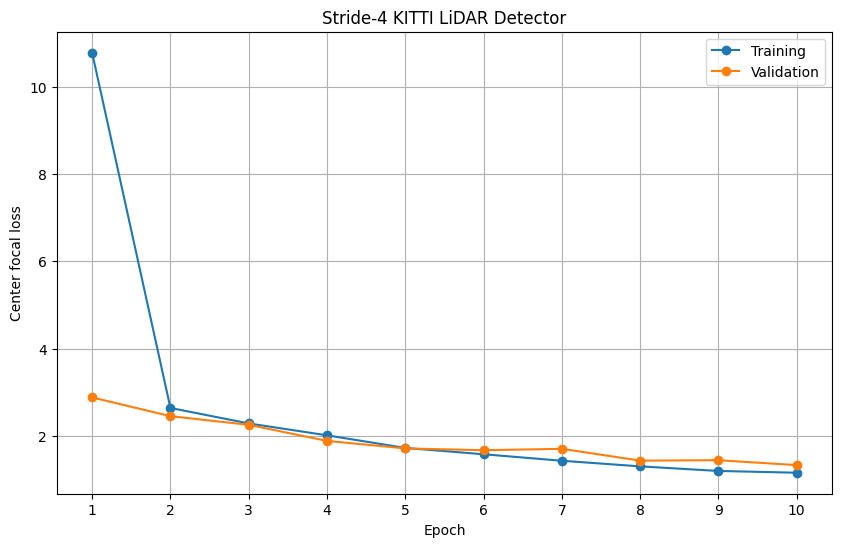


Epoch results:

Epoch   Train         Validation    LR          Time(s)   
----------------------------------------------------------
1       10.7727       2.8878        0.001000    70.1      
2       2.6476        2.4595        0.001000    69.7      
3       2.2928        2.2612        0.001000    69.8      
4       2.0213        1.8939        0.001000    69.9      
5       1.7325        1.7216        0.001000    69.9      
6       1.5880        1.6805        0.001000    69.9      
7       1.4394        1.7126        0.001000    70.1      
8       1.3113        1.4426        0.001000    70.1      
9       1.2063        1.4525        0.001000    70.2      
10      1.1657        1.3392        0.001000    70.3      


In [34]:
# ============================================================
# REAL STRIDE-4 MULTI-FRAME TRAINING
#
# Train frames      : 256
# Validation frames : 64
# Batch size        : 6
# Epochs            : 10
#
# Model:
# Stride4CenterDetector
#
# Output:
# [B, 3, 125, 100]
#
# Best checkpoint is saved inside the project checkpoints directory.
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import time
import gc


# ============================================================
# 1. Configuration
# ============================================================

NUM_EPOCHS_S4 = 10

LEARNING_RATE_S4 = 1e-3

WEIGHT_DECAY_S4 = 1e-4


# ============================================================
# 2. Checkpoint directory
# ============================================================

checkpoint_dir_s4 = Path(
    "checkpoints"
)

checkpoint_dir_s4.mkdir(
    exist_ok=True
)


best_model_path_s4 = (
    checkpoint_dir_s4
    / "stride4_bev_detector_best.pt"
)


print("Checkpoint path:")

print(
    best_model_path_s4.resolve()
)


# ============================================================
# 3. GPU cleanup
# ============================================================

gc.collect()

torch.cuda.empty_cache()


# ============================================================
# 4. Create a FRESH model
# ============================================================

train_model_s4 = (

    Stride4CenterDetector(
        num_classes=3
    )

    .to(device)
)


parameter_count_s4 = sum(

    p.numel()

    for p in train_model_s4.parameters()
)


print(
    "\nModel parameters:",
    f"{parameter_count_s4:,}"
)


# ============================================================
# 5. Optimizer
# ============================================================

optimizer_s4 = torch.optim.AdamW(

    train_model_s4.parameters(),

    lr=LEARNING_RATE_S4,

    weight_decay=WEIGHT_DECAY_S4
)


# ============================================================
# 6. Learning-rate scheduler
#
# Reduce learning rate if validation stops improving.
# ============================================================

scheduler_s4 = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer_s4,

    mode="min",

    factor=0.5,

    patience=2,

    min_lr=1e-5
)


# ============================================================
# 7. Mixed precision
# ============================================================

scaler_s4 = torch.amp.GradScaler(
    "cuda"
)


# ============================================================
# 8. History
# ============================================================

train_loss_history_s4 = []

val_loss_history_s4 = []

epoch_time_history_s4 = []

lr_history_s4 = []


best_val_loss_s4 = float(
    "inf"
)


best_epoch_s4 = 0


# ============================================================
# 9. GPU cleanup
# ============================================================

gc.collect()

torch.cuda.empty_cache()


# ============================================================
# 10. Training information
# ============================================================

print("\n==========================================")
print("STRIDE-4 MULTI-FRAME TRAINING")
print("==========================================")


print(
    "\nTraining frames:",
    len(train_dataset_stride4)
)

print(
    "Validation frames:",
    len(validation_dataset_stride4)
)

print(
    "Batch size:",
    STRIDE4_BATCH_SIZE
)

print(
    "Training batches:",
    len(train_loader_stride4)
)

print(
    "Validation batches:",
    len(validation_loader_stride4)
)

print(
    "Epochs:",
    NUM_EPOCHS_S4
)

print(
    "Device:",
    device
)


# ============================================================
# 11. EPOCH LOOP
# ============================================================

for epoch in range(
    1,
    NUM_EPOCHS_S4 + 1
):


    epoch_start = time.perf_counter()


    torch.cuda.reset_peak_memory_stats()


    # ========================================================
    # TRAINING
    # ========================================================

    train_model_s4.train()


    running_train_loss = 0.0

    train_batches = 0


    for batch_index, (
        bev_batch,
        target_batch,
        frame_ids
    ) in enumerate(
        train_loader_stride4,
        start=1
    ):


        # ----------------------------------------------------
        # Move data to GPU
        # ----------------------------------------------------

        bev_batch = bev_batch.to(

            device,

            non_blocking=True
        )


        target_batch = target_batch.to(

            device,

            non_blocking=True
        )


        # ----------------------------------------------------
        # Clear old gradients
        # ----------------------------------------------------

        optimizer_s4.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Mixed precision forward
        # ----------------------------------------------------

        with torch.amp.autocast(

            device_type="cuda",

            dtype=torch.float16
        ):

            prediction = (
                train_model_s4(
                    bev_batch
                )
            )


        # ----------------------------------------------------
        # Loss in float32
        # ----------------------------------------------------

        loss = center_focal_loss(

            prediction.float(),

            target_batch.float()
        )


        # ----------------------------------------------------
        # Backprop
        # ----------------------------------------------------

        scaler_s4.scale(
            loss
        ).backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        scaler_s4.unscale_(
            optimizer_s4
        )


        torch.nn.utils.clip_grad_norm_(

            train_model_s4.parameters(),

            max_norm=10.0
        )


        # ----------------------------------------------------
        # Update model
        # ----------------------------------------------------

        scaler_s4.step(
            optimizer_s4
        )


        scaler_s4.update()


        # ----------------------------------------------------
        # Record training loss
        # ----------------------------------------------------

        running_train_loss += (
            loss.item()
        )

        train_batches += 1


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            batch_index == 1
            or
            batch_index % 10 == 0
            or
            batch_index
            == len(train_loader_stride4)
        ):

            print(

                f"Epoch "
                f"{epoch:02d}/"
                f"{NUM_EPOCHS_S4:02d} "

                f"| Batch "
                f"{batch_index:02d}/"
                f"{len(train_loader_stride4):02d} "

                f"| Loss "
                f"{loss.item():.4f}"
            )


    # ========================================================
    # Average training loss
    # ========================================================

    average_train_loss = (

        running_train_loss
        /
        train_batches
    )


    train_loss_history_s4.append(
        average_train_loss
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    train_model_s4.eval()


    running_val_loss = 0.0

    val_batches = 0


    with torch.no_grad():


        for (
            bev_batch,
            target_batch,
            frame_ids
        ) in validation_loader_stride4:


            bev_batch = bev_batch.to(

                device,

                non_blocking=True
            )


            target_batch = target_batch.to(

                device,

                non_blocking=True
            )


            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            with torch.amp.autocast(

                device_type="cuda",

                dtype=torch.float16
            ):

                prediction = (
                    train_model_s4(
                        bev_batch
                    )
                )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            val_loss = center_focal_loss(

                prediction.float(),

                target_batch.float()
            )


            running_val_loss += (
                val_loss.item()
            )


            val_batches += 1


    # ========================================================
    # Average validation loss
    # ========================================================

    average_val_loss = (

        running_val_loss
        /
        val_batches
    )


    val_loss_history_s4.append(
        average_val_loss
    )


    # ========================================================
    # Scheduler
    # ========================================================

    scheduler_s4.step(
        average_val_loss
    )


    current_lr = (
        optimizer_s4
        .param_groups[0]["lr"]
    )


    lr_history_s4.append(
        current_lr
    )


    # ========================================================
    # Save BEST model
    # ========================================================

    saved_best = False


    if (
        average_val_loss
        <
        best_val_loss_s4
    ):

        best_val_loss_s4 = (
            average_val_loss
        )


        best_epoch_s4 = epoch


        torch.save(

            {

                "epoch":
                    epoch,

                "model_state_dict":
                    train_model_s4.state_dict(),

                "optimizer_state_dict":
                    optimizer_s4.state_dict(),

                "train_loss":
                    average_train_loss,

                "validation_loss":
                    average_val_loss,

                "learning_rate":
                    current_lr,

                "output_stride":
                    OUTPUT_STRIDE,

                "output_resolution":
                    OUTPUT_RESOLUTION

            },

            best_model_path_s4
        )


        saved_best = True


    # ========================================================
    # Timing
    # ========================================================

    torch.cuda.synchronize()


    epoch_time = (

        time.perf_counter()

        -

        epoch_start
    )


    epoch_time_history_s4.append(
        epoch_time
    )


    # ========================================================
    # GPU memory
    # ========================================================

    peak_allocated = (

        torch.cuda.max_memory_allocated()

        /

        1024**3
    )


    peak_reserved = (

        torch.cuda.max_memory_reserved()

        /

        1024**3
    )


    # ========================================================
    # Epoch report
    # ========================================================

    print("\n------------------------------------------")

    print(
        f"EPOCH {epoch} COMPLETE"
    )

    print("------------------------------------------")


    print(
        "Train loss:",
        round(
            average_train_loss,
            4
        )
    )


    print(
        "Val loss  :",
        round(
            average_val_loss,
            4
        )
    )


    print(
        "Learning rate:",
        current_lr
    )


    print(
        "Epoch time:",
        round(
            epoch_time,
            1
        ),
        "seconds"
    )


    print(
        "Peak allocated:",
        round(
            peak_allocated,
            3
        ),
        "GB"
    )


    print(
        "Peak reserved :",
        round(
            peak_reserved,
            3
        ),
        "GB"
    )


    if saved_best:

        print(
            "✅ New best checkpoint saved"
        )


    print()


# ============================================================
# 12. Training finished
# ============================================================

print("\n==========================================")
print("STRIDE-4 TRAINING COMPLETE")
print("==========================================")


print(
    "\nBest epoch:",
    best_epoch_s4
)


print(
    "Best validation loss:",
    round(
        best_val_loss_s4,
        5
    )
)


print(
    "\nCheckpoint:"
)

print(
    best_model_path_s4.resolve()
)


# ============================================================
# 13. Plot loss curves
# ============================================================

epochs_s4 = np.arange(
    1,
    NUM_EPOCHS_S4 + 1
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    epochs_s4,

    train_loss_history_s4,

    marker="o",

    label="Training"
)


plt.plot(

    epochs_s4,

    val_loss_history_s4,

    marker="o",

    label="Validation"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Center focal loss"
)

plt.title(
    "Stride-4 KITTI LiDAR Detector"
)

plt.xticks(
    epochs_s4
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 14. Final results table
# ============================================================

print("\nEpoch results:\n")


print(

    f"{'Epoch':<8}"

    f"{'Train':<14}"

    f"{'Validation':<14}"

    f"{'LR':<12}"

    f"{'Time(s)':<10}"
)


print(
    "-" * 58
)


for i in range(
    NUM_EPOCHS_S4
):

    print(

        f"{i + 1:<8}"

        f"{train_loss_history_s4[i]:<14.4f}"

        f"{val_loss_history_s4[i]:<14.4f}"

        f"{lr_history_s4[i]:<12.6f}"

        f"{epoch_time_history_s4[i]:<10.1f}"
    )

In [37]:
import sys
import gc
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# 1. Verify Python / GPU
# ============================================================

print("==========================================")
print("ENVIRONMENT CHECK")
print("==========================================")

print("\nPython:")
print(sys.executable)

print("\nPyTorch:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


if torch.cuda.is_available():

    print("\nGPU:")
    print(
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 2. KITTI / BEV configuration
# ============================================================

DATA_ROOT = Path(
    "Data/training"
)


X_MIN, X_MAX = 0.0, 50.0
Y_MIN, Y_MAX = -20.0, 20.0
Z_MIN, Z_MAX = -3.0, 2.0

RESOLUTION = 0.10


BEV_H = int(
    (X_MAX - X_MIN)
    /
    RESOLUTION
)

BEV_W = int(
    (Y_MAX - Y_MIN)
    /
    RESOLUTION
)


OUTPUT_STRIDE = 4

OUTPUT_H = (
    BEV_H
    //
    OUTPUT_STRIDE
)

OUTPUT_W = (
    BEV_W
    //
    OUTPUT_STRIDE
)

OUTPUT_RESOLUTION = (
    RESOLUTION
    *
    OUTPUT_STRIDE
)


CLASS_TO_ID = {
    "Car": 0,
    "Pedestrian": 1,
    "Cyclist": 2
}


CLASS_NAMES = [
    "Car",
    "Pedestrian",
    "Cyclist"
]


print("\n==========================================")
print("BEV CONFIGURATION")
print("==========================================")

print(
    "\nInput BEV:",
    BEV_H,
    "x",
    BEV_W
)

print(
    "Stride-4 target:",
    OUTPUT_H,
    "x",
    OUTPUT_W
)

print(
    "Target resolution:",
    OUTPUT_RESOLUTION,
    "m/cell"
)


# ============================================================
# 3. Gaussian target helper
# ============================================================

def draw_gaussian_target(
    heatmap,
    center_x,
    center_y,
    radius
):

    center_x = int(
        round(center_x)
    )

    center_y = int(
        round(center_y)
    )


    if not (
        0 <= center_x < heatmap.shape[0]
        and
        0 <= center_y < heatmap.shape[1]
    ):

        return


    diameter = (
        2 * radius + 1
    )

    sigma = (
        diameter / 6.0
    )


    coords = np.arange(
        -radius,
        radius + 1
    )


    xx, yy = np.meshgrid(
        coords,
        coords,
        indexing="ij"
    )


    gaussian = np.exp(

        -(
            xx**2
            +
            yy**2
        )

        /

        (
            2
            *
            sigma**2
        )
    )


    x_min = max(
        0,
        center_x - radius
    )

    x_max = min(
        heatmap.shape[0],
        center_x + radius + 1
    )


    y_min = max(
        0,
        center_y - radius
    )

    y_max = min(
        heatmap.shape[1],
        center_y + radius + 1
    )


    gx_min = (
        x_min
        -
        (center_x - radius)
    )

    gx_max = (
        diameter
        -
        (
            center_x
            +
            radius
            +
            1
            -
            x_max
        )
    )


    gy_min = (
        y_min
        -
        (center_y - radius)
    )

    gy_max = (
        diameter
        -
        (
            center_y
            +
            radius
            +
            1
            -
            y_max
        )
    )


    heatmap[
        x_min:x_max,
        y_min:y_max
    ] = np.maximum(

        heatmap[
            x_min:x_max,
            y_min:y_max
        ],

        gaussian[
            gx_min:gx_max,
            gy_min:gy_max
        ]
    )


# ============================================================
# 4. KITTI frame -> BEV + target
# ============================================================

def build_kitti_training_sample(
    frame_id
):

    frame_id = str(
        frame_id
    )


    lidar_file = (
        DATA_ROOT
        /
        "velodyne"
        /
        f"{frame_id}.bin"
    )

    label_file = (
        DATA_ROOT
        /
        "label_2"
        /
        f"{frame_id}.txt"
    )

    calib_file = (
        DATA_ROOT
        /
        "calib"
        /
        f"{frame_id}.txt"
    )


    # ========================================================
    # LiDAR
    # ========================================================

    points = np.fromfile(
        lidar_file,
        dtype=np.float32
    ).reshape(-1, 4)


    roi_mask = (

        (points[:, 0] >= X_MIN)
        &
        (points[:, 0] < X_MAX)

        &

        (points[:, 1] >= Y_MIN)
        &
        (points[:, 1] < Y_MAX)

        &

        (points[:, 2] >= Z_MIN)
        &
        (points[:, 2] < Z_MAX)
    )


    points = points[
        roi_mask
    ]


    # ========================================================
    # BEV maps
    # ========================================================

    height_map = np.zeros(
        (BEV_H, BEV_W),
        dtype=np.float32
    )

    intensity_map = np.zeros(
        (BEV_H, BEV_W),
        dtype=np.float32
    )

    density_map = np.zeros(
        (BEV_H, BEV_W),
        dtype=np.float32
    )


    xi = (

        (
            points[:, 0]
            -
            X_MIN
        )

        /

        RESOLUTION

    ).astype(
        np.int32
    )


    yi = (

        (
            points[:, 1]
            -
            Y_MIN
        )

        /

        RESOLUTION

    ).astype(
        np.int32
    )


    normalized_z = (

        points[:, 2]
        -
        Z_MIN

    ) / (

        Z_MAX
        -
        Z_MIN
    )


    np.maximum.at(
        height_map,
        (xi, yi),
        normalized_z
    )


    np.maximum.at(
        intensity_map,
        (xi, yi),
        points[:, 3]
    )


    np.add.at(
        density_map,
        (xi, yi),
        1
    )


    density_map = np.minimum(

        1.0,

        np.log1p(
            density_map
        )

        /

        np.log(64)
    )


    bev = np.stack(
        [
            height_map,
            intensity_map,
            density_map
        ],
        axis=0
    )


    # ========================================================
    # Calibration
    # ========================================================

    calib = {}


    with open(
        calib_file,
        "r"
    ) as f:

        for line in f:

            line = (
                line.strip()
            )


            if (
                not line
                or
                ":" not in line
            ):

                continue


            key, value = line.split(
                ":",
                1
            )


            calib[key] = np.array(
                [
                    float(v)
                    for v in value.split()
                ],
                dtype=np.float64
            )


    R0 = (
        calib["R0_rect"]
        .reshape(3, 3)
    )


    R0_4 = np.eye(4)

    R0_4[
        :3,
        :3
    ] = R0


    Tr = (
        calib["Tr_velo_to_cam"]
        .reshape(3, 4)
    )


    Tr_4 = np.eye(4)

    Tr_4[
        :3,
        :
    ] = Tr


    T_camera_from_lidar = (
        R0_4
        @
        Tr_4
    )


    T_lidar_from_camera = (
        np.linalg.inv(
            T_camera_from_lidar
        )
    )


    # ========================================================
    # Full-resolution targets
    # ========================================================

    targets = np.zeros(
        (
            3,
            BEV_H,
            BEV_W
        ),
        dtype=np.float32
    )


    object_counts = {
        "Car": 0,
        "Pedestrian": 0,
        "Cyclist": 0
    }


    with open(
        label_file,
        "r"
    ) as f:

        for line in f:

            values = (
                line.strip()
                .split()
            )


            if len(values) < 15:

                continue


            object_type = (
                values[0]
            )


            if (
                object_type
                not in
                CLASS_TO_ID
            ):

                continue


            # KITTI camera coordinates
            x_cam = float(
                values[11]
            )

            y_cam = float(
                values[12]
            )

            z_cam = float(
                values[13]
            )


            camera_point = np.array(
                [
                    x_cam,
                    y_cam,
                    z_cam,
                    1.0
                ]
            )


            lidar_point = (

                T_lidar_from_camera

                @

                camera_point
            )


            x_lidar = (
                lidar_point[0]
            )

            y_lidar = (
                lidar_point[1]
            )


            if not (

                X_MIN
                <=
                x_lidar
                <
                X_MAX

                and

                Y_MIN
                <=
                y_lidar
                <
                Y_MAX
            ):

                continue


            center_x = (

                x_lidar
                -
                X_MIN

            ) / RESOLUTION


            center_y = (

                y_lidar
                -
                Y_MIN

            ) / RESOLUTION


            class_id = (
                CLASS_TO_ID[
                    object_type
                ]
            )


            if object_type == "Car":

                radius = 5


            elif object_type == "Pedestrian":

                radius = 3


            else:

                radius = 4


            draw_gaussian_target(

                targets[
                    class_id
                ],

                center_x,

                center_y,

                radius
            )


            object_counts[
                object_type
            ] += 1


    bev_tensor = (
        torch.from_numpy(
            bev
        )
        .float()
    )


    target_tensor = (
        torch.from_numpy(
            targets
        )
        .float()
    )


    return (
        bev_tensor,
        target_tensor,
        object_counts
    )


# ============================================================
# 5. Recreate EXACT 256/64 split
# ============================================================

velodyne_dir = (
    DATA_ROOT
    /
    "velodyne"
)

label_dir = (
    DATA_ROOT
    /
    "label_2"
)

calib_dir = (
    DATA_ROOT
    /
    "calib"
)


all_frame_ids = []


for lidar_file in sorted(
    velodyne_dir.glob(
        "*.bin"
    )
):

    frame_id = (
        lidar_file.stem
    )


    if (
        (
            label_dir
            /
            f"{frame_id}.txt"
        ).exists()

        and

        (
            calib_dir
            /
            f"{frame_id}.txt"
        ).exists()
    ):

        all_frame_ids.append(
            frame_id
        )


def frame_has_target_object(
    frame_id
):

    label_file = (
        label_dir
        /
        f"{frame_id}.txt"
    )


    with open(
        label_file,
        "r"
    ) as f:

        for line in f:

            values = (
                line.strip()
                .split()
            )


            if not values:

                continue


            if values[0] in CLASS_TO_ID:

                return True


    return False


usable_frame_ids = [

    frame_id

    for frame_id in all_frame_ids

    if frame_has_target_object(
        frame_id
    )
]


usable_frame_ids = np.array(
    usable_frame_ids
)


rng = np.random.default_rng(
    42
)


rng.shuffle(
    usable_frame_ids
)


development_frames = (
    usable_frame_ids[:320]
)


train_frame_ids = (
    development_frames[:256]
)


validation_frame_ids = (
    development_frames[256:320]
)


print("\n==========================================")
print("DATASET SPLIT RESTORED")
print("==========================================")

print(
    "\nTraining frames:",
    len(train_frame_ids)
)

print(
    "Validation frames:",
    len(validation_frame_ids)
)


# ============================================================
# 6. Residual block
# ============================================================

class ResidualBlock(
    nn.Module
):

    def __init__(
        self,
        channels
    ):

        super().__init__()


        self.conv1 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
            bias=False
        )


        self.norm1 = nn.GroupNorm(
            8,
            channels
        )


        self.conv2 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1,
            bias=False
        )


        self.norm2 = nn.GroupNorm(
            8,
            channels
        )


    def forward(
        self,
        x
    ):

        residual = x


        x = self.conv1(
            x
        )

        x = self.norm1(
            x
        )

        x = F.relu(
            x
        )


        x = self.conv2(
            x
        )

        x = self.norm2(
            x
        )


        x = (
            x
            +
            residual
        )


        return F.relu(
            x
        )


# ============================================================
# 7. Stride-4 detector
# ============================================================

class Stride4CenterDetector(
    nn.Module
):

    def __init__(
        self,
        num_classes=3
    ):

        super().__init__()


        self.stem = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                32
            ),

            nn.ReLU(
                inplace=True
            ),

            ResidualBlock(
                32
            )
        )


        self.down1 = nn.Sequential(

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                64
            ),

            nn.ReLU(
                inplace=True
            ),

            ResidualBlock(
                64
            )
        )


        self.down2 = nn.Sequential(

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                16,
                128
            ),

            nn.ReLU(
                inplace=True
            ),

            ResidualBlock(
                128
            ),

            ResidualBlock(
                128
            )
        )


        self.head = nn.Sequential(

            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                64,
                num_classes,
                kernel_size=1
            )
        )


    def forward(
        self,
        x
    ):

        x = self.stem(
            x
        )

        x = self.down1(
            x
        )

        x = self.down2(
            x
        )

        x = self.head(
            x
        )

        return x


# ============================================================
# 8. Load saved BEST checkpoint
# ============================================================

checkpoint_path = Path(
    "checkpoints/stride4_bev_detector_best.pt"
)


print("\nCheckpoint exists:")
print(
    checkpoint_path.exists()
)


checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)


model = (
    Stride4CenterDetector(
        num_classes=3
    )
    .to(device)
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print("\n==========================================")
print("MODEL RESTORED")
print("==========================================")

print(
    "\nCheckpoint epoch:",
    checkpoint["epoch"]
)

print(
    "Training loss:",
    round(
        checkpoint["train_loss"],
        4
    )
)

print(
    "Validation loss:",
    round(
        checkpoint["validation_loss"],
        4
    )
)

print(
    "\nModel device:",
    next(
        model.parameters()
    ).device
)


print(
    "\n✅ Project successfully restored."
)

print(
    "Ready for full 64-frame validation evaluation."
)

ENVIRONMENT CHECK

Python:
D:\LiDAR Project\Lidar_Project\.conda_env\python.exe

PyTorch:
2.7.0+cu118

CUDA available:
True

GPU:
NVIDIA GeForce GTX 1650

BEV CONFIGURATION

Input BEV: 500 x 400
Stride-4 target: 125 x 100
Target resolution: 0.4 m/cell

DATASET SPLIT RESTORED

Training frames: 256
Validation frames: 64

Checkpoint exists:
True

MODEL RESTORED

Checkpoint epoch: 10
Training loss: 1.1657
Validation loss: 1.3392

Model device: cuda:0

✅ Project successfully restored.
Ready for full 64-frame validation evaluation.


FULL VALIDATION EVALUATION

Validation frames: 64
Device: cuda
Processed  1/64 frames
Processed 10/64 frames
Processed 20/64 frames
Processed 30/64 frames
Processed 40/64 frames
Processed 50/64 frames
Processed 60/64 frames
Processed 64/64 frames

Inference/data processing time: 20.9 seconds

CONFIDENCE THRESHOLD SEARCH
Car        | best threshold = 0.26 | best F1@1m = 0.693
Pedestrian | best threshold = 0.24 | best F1@1m = 0.204
Cyclist    | best threshold = 0.14 | best F1@1m = 0.113

64-FRAME VALIDATION RESULTS

============== 0.5 m ==============

Car
  Threshold : 0.26
  GT        : 227
  Predictions: 258
  TP / FP / FN: 136 / 122 / 91
  Precision : 0.527
  Recall    : 0.599
  F1        : 0.561
  Mean error: 0.203 m

Pedestrian
  Threshold : 0.24
  GT        : 43
  Predictions: 55
  TP / FP / FN: 10 / 45 / 33
  Precision : 0.182
  Recall    : 0.233
  F1        : 0.204
  Mean error: 0.000 m

Cyclist
  Threshold : 0.14
  GT        : 18
  Predictions: 53
  TP / FP / FN: 4 / 49 / 14
  

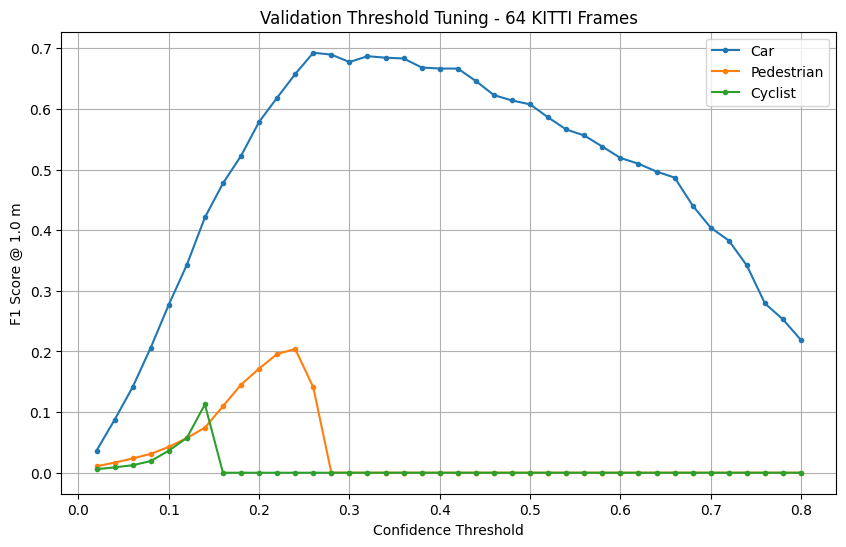

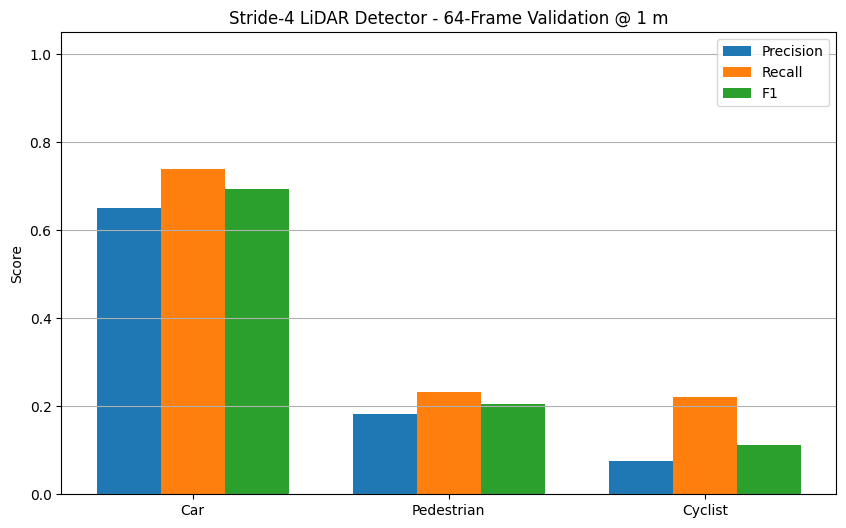


VALIDATION EVALUATION COMPLETE

IMPORTANT:
These are validation metrics.
The confidence thresholds were tuned on the same validation set.
Later we will create a separate held-out test split for final CV/GitHub metrics.


In [38]:
# ============================================================
# FULL 64-FRAME VALIDATION EVALUATION
#
# Stride-4 LiDAR Center Detector
#
# This cell:
# 1. Runs inference on ALL 64 frozen validation frames
# 2. Extracts class-specific local maxima
# 3. Sweeps confidence thresholds
# 4. Finds best threshold for each class at 1.0 m tolerance
# 5. Computes:
#       TP / FP / FN
#       Precision
#       Recall
#       F1
#       Localization error
# 6. Reports results at:
#       0.5 m
#       1.0 m
#       2.0 m
#
# NO TRAINING happens here.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time


# ============================================================
# 1. Configuration
# ============================================================

CLASS_NAMES = [
    "Car",
    "Pedestrian",
    "Cyclist"
]

NUM_CLASSES = 3


# Minimum score we store as a candidate peak.
# Threshold tuning happens later.
MIN_CANDIDATE_SCORE = 0.01


# Confidence thresholds to evaluate
THRESHOLDS = np.arange(
    0.02,
    0.82,
    0.02
)


# Main tolerance used to choose confidence threshold
TUNING_DISTANCE = 1.0


print("==========================================")
print("FULL VALIDATION EVALUATION")
print("==========================================")

print(
    "\nValidation frames:",
    len(validation_frame_ids)
)

print(
    "Device:",
    device
)


# ============================================================
# 2. Store predictions and GT for every frame
#
# Structure:
#
# validation_records[frame_id][class_id]
#
# contains:
#   GT centers
#   predicted peaks
# ============================================================

validation_records = {}


model.eval()


start_time = time.perf_counter()


# ============================================================
# 3. Run inference over ALL validation frames
# ============================================================

for frame_number, frame_id in enumerate(
    validation_frame_ids,
    start=1
):

    frame_id = str(
        frame_id
    )


    # --------------------------------------------------------
    # Build input + full-resolution GT
    # --------------------------------------------------------

    bev_sample, target_full, counts = (
        build_kitti_training_sample(
            frame_id
        )
    )


    # --------------------------------------------------------
    # Convert GT target -> stride-4
    # --------------------------------------------------------

    target_low = F.max_pool2d(

        target_full.unsqueeze(0),

        kernel_size=OUTPUT_STRIDE,

        stride=OUTPUT_STRIDE

    )[0]


    # --------------------------------------------------------
    # Send input to GPU
    # --------------------------------------------------------

    bev_gpu = (

        bev_sample

        .unsqueeze(0)

        .to(device)
    )


    # --------------------------------------------------------
    # FP32 inference
    # --------------------------------------------------------

    with torch.no_grad():

        logits = model(
            bev_gpu
        )[0]


    probabilities = torch.sigmoid(
        logits
    )


    # Safety check
    probabilities = torch.nan_to_num(

        probabilities,

        nan=0.0,

        posinf=1.0,

        neginf=0.0
    )


    # --------------------------------------------------------
    # Local maximum suppression
    # --------------------------------------------------------

    pooled = F.max_pool2d(

        probabilities.unsqueeze(0),

        kernel_size=5,

        stride=1,

        padding=2

    )[0]


    peak_map = torch.where(

        probabilities == pooled,

        probabilities,

        torch.zeros_like(
            probabilities
        )
    )


    frame_record = {}


    # ========================================================
    # Extract GT + predictions for each class
    # ========================================================

    for class_id in range(
        NUM_CLASSES
    ):


        # ----------------------------------------------------
        # Ground-truth centers
        # ----------------------------------------------------

        gt_positions = np.argwhere(

            target_low[
                class_id
            ].numpy()

            == 1.0
        )


        gt_centers = []


        for position in gt_positions:

            gx = int(
                position[0]
            )

            gy = int(
                position[1]
            )


            gt_centers.append(
                [
                    gx,
                    gy
                ]
            )


        gt_centers = np.array(

            gt_centers,

            dtype=np.float32
        )


        if len(gt_centers) == 0:

            gt_centers = np.empty(
                (0, 2),
                dtype=np.float32
            )


        # ----------------------------------------------------
        # Predicted local maxima
        # ----------------------------------------------------

        class_peak_map = (
            peak_map[
                class_id
            ]
        )


        candidate_indices = torch.nonzero(

            class_peak_map
            >=
            MIN_CANDIDATE_SCORE,

            as_tuple=False
        )


        predictions = []


        for index in candidate_indices:

            px = int(
                index[0].item()
            )

            py = int(
                index[1].item()
            )


            score = float(

                class_peak_map[
                    px,
                    py
                ].item()
            )


            predictions.append(
                [
                    px,
                    py,
                    score
                ]
            )


        # Highest confidence first
        predictions.sort(

            key=lambda x: x[2],

            reverse=True
        )


        predictions = np.array(

            predictions,

            dtype=np.float32
        )


        if len(predictions) == 0:

            predictions = np.empty(
                (0, 3),
                dtype=np.float32
            )


        frame_record[
            class_id
        ] = {

            "gt":
                gt_centers,

            "predictions":
                predictions
        }


    validation_records[
        frame_id
    ] = frame_record


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        frame_number == 1
        or
        frame_number % 10 == 0
        or
        frame_number
        ==
        len(validation_frame_ids)
    ):

        print(

            f"Processed "
            f"{frame_number:2d}/"
            f"{len(validation_frame_ids)} "
            f"frames"
        )


torch.cuda.synchronize()


inference_time = (
    time.perf_counter()
    -
    start_time
)


print(
    "\nInference/data processing time:",
    round(
        inference_time,
        1
    ),
    "seconds"
)


# ============================================================
# 4. Detection evaluation helper
#
# Standard score-ordered matching:
#
# Highest-confidence prediction first.
#
# Prediction is TP when nearest UNMATCHED same-class GT
# is within the selected distance tolerance.
#
# Otherwise it is FP.
#
# Any unmatched GT becomes FN.
# ============================================================

def evaluate_class(
    class_id,
    confidence_threshold,
    distance_tolerance
):

    total_gt = 0

    total_predictions = 0

    true_positives = 0

    false_positives = 0

    false_negatives = 0

    localization_errors = []

    matched_scores = []


    for frame_id, frame_record in (
        validation_records.items()
    ):

        gt = (
            frame_record[
                class_id
            ]["gt"]
        )


        predictions = (
            frame_record[
                class_id
            ]["predictions"]
        )


        # ----------------------------------------------------
        # Filter predictions by confidence
        # ----------------------------------------------------

        if len(predictions) > 0:

            predictions = predictions[

                predictions[:, 2]
                >=
                confidence_threshold

            ]


        total_gt += len(
            gt
        )

        total_predictions += len(
            predictions
        )


        # Track which GT objects have already been matched
        gt_used = np.zeros(
            len(gt),
            dtype=bool
        )


        # ----------------------------------------------------
        # Predictions already sorted by confidence
        # ----------------------------------------------------

        for prediction in predictions:

            px = prediction[0]

            py = prediction[1]

            score = prediction[2]


            # No GT objects in frame
            if len(gt) == 0:

                false_positives += 1

                continue


            # ------------------------------------------------
            # Distance to every GT
            # ------------------------------------------------

            dx = (
                gt[:, 0]
                -
                px
            )

            dy = (
                gt[:, 1]
                -
                py
            )


            distances = (

                np.sqrt(
                    dx**2
                    +
                    dy**2
                )

                *

                OUTPUT_RESOLUTION
            )


            # Already-matched GT cannot be reused
            distances[
                gt_used
            ] = np.inf


            nearest_gt = int(
                np.argmin(
                    distances
                )
            )


            nearest_distance = float(
                distances[
                    nearest_gt
                ]
            )


            # ------------------------------------------------
            # Valid detection
            # ------------------------------------------------

            if (
                nearest_distance
                <=
                distance_tolerance
            ):

                true_positives += 1

                gt_used[
                    nearest_gt
                ] = True


                localization_errors.append(
                    nearest_distance
                )


                matched_scores.append(
                    score
                )


            else:

                false_positives += 1


        # ----------------------------------------------------
        # GT objects never matched = false negatives
        # ----------------------------------------------------

        unmatched_gt = int(
            np.sum(
                ~gt_used
            )
        )


        false_negatives += (
            unmatched_gt
        )


    # ========================================================
    # Metrics
    # ========================================================

    precision = (

        true_positives
        /
        (
            true_positives
            +
            false_positives
        )

        if
        (
            true_positives
            +
            false_positives
        )
        > 0

        else
        0.0
    )


    recall = (

        true_positives
        /
        (
            true_positives
            +
            false_negatives
        )

        if
        (
            true_positives
            +
            false_negatives
        )
        > 0

        else
        0.0
    )


    f1 = (

        2
        *
        precision
        *
        recall
        /
        (
            precision
            +
            recall
        )

        if
        (
            precision
            +
            recall
        )
        > 0

        else
        0.0
    )


    mean_error = (

        float(
            np.mean(
                localization_errors
            )
        )

        if localization_errors

        else
        np.nan
    )


    median_error = (

        float(
            np.median(
                localization_errors
            )
        )

        if localization_errors

        else
        np.nan
    )


    return {

        "gt":
            total_gt,

        "predictions":
            total_predictions,

        "tp":
            true_positives,

        "fp":
            false_positives,

        "fn":
            false_negatives,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "mean_error":
            mean_error,

        "median_error":
            median_error,

        "matched_scores":
            matched_scores
    }


# ============================================================
# 5. Find BEST confidence threshold per class
#
# Optimization criterion:
#
# F1 score at 1.0 meter localization tolerance.
#
# IMPORTANT:
# This is validation tuning, NOT final test evaluation.
# ============================================================

best_thresholds = {}

threshold_curves = {}


print("\n==========================================")
print("CONFIDENCE THRESHOLD SEARCH")
print("==========================================")


for class_id, class_name in enumerate(
    CLASS_NAMES
):

    best_threshold = None

    best_f1 = -1.0

    curve = []


    for threshold in THRESHOLDS:

        metrics = evaluate_class(

            class_id,

            confidence_threshold=
                threshold,

            distance_tolerance=
                TUNING_DISTANCE
        )


        curve.append(
            (
                threshold,
                metrics["f1"]
            )
        )


        if (
            metrics["f1"]
            >
            best_f1
        ):

            best_f1 = (
                metrics["f1"]
            )

            best_threshold = (
                threshold
            )


    best_thresholds[
        class_id
    ] = best_threshold


    threshold_curves[
        class_id
    ] = curve


    print(

        f"{class_name:10s} | "

        f"best threshold = "
        f"{best_threshold:.2f} | "

        f"best F1@1m = "
        f"{best_f1:.3f}"
    )


# ============================================================
# 6. Final validation report
#
# Use the class-specific validation-tuned threshold.
# ============================================================

DISTANCE_TOLERANCES = [
    0.5,
    1.0,
    2.0
]


all_results = {}


print("\n==========================================")
print("64-FRAME VALIDATION RESULTS")
print("==========================================")


for distance_tolerance in (
    DISTANCE_TOLERANCES
):

    print(
        f"\n============== "
        f"{distance_tolerance:.1f} m "
        f"=============="
    )


    all_results[
        distance_tolerance
    ] = {}


    total_tp = 0
    total_fp = 0
    total_fn = 0


    for class_id, class_name in enumerate(
        CLASS_NAMES
    ):

        threshold = (
            best_thresholds[
                class_id
            ]
        )


        metrics = evaluate_class(

            class_id,

            confidence_threshold=
                threshold,

            distance_tolerance=
                distance_tolerance
        )


        all_results[
            distance_tolerance
        ][
            class_id
        ] = metrics


        total_tp += (
            metrics["tp"]
        )

        total_fp += (
            metrics["fp"]
        )

        total_fn += (
            metrics["fn"]
        )


        print(
            f"\n{class_name}"
        )

        print(
            f"  Threshold : "
            f"{threshold:.2f}"
        )

        print(
            f"  GT        : "
            f"{metrics['gt']}"
        )

        print(
            f"  Predictions: "
            f"{metrics['predictions']}"
        )

        print(
            f"  TP / FP / FN: "
            f"{metrics['tp']} / "
            f"{metrics['fp']} / "
            f"{metrics['fn']}"
        )

        print(
            f"  Precision : "
            f"{metrics['precision']:.3f}"
        )

        print(
            f"  Recall    : "
            f"{metrics['recall']:.3f}"
        )

        print(
            f"  F1        : "
            f"{metrics['f1']:.3f}"
        )

        print(
            f"  Mean error: "
            f"{metrics['mean_error']:.3f} m"
        )


    # ========================================================
    # Aggregate micro metrics
    # ========================================================

    overall_precision = (

        total_tp
        /
        (
            total_tp
            +
            total_fp
        )

        if
        (
            total_tp
            +
            total_fp
        )
        > 0

        else
        0.0
    )


    overall_recall = (

        total_tp
        /
        (
            total_tp
            +
            total_fn
        )

        if
        (
            total_tp
            +
            total_fn
        )
        > 0

        else
        0.0
    )


    overall_f1 = (

        2
        *
        overall_precision
        *
        overall_recall
        /
        (
            overall_precision
            +
            overall_recall
        )

        if
        (
            overall_precision
            +
            overall_recall
        )
        > 0

        else
        0.0
    )


    print(
        "\nOVERALL"
    )

    print(
        f"  TP / FP / FN: "
        f"{total_tp} / "
        f"{total_fp} / "
        f"{total_fn}"
    )

    print(
        f"  Precision : "
        f"{overall_precision:.3f}"
    )

    print(
        f"  Recall    : "
        f"{overall_recall:.3f}"
    )

    print(
        f"  F1        : "
        f"{overall_f1:.3f}"
    )


# ============================================================
# 7. Plot F1 vs confidence threshold
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for class_id, class_name in enumerate(
    CLASS_NAMES
):

    curve = (
        threshold_curves[
            class_id
        ]
    )


    thresholds_plot = [
        item[0]
        for item in curve
    ]


    f1_plot = [
        item[1]
        for item in curve
    ]


    plt.plot(

        thresholds_plot,

        f1_plot,

        marker=".",

        label=class_name
    )


plt.xlabel(
    "Confidence Threshold"
)

plt.ylabel(
    "F1 Score @ 1.0 m"
)

plt.title(
    "Validation Threshold Tuning - 64 KITTI Frames"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 8. Plot per-class precision / recall / F1 at 1 meter
# ============================================================

metrics_1m = (
    all_results[
        1.0
    ]
)


precision_values = []

recall_values = []

f1_values = []


for class_id in range(
    NUM_CLASSES
):

    precision_values.append(
        metrics_1m[
            class_id
        ]["precision"]
    )

    recall_values.append(
        metrics_1m[
            class_id
        ]["recall"]
    )

    f1_values.append(
        metrics_1m[
            class_id
        ]["f1"]
    )


x = np.arange(
    len(
        CLASS_NAMES
    )
)


width = 0.25


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    x - width,
    precision_values,
    width,
    label="Precision"
)

plt.bar(
    x,
    recall_values,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    f1_values,
    width,
    label="F1"
)


plt.xticks(
    x,
    CLASS_NAMES
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score"
)

plt.title(
    "Stride-4 LiDAR Detector - 64-Frame Validation @ 1 m"
)

plt.grid(
    axis="y"
)

plt.legend()

plt.show()


print("\n==========================================")
print("VALIDATION EVALUATION COMPLETE")
print("==========================================")

print(
    "\nIMPORTANT:"
)

print(
    "These are validation metrics."
)

print(
    "The confidence thresholds were tuned on "
    "the same validation set."
)

print(
    "Later we will create a separate "
    "held-out evaluation split for final evaluation metrics."
)

TRAINING SET CLASS DISTRIBUTION

Training frames: 256

Car
  Total objects: 825
  Percentage: 79.71 %
  Frames containing class: 222 / 256
  Average objects/frame: 3.22

Pedestrian
  Total objects: 154
  Percentage: 14.88 %
  Frames containing class: 57 / 256
  Average objects/frame: 0.6

Cyclist
  Total objects: 56
  Percentage: 5.41 %
  Frames containing class: 37 / 256
  Average objects/frame: 0.22


VALIDATION SET CLASS DISTRIBUTION

Validation frames: 64

Car
  Total objects: 227
  Percentage: 78.82 %
  Frames containing class: 52 / 64

Pedestrian
  Total objects: 43
  Percentage: 14.93 %
  Frames containing class: 17 / 64

Cyclist
  Total objects: 18
  Percentage: 6.25 %
  Frames containing class: 12 / 64


CLASS IMBALANCE

Car : Car        = 1.00 : 1
Car : Pedestrian = 5.36 : 1
Car : Cyclist    = 14.73 : 1


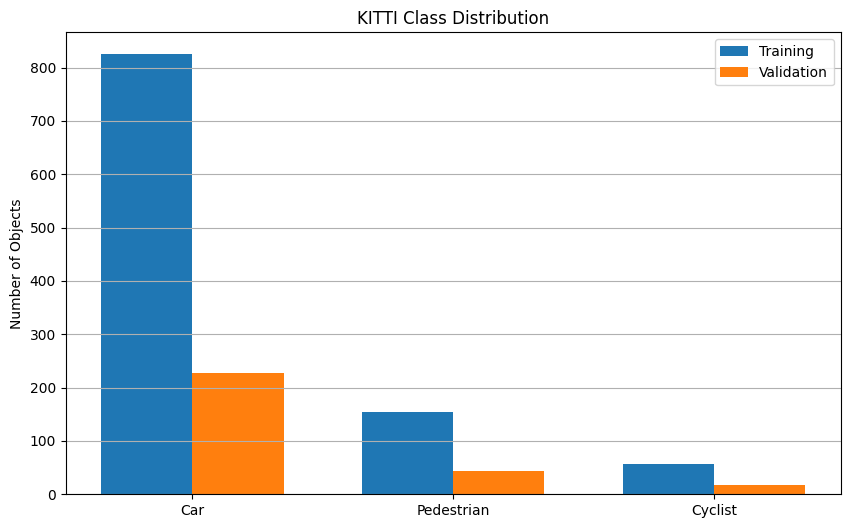

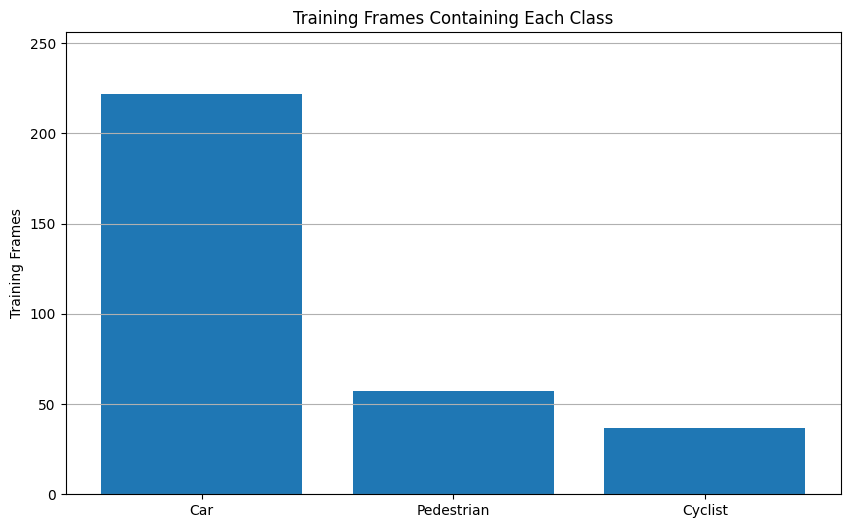

In [39]:
# ============================================================
# ANALYZE CLASS DISTRIBUTION
#
# Count Car / Pedestrian / Cyclist objects
# across our current train and validation splits.
#
# NO TRAINING happens here.
# ============================================================

from collections import Counter
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Helper to count objects in a set of frames
# ============================================================

def analyze_class_distribution(frame_ids):

    object_counts = Counter()

    frames_with_class = Counter()

    objects_per_frame = {
        "Car": [],
        "Pedestrian": [],
        "Cyclist": []
    }


    for frame_id in frame_ids:

        frame_id = str(frame_id)

        _, _, counts = (
            build_kitti_training_sample(
                frame_id
            )
        )


        for class_name in CLASS_NAMES:

            count = counts[
                class_name
            ]

            object_counts[
                class_name
            ] += count


            objects_per_frame[
                class_name
            ].append(
                count
            )


            if count > 0:

                frames_with_class[
                    class_name
                ] += 1


    return (
        object_counts,
        frames_with_class,
        objects_per_frame
    )


# ============================================================
# 2. Training distribution
# ============================================================

train_object_counts, train_frames_with_class, train_objects_per_frame = (
    analyze_class_distribution(
        train_frame_ids
    )
)


# ============================================================
# 3. Validation distribution
# ============================================================

val_object_counts, val_frames_with_class, val_objects_per_frame = (
    analyze_class_distribution(
        validation_frame_ids
    )
)


# ============================================================
# 4. Print TRAINING statistics
# ============================================================

print("==========================================")
print("TRAINING SET CLASS DISTRIBUTION")
print("==========================================")

print(
    "\nTraining frames:",
    len(train_frame_ids)
)


total_train_objects = sum(
    train_object_counts.values()
)


for class_name in CLASS_NAMES:

    count = train_object_counts[
        class_name
    ]


    percentage = (

        count
        /
        total_train_objects
        *
        100

        if total_train_objects > 0

        else 0
    )


    print(
        f"\n{class_name}"
    )

    print(
        "  Total objects:",
        count
    )

    print(
        "  Percentage:",
        round(
            percentage,
            2
        ),
        "%"
    )

    print(
        "  Frames containing class:",
        train_frames_with_class[
            class_name
        ],
        "/",
        len(train_frame_ids)
    )

    print(
        "  Average objects/frame:",
        round(
            np.mean(
                train_objects_per_frame[
                    class_name
                ]
            ),
            2
        )
    )


# ============================================================
# 5. Print VALIDATION statistics
# ============================================================

print("\n\n==========================================")
print("VALIDATION SET CLASS DISTRIBUTION")
print("==========================================")

print(
    "\nValidation frames:",
    len(validation_frame_ids)
)


total_val_objects = sum(
    val_object_counts.values()
)


for class_name in CLASS_NAMES:

    count = val_object_counts[
        class_name
    ]


    percentage = (

        count
        /
        total_val_objects
        *
        100

        if total_val_objects > 0

        else 0
    )


    print(
        f"\n{class_name}"
    )

    print(
        "  Total objects:",
        count
    )

    print(
        "  Percentage:",
        round(
            percentage,
            2
        ),
        "%"
    )

    print(
        "  Frames containing class:",
        val_frames_with_class[
            class_name
        ],
        "/",
        len(validation_frame_ids)
    )


# ============================================================
# 6. Calculate imbalance relative to Cars
# ============================================================

print("\n\n==========================================")
print("CLASS IMBALANCE")
print("==========================================\n")


car_count = train_object_counts[
    "Car"
]


for class_name in CLASS_NAMES:

    count = train_object_counts[
        class_name
    ]


    if count > 0:

        ratio = (
            car_count
            /
            count
        )

    else:

        ratio = float(
            "inf"
        )


    print(
        f"Car : {class_name:10s} "
        f"= {ratio:.2f} : 1"
    )


# ============================================================
# 7. Plot object distribution
# ============================================================

train_values = [
    train_object_counts[
        class_name
    ]
    for class_name in CLASS_NAMES
]


val_values = [
    val_object_counts[
        class_name
    ]
    for class_name in CLASS_NAMES
]


x = np.arange(
    len(CLASS_NAMES)
)

width = 0.35


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    x - width / 2,
    train_values,
    width,
    label="Training"
)


plt.bar(
    x + width / 2,
    val_values,
    width,
    label="Validation"
)


plt.xticks(
    x,
    CLASS_NAMES
)

plt.ylabel(
    "Number of Objects"
)

plt.title(
    "KITTI Class Distribution"
)

plt.grid(
    axis="y"
)

plt.legend()

plt.show()


# ============================================================
# 8. Frames containing each class
# ============================================================

frame_presence = [

    train_frames_with_class[
        class_name
    ]

    for class_name in CLASS_NAMES
]


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    CLASS_NAMES,
    frame_presence
)


plt.ylabel(
    "Training Frames"
)

plt.title(
    "Training Frames Containing Each Class"
)

plt.ylim(
    0,
    len(train_frame_ids)
)

plt.grid(
    axis="y"
)

plt.show()

In [40]:
# ============================================================
# CLASS-BALANCED FRAME SAMPLING
#
# Goal:
# Increase exposure to Pedestrian / Cyclist scenes
# WITHOUT changing the validation set.
#
# NO TRAINING happens in this cell.
# ============================================================

import torch
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

import numpy as np


# ============================================================
# 1. Restore stride-4 Dataset class
# ============================================================

class KITTIStride4Dataset(Dataset):

    def __init__(self, frame_ids):

        self.frame_ids = [
            str(frame_id)
            for frame_id in frame_ids
        ]


    def __len__(self):

        return len(
            self.frame_ids
        )


    def __getitem__(self, index):

        frame_id = (
            self.frame_ids[index]
        )


        bev_sample, full_target, counts = (
            build_kitti_training_sample(
                frame_id
            )
        )


        # Full:
        # [3, 500, 400]
        #
        # Stride-4:
        # [3, 125, 100]

        low_target = F.max_pool2d(

            full_target.unsqueeze(0),

            kernel_size=OUTPUT_STRIDE,

            stride=OUTPUT_STRIDE

        )[0]


        return (
            bev_sample,
            low_target,
            frame_id
        )


# ============================================================
# 2. Create training dataset
# ============================================================

balanced_train_dataset = (
    KITTIStride4Dataset(
        train_frame_ids
    )
)


# ============================================================
# 3. Count how many TRAINING FRAMES contain each class
# ============================================================

frame_presence_counts = {

    "Car": 0,

    "Pedestrian": 0,

    "Cyclist": 0
}


# Cache counts so we don't repeatedly read labels later
training_frame_counts = {}


for frame_id in train_frame_ids:

    frame_id = str(
        frame_id
    )


    _, _, counts = (
        build_kitti_training_sample(
            frame_id
        )
    )


    training_frame_counts[
        frame_id
    ] = counts


    for class_name in CLASS_NAMES:

        if counts[
            class_name
        ] > 0:

            frame_presence_counts[
                class_name
            ] += 1


print("==========================================")
print("CLASS-AWARE SAMPLING")
print("==========================================")


print(
    "\nFrames containing Car:",
    frame_presence_counts["Car"]
)

print(
    "Frames containing Pedestrian:",
    frame_presence_counts["Pedestrian"]
)

print(
    "Frames containing Cyclist:",
    frame_presence_counts["Cyclist"]
)


# ============================================================
# 4. Calculate moderate rarity weights
#
# We use sqrt(inverse frequency), NOT full inverse frequency.
#
# This prevents Cyclist scenes from becoming absurdly
# over-represented.
# ============================================================

num_training_frames = len(
    train_frame_ids
)


class_sampling_weights = {}


for class_name in CLASS_NAMES:

    class_sampling_weights[
        class_name
    ] = np.sqrt(

        num_training_frames

        /

        frame_presence_counts[
            class_name
        ]
    )


print("\nClass sampling multipliers:")


for class_name in CLASS_NAMES:

    print(

        f"{class_name:10s}: "

        f"{class_sampling_weights[class_name]:.3f}"
    )


# ============================================================
# 5. Assign ONE weight to every frame
#
# Frame weight = rarity of the rarest class in that frame.
#
# Examples:
#
# only Car          → ~1.07
# Pedestrian frame  → ~2.12
# Cyclist frame     → ~2.63
#
# A frame containing Car + Cyclist receives Cyclist weight.
# ============================================================

sample_weights = []


for frame_id in train_frame_ids:

    frame_id = str(
        frame_id
    )


    counts = training_frame_counts[
        frame_id
    ]


    present_class_weights = []


    for class_name in CLASS_NAMES:

        if counts[
            class_name
        ] > 0:

            present_class_weights.append(

                class_sampling_weights[
                    class_name
                ]
            )


    if len(
        present_class_weights
    ) > 0:

        frame_weight = max(
            present_class_weights
        )

    else:

        frame_weight = 1.0


    sample_weights.append(
        frame_weight
    )


sample_weights = torch.tensor(

    sample_weights,

    dtype=torch.double
)


print(
    "\nMinimum frame weight:",
    round(
        sample_weights.min().item(),
        3
    )
)


print(
    "Maximum frame weight:",
    round(
        sample_weights.max().item(),
        3
    )
)


# ============================================================
# 6. Create WeightedRandomSampler
#
# replacement=True means minority-class frames can appear
# more than once during an epoch.
#
# Still 256 samples per epoch.
# ============================================================

balanced_sampler = WeightedRandomSampler(

    weights=sample_weights,

    num_samples=len(
        balanced_train_dataset
    ),

    replacement=True,

    generator=torch.Generator().manual_seed(
        42
    )
)


# ============================================================
# 7. Balanced DataLoader
# ============================================================

BALANCED_BATCH_SIZE = 6


balanced_train_loader = DataLoader(

    balanced_train_dataset,

    batch_size=BALANCED_BATCH_SIZE,

    sampler=balanced_sampler,

    num_workers=0,

    pin_memory=True,

    drop_last=True
)


print(
    "\nBalanced training batches:",
    len(
        balanced_train_loader
    )
)


# ============================================================
# 8. Simulate one balanced epoch
#
# We inspect what the sampler will expose the model to.
# ============================================================

generator = torch.Generator().manual_seed(
    42
)


sampled_indices = torch.multinomial(

    sample_weights,

    num_samples=len(
        balanced_train_dataset
    ),

    replacement=True,

    generator=generator
)


balanced_epoch_objects = {

    "Car": 0,

    "Pedestrian": 0,

    "Cyclist": 0
}


balanced_frames_with_class = {

    "Car": 0,

    "Pedestrian": 0,

    "Cyclist": 0
}


sampled_frame_ids = []


for index in sampled_indices.tolist():

    frame_id = str(
        train_frame_ids[
            index
        ]
    )


    sampled_frame_ids.append(
        frame_id
    )


    counts = training_frame_counts[
        frame_id
    ]


    for class_name in CLASS_NAMES:

        balanced_epoch_objects[
            class_name
        ] += counts[
            class_name
        ]


        if counts[
            class_name
        ] > 0:

            balanced_frames_with_class[
                class_name
            ] += 1


# ============================================================
# 9. Compare ORIGINAL vs BALANCED exposure
# ============================================================

print("\n==========================================")
print("ORIGINAL EPOCH")
print("==========================================")


for class_name in CLASS_NAMES:

    print(

        f"{class_name:10s} | "

        f"objects = "
        f"{train_object_counts[class_name]:4d} | "

        f"class frames = "
        f"{train_frames_with_class[class_name]:3d}"
    )


print("\n==========================================")
print("SIMULATED BALANCED EPOCH")
print("==========================================")


total_balanced_objects = sum(

    balanced_epoch_objects.values()
)


for class_name in CLASS_NAMES:

    percentage = (

        balanced_epoch_objects[
            class_name
        ]

        /

        total_balanced_objects

        *

        100
    )


    print(

        f"{class_name:10s} | "

        f"objects = "
        f"{balanced_epoch_objects[class_name]:4d} | "

        f"class frames = "
        f"{balanced_frames_with_class[class_name]:3d} | "

        f"{percentage:5.2f}%"
    )


# ============================================================
# 10. Check duplicate rate
#
# Some duplicates are expected because we are oversampling.
# ============================================================

unique_frames = len(
    set(
        sampled_frame_ids
    )
)


duplicate_count = (

    len(
        sampled_frame_ids
    )

    -

    unique_frames
)


print("\n==========================================")
print("SAMPLING SUMMARY")
print("==========================================")


print(
    "\nSamples per epoch:",
    len(
        sampled_frame_ids
    )
)


print(
    "Unique frames sampled:",
    unique_frames
)


print(
    "Repeated samples:",
    duplicate_count
)


print(
    "\n✅ Balanced sampler created successfully."
)

CLASS-AWARE SAMPLING

Frames containing Car: 222
Frames containing Pedestrian: 57
Frames containing Cyclist: 37

Class sampling multipliers:
Car       : 1.074
Pedestrian: 2.119
Cyclist   : 2.630

Minimum frame weight: 1.0
Maximum frame weight: 2.63

Balanced training batches: 42

ORIGINAL EPOCH
Car        | objects =  825 | class frames = 222
Pedestrian | objects =  154 | class frames =  57
Cyclist    | objects =   56 | class frames =  37

SIMULATED BALANCED EPOCH
Car        | objects =  737 | class frames = 196 | 68.94%
Pedestrian | objects =  238 | class frames = 106 | 22.26%
Cyclist    | objects =   94 | class frames =  62 |  8.79%

SAMPLING SUMMARY

Samples per epoch: 256
Unique frames sampled: 157
Repeated samples: 99

✅ Balanced sampler created successfully.


BALANCED TRAINING EXPERIMENT

Training batches: 42
Validation batches: 11

Balanced checkpoint:
D:\LiDAR Project\Lidar_Project\checkpoints\stride4_bev_detector_balanced_best.pt

Model parameters: 850,851

STARTING BALANCED TRAINING

Epochs: 10
Batch size: 6
Device: cuda
Epoch 01/10 | Batch 01/42 | Loss 1352.6945
Epoch 01/10 | Batch 10/42 | Loss 946.1597
Epoch 01/10 | Batch 20/42 | Loss 3.5543
Epoch 01/10 | Batch 30/42 | Loss 3.2487
Epoch 01/10 | Batch 40/42 | Loss 3.2669
Epoch 01/10 | Batch 42/42 | Loss 3.0542

------------------------------------------
BALANCED EPOCH 1 COMPLETE
------------------------------------------
Train loss     : 431.5125
Validation loss: 3.1877
Learning rate  : 0.001
Epoch time     : 74.4 seconds
Peak allocated : 2.171 GB
Peak reserved  : 3.014 GB
✅ New best BALANCED checkpoint saved

Epoch 02/10 | Batch 01/42 | Loss 3.1964
Epoch 02/10 | Batch 10/42 | Loss 3.2615
Epoch 02/10 | Batch 20/42 | Loss 2.5932
Epoch 02/10 | Batch 30/42 | Loss 2.2626
Epoch 02/10 | Batc

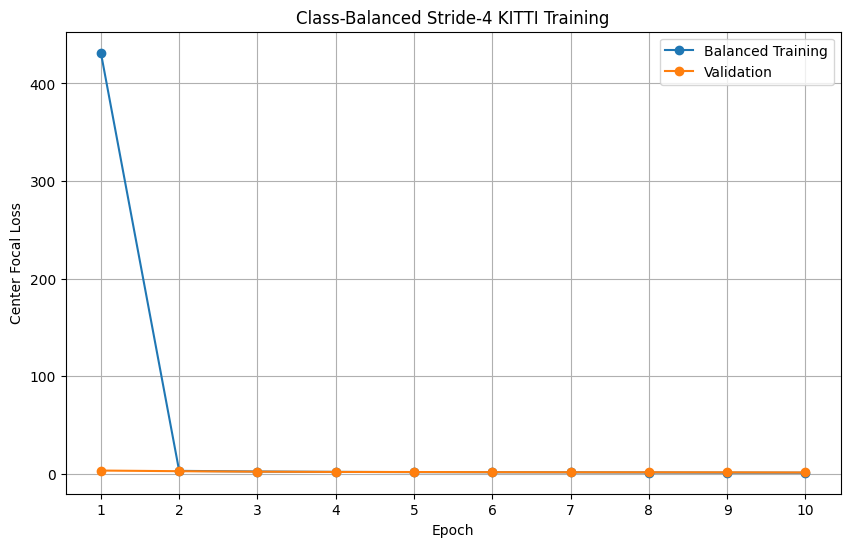


Balanced epoch results:

Epoch   Train         Validation    LR          Time(s)   
----------------------------------------------------------
1       431.5125      3.1877        0.001000    74.4      
2       2.8782        2.5336        0.001000    69.8      
3       2.2192        2.0574        0.001000    69.8      
4       1.8421        1.7694        0.001000    69.8      
5       1.5879        1.6880        0.001000    70.0      
6       1.4158        1.5425        0.001000    69.8      
7       1.3357        1.4370        0.001000    69.8      
8       1.1905        1.4139        0.001000    69.9      
9       1.0317        1.3550        0.001000    69.8      
10      0.9687        1.2255        0.001000    69.8      


In [41]:
# ============================================================
# BALANCED STRIDE-4 TRAINING EXPERIMENT
#
# Purpose:
# Compare class-balanced frame sampling against our baseline.
#
# SAME:
#   Architecture
#   256 training frames
#   64 validation frames
#   Batch size = 6
#   10 epochs
#
# DIFFERENCE:
#   Training uses WeightedRandomSampler
#
# New checkpoint:
# checkpoints/stride4_bev_detector_balanced_best.pt
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import gc
import time


# ============================================================
# 1. Center focal loss
# ============================================================

def center_focal_loss(
    logits,
    targets,
    alpha=2.0,
    beta=4.0
):

    probabilities = torch.sigmoid(
        logits
    )

    probabilities = torch.clamp(
        probabilities,
        min=1e-6,
        max=1.0 - 1e-6
    )


    positive_mask = (
        targets == 1.0
    ).float()


    negative_mask = (
        targets < 1.0
    ).float()


    negative_weights = (
        1.0 - targets
    ) ** beta


    positive_loss = (

        torch.log(
            probabilities
        )

        *

        (
            1.0 - probabilities
        ) ** alpha

        *

        positive_mask
    )


    negative_loss = (

        torch.log(
            1.0 - probabilities
        )

        *

        probabilities ** alpha

        *

        negative_weights

        *

        negative_mask
    )


    num_positive = (
        positive_mask.sum()
        .clamp(min=1.0)
    )


    loss = -(

        positive_loss.sum()

        +

        negative_loss.sum()

    ) / num_positive


    return loss


# ============================================================
# 2. Validation dataset / DataLoader
#
# Training DataLoader already exists:
# balanced_train_loader
# ============================================================

balanced_validation_dataset = (
    KITTIStride4Dataset(
        validation_frame_ids
    )
)


balanced_validation_loader = DataLoader(

    balanced_validation_dataset,

    batch_size=6,

    shuffle=False,

    num_workers=0,

    pin_memory=True,

    drop_last=False
)


print("==========================================")
print("BALANCED TRAINING EXPERIMENT")
print("==========================================")

print(
    "\nTraining batches:",
    len(
        balanced_train_loader
    )
)

print(
    "Validation batches:",
    len(
        balanced_validation_loader
    )
)


# ============================================================
# 3. Training configuration
# ============================================================

BALANCED_EPOCHS = 10

BALANCED_LR = 1e-3

BALANCED_WEIGHT_DECAY = 1e-4


# ============================================================
# 4. Save location
# ============================================================

checkpoint_dir = Path(
    "checkpoints"
)

checkpoint_dir.mkdir(
    exist_ok=True
)


balanced_checkpoint_path = (

    checkpoint_dir

    /

    "stride4_bev_detector_balanced_best.pt"
)


print(
    "\nBalanced checkpoint:"
)

print(
    balanced_checkpoint_path.resolve()
)


# ============================================================
# 5. Remove unnecessary GPU tensors from previous work
# ============================================================

gc.collect()

torch.cuda.empty_cache()


# ============================================================
# 6. Create a FRESH model
#
# IMPORTANT:
# We are NOT continuing from the baseline checkpoint.
#
# This gives us a fair baseline-vs-balanced experiment.
# ============================================================

balanced_model = (

    Stride4CenterDetector(
        num_classes=3
    )

    .to(device)
)


balanced_parameter_count = sum(

    p.numel()

    for p in balanced_model.parameters()
)


print(
    "\nModel parameters:",
    f"{balanced_parameter_count:,}"
)


# ============================================================
# 7. Optimizer
# ============================================================

balanced_optimizer = torch.optim.AdamW(

    balanced_model.parameters(),

    lr=BALANCED_LR,

    weight_decay=BALANCED_WEIGHT_DECAY
)


# ============================================================
# 8. Learning-rate scheduler
# ============================================================

balanced_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        balanced_optimizer,

        mode="min",

        factor=0.5,

        patience=2,

        min_lr=1e-5
    )
)


# ============================================================
# 9. Mixed precision
# ============================================================

balanced_scaler = torch.amp.GradScaler(
    "cuda"
)


# ============================================================
# 10. History
# ============================================================

balanced_train_history = []

balanced_val_history = []

balanced_time_history = []

balanced_lr_history = []


best_balanced_val_loss = float(
    "inf"
)


best_balanced_epoch = 0


# ============================================================
# 11. Clean GPU / reset statistics
# ============================================================

gc.collect()

torch.cuda.empty_cache()


# ============================================================
# 12. Training loop
# ============================================================

print("\n==========================================")
print("STARTING BALANCED TRAINING")
print("==========================================")

print(
    "\nEpochs:",
    BALANCED_EPOCHS
)

print(
    "Batch size:",
    6
)

print(
    "Device:",
    device
)


for epoch in range(
    1,
    BALANCED_EPOCHS + 1
):

    epoch_start = time.perf_counter()

    torch.cuda.reset_peak_memory_stats()


    # ========================================================
    # TRAINING
    # ========================================================

    balanced_model.train()


    train_loss_sum = 0.0

    train_batch_count = 0


    for batch_index, (
        bev_batch,
        target_batch,
        frame_ids
    ) in enumerate(
        balanced_train_loader,
        start=1
    ):


        # ----------------------------------------------------
        # Send batch to GPU
        # ----------------------------------------------------

        bev_batch = bev_batch.to(

            device,

            non_blocking=True
        )


        target_batch = target_batch.to(

            device,

            non_blocking=True
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        balanced_optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Forward pass in mixed precision
        # ----------------------------------------------------

        with torch.amp.autocast(

            device_type="cuda",

            dtype=torch.float16
        ):

            predictions = balanced_model(
                bev_batch
            )


        # ----------------------------------------------------
        # Loss in FP32
        # ----------------------------------------------------

        loss = center_focal_loss(

            predictions.float(),

            target_batch.float()
        )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        balanced_scaler.scale(
            loss
        ).backward()


        # ----------------------------------------------------
        # Gradient clipping
        # ----------------------------------------------------

        balanced_scaler.unscale_(
            balanced_optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            balanced_model.parameters(),

            max_norm=10.0
        )


        # ----------------------------------------------------
        # Optimizer step
        # ----------------------------------------------------

        balanced_scaler.step(
            balanced_optimizer
        )


        balanced_scaler.update()


        # ----------------------------------------------------
        # Record loss
        # ----------------------------------------------------

        train_loss_sum += (
            loss.item()
        )

        train_batch_count += 1


        if (
            batch_index == 1
            or
            batch_index % 10 == 0
            or
            batch_index
            ==
            len(
                balanced_train_loader
            )
        ):

            print(

                f"Epoch "
                f"{epoch:02d}/"
                f"{BALANCED_EPOCHS:02d} "

                f"| Batch "
                f"{batch_index:02d}/"
                f"{len(balanced_train_loader):02d} "

                f"| Loss "
                f"{loss.item():.4f}"
            )


    average_train_loss = (

        train_loss_sum

        /

        train_batch_count
    )


    balanced_train_history.append(
        average_train_loss
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    balanced_model.eval()


    val_loss_sum = 0.0

    val_batch_count = 0


    with torch.no_grad():


        for (
            bev_batch,
            target_batch,
            frame_ids
        ) in balanced_validation_loader:


            bev_batch = bev_batch.to(

                device,

                non_blocking=True
            )


            target_batch = target_batch.to(

                device,

                non_blocking=True
            )


            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            with torch.amp.autocast(

                device_type="cuda",

                dtype=torch.float16
            ):

                predictions = balanced_model(
                    bev_batch
                )


            # ------------------------------------------------
            # Validation loss
            # ------------------------------------------------

            val_loss = center_focal_loss(

                predictions.float(),

                target_batch.float()
            )


            val_loss_sum += (
                val_loss.item()
            )


            val_batch_count += 1


    average_val_loss = (

        val_loss_sum

        /

        val_batch_count
    )


    balanced_val_history.append(
        average_val_loss
    )


    # ========================================================
    # Scheduler
    # ========================================================

    balanced_scheduler.step(
        average_val_loss
    )


    current_lr = (
        balanced_optimizer
        .param_groups[0]["lr"]
    )


    balanced_lr_history.append(
        current_lr
    )


    # ========================================================
    # Save best checkpoint
    # ========================================================

    new_best = False


    if (
        average_val_loss
        <
        best_balanced_val_loss
    ):

        best_balanced_val_loss = (
            average_val_loss
        )


        best_balanced_epoch = epoch


        torch.save(

            {

                "epoch":
                    epoch,

                "model_state_dict":
                    balanced_model.state_dict(),

                "optimizer_state_dict":
                    balanced_optimizer.state_dict(),

                "train_loss":
                    average_train_loss,

                "validation_loss":
                    average_val_loss,

                "learning_rate":
                    current_lr,

                "sampling":
                    "sqrt_inverse_frequency_frame_sampling",

                "output_stride":
                    OUTPUT_STRIDE,

                "output_resolution":
                    OUTPUT_RESOLUTION

            },

            balanced_checkpoint_path
        )


        new_best = True


    # ========================================================
    # Timing
    # ========================================================

    torch.cuda.synchronize()


    epoch_time = (

        time.perf_counter()

        -

        epoch_start
    )


    balanced_time_history.append(
        epoch_time
    )


    # ========================================================
    # GPU memory
    # ========================================================

    peak_allocated = (

        torch.cuda.max_memory_allocated()

        /

        1024**3
    )


    peak_reserved = (

        torch.cuda.max_memory_reserved()

        /

        1024**3
    )


    # ========================================================
    # Epoch summary
    # ========================================================

    print("\n------------------------------------------")

    print(
        f"BALANCED EPOCH {epoch} COMPLETE"
    )

    print("------------------------------------------")


    print(
        "Train loss     :",
        round(
            average_train_loss,
            4
        )
    )


    print(
        "Validation loss:",
        round(
            average_val_loss,
            4
        )
    )


    print(
        "Learning rate  :",
        current_lr
    )


    print(
        "Epoch time     :",
        round(
            epoch_time,
            1
        ),
        "seconds"
    )


    print(
        "Peak allocated :",
        round(
            peak_allocated,
            3
        ),
        "GB"
    )


    print(
        "Peak reserved  :",
        round(
            peak_reserved,
            3
        ),
        "GB"
    )


    if new_best:

        print(
            "✅ New best BALANCED checkpoint saved"
        )


    print()


# ============================================================
# 13. Training complete
# ============================================================

print("\n==========================================")
print("BALANCED TRAINING COMPLETE")
print("==========================================")


print(
    "\nBest epoch:",
    best_balanced_epoch
)


print(
    "Best validation loss:",
    round(
        best_balanced_val_loss,
        5
    )
)


print(
    "\nSaved model:"
)

print(
    balanced_checkpoint_path.resolve()
)


# ============================================================
# 14. Plot balanced training history
# ============================================================

balanced_epochs = np.arange(
    1,
    BALANCED_EPOCHS + 1
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    balanced_epochs,

    balanced_train_history,

    marker="o",

    label="Balanced Training"
)


plt.plot(

    balanced_epochs,

    balanced_val_history,

    marker="o",

    label="Validation"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Center Focal Loss"
)

plt.title(
    "Class-Balanced Stride-4 KITTI Training"
)

plt.xticks(
    balanced_epochs
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 15. Results table
# ============================================================

print("\nBalanced epoch results:\n")


print(

    f"{'Epoch':<8}"

    f"{'Train':<14}"

    f"{'Validation':<14}"

    f"{'LR':<12}"

    f"{'Time(s)':<10}"
)


print(
    "-" * 58
)


for i in range(
    BALANCED_EPOCHS
):

    print(

        f"{i + 1:<8}"

        f"{balanced_train_history[i]:<14.4f}"

        f"{balanced_val_history[i]:<14.4f}"

        f"{balanced_lr_history[i]:<12.6f}"

        f"{balanced_time_history[i]:<10.1f}"
    )

BALANCED MODEL VALIDATION

Checkpoint exists: True

Best epoch: 10
Train loss: 0.9687
Validation loss: 1.2255
Processed  1/64 frames
Processed 10/64 frames
Processed 20/64 frames
Processed 30/64 frames
Processed 40/64 frames
Processed 50/64 frames
Processed 60/64 frames
Processed 64/64 frames

Processing time: 11.8 seconds

BALANCED THRESHOLD SEARCH
Car        | threshold = 0.34 | F1@1m = 0.747
Pedestrian | threshold = 0.42 | F1@1m = 0.351
Cyclist    | threshold = 0.46 | F1@1m = 0.250

BALANCED MODEL - 1.0 m RESULTS

Car
  Threshold  : 0.34
  GT         : 227
  TP / FP / FN: 162 / 45 / 65
  Precision  : 0.783
  Recall     : 0.714
  F1         : 0.747
  Mean error : 0.270 m

Pedestrian
  Threshold  : 0.42
  GT         : 43
  TP / FP / FN: 13 / 18 / 30
  Precision  : 0.419
  Recall     : 0.302
  F1         : 0.351
  Mean error : 0.031 m

Cyclist
  Threshold  : 0.46
  GT         : 18
  TP / FP / FN: 3 / 3 / 15
  Precision  : 0.500
  Recall     : 0.167
  F1         : 0.250
  Mean error : 0

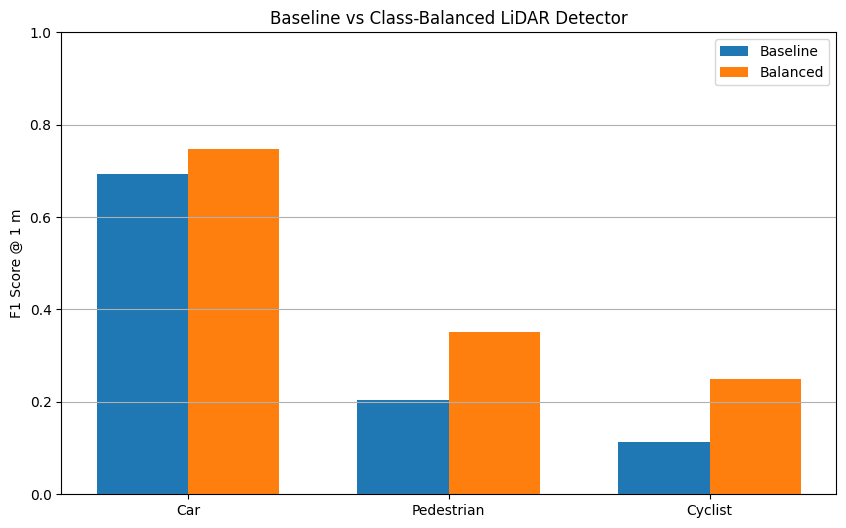


✅ Balanced-model evaluation complete.


In [42]:
# ============================================================
# EVALUATE BALANCED MODEL ON ALL 64 VALIDATION FRAMES
#
# Compare against our original baseline detector.
#
# NO TRAINING happens here.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time


# ============================================================
# 1. Configuration
# ============================================================

CLASS_NAMES_BAL = [
    "Car",
    "Pedestrian",
    "Cyclist"
]

NUM_CLASSES_BAL = 3

MIN_CANDIDATE_SCORE_BAL = 0.01

THRESHOLDS_BAL = np.arange(
    0.02,
    0.82,
    0.02
)

TUNING_DISTANCE_BAL = 1.0


# ============================================================
# 2. Load BALANCED checkpoint
# ============================================================

balanced_checkpoint_path = Path(
    "checkpoints/stride4_bev_detector_balanced_best.pt"
)


print("==========================================")
print("BALANCED MODEL VALIDATION")
print("==========================================")

print(
    "\nCheckpoint exists:",
    balanced_checkpoint_path.exists()
)


balanced_checkpoint = torch.load(
    balanced_checkpoint_path,
    map_location=device,
    weights_only=False
)


balanced_eval_model = (
    Stride4CenterDetector(
        num_classes=3
    )
    .to(device)
)


balanced_eval_model.load_state_dict(
    balanced_checkpoint[
        "model_state_dict"
    ]
)


balanced_eval_model.eval()


print(
    "\nBest epoch:",
    balanced_checkpoint["epoch"]
)

print(
    "Train loss:",
    round(
        balanced_checkpoint["train_loss"],
        4
    )
)

print(
    "Validation loss:",
    round(
        balanced_checkpoint["validation_loss"],
        4
    )
)


# ============================================================
# 3. Run inference over all validation frames
# ============================================================

balanced_validation_records = {}


start_time = time.perf_counter()


for frame_number, frame_id in enumerate(
    validation_frame_ids,
    start=1
):

    frame_id = str(
        frame_id
    )


    # --------------------------------------------------------
    # BEV + full target
    # --------------------------------------------------------

    bev_sample, target_full, counts = (
        build_kitti_training_sample(
            frame_id
        )
    )


    # --------------------------------------------------------
    # Stride-4 target
    # --------------------------------------------------------

    target_low = F.max_pool2d(

        target_full.unsqueeze(0),

        kernel_size=OUTPUT_STRIDE,

        stride=OUTPUT_STRIDE

    )[0]


    # --------------------------------------------------------
    # GPU
    # --------------------------------------------------------

    bev_gpu = (
        bev_sample
        .unsqueeze(0)
        .to(device)
    )


    # --------------------------------------------------------
    # FP32 inference
    # --------------------------------------------------------

    with torch.no_grad():

        logits = balanced_eval_model(
            bev_gpu
        )[0]


    probabilities = torch.sigmoid(
        logits
    )


    probabilities = torch.nan_to_num(

        probabilities,

        nan=0.0,

        posinf=1.0,

        neginf=0.0
    )


    # --------------------------------------------------------
    # Local maximum suppression
    # --------------------------------------------------------

    pooled = F.max_pool2d(

        probabilities.unsqueeze(0),

        kernel_size=5,

        stride=1,

        padding=2

    )[0]


    peak_map = torch.where(

        probabilities == pooled,

        probabilities,

        torch.zeros_like(
            probabilities
        )
    )


    frame_record = {}


    # ========================================================
    # Per class
    # ========================================================

    for class_id in range(
        NUM_CLASSES_BAL
    ):


        # ----------------------------------------------------
        # Ground truth centers
        # ----------------------------------------------------

        gt_positions = np.argwhere(

            target_low[
                class_id
            ].numpy()

            == 1.0
        )


        gt_centers = np.array(

            [
                [
                    int(position[0]),
                    int(position[1])
                ]

                for position
                in gt_positions
            ],

            dtype=np.float32
        )


        if len(gt_centers) == 0:

            gt_centers = np.empty(
                (0, 2),
                dtype=np.float32
            )


        # ----------------------------------------------------
        # Predicted peaks
        # ----------------------------------------------------

        class_peak_map = (
            peak_map[
                class_id
            ]
        )


        candidate_indices = torch.nonzero(

            class_peak_map
            >=
            MIN_CANDIDATE_SCORE_BAL,

            as_tuple=False
        )


        predictions = []


        for index in candidate_indices:

            px = int(
                index[0].item()
            )

            py = int(
                index[1].item()
            )


            score = float(

                class_peak_map[
                    px,
                    py
                ].item()
            )


            predictions.append(
                [
                    px,
                    py,
                    score
                ]
            )


        # Highest confidence first
        predictions.sort(

            key=lambda x: x[2],

            reverse=True
        )


        predictions = np.array(

            predictions,

            dtype=np.float32
        )


        if len(predictions) == 0:

            predictions = np.empty(
                (0, 3),
                dtype=np.float32
            )


        frame_record[
            class_id
        ] = {

            "gt":
                gt_centers,

            "predictions":
                predictions
        }


    balanced_validation_records[
        frame_id
    ] = frame_record


    if (
        frame_number == 1
        or
        frame_number % 10 == 0
        or
        frame_number
        ==
        len(validation_frame_ids)
    ):

        print(

            f"Processed "
            f"{frame_number:2d}/"
            f"{len(validation_frame_ids)} "
            f"frames"
        )


torch.cuda.synchronize()


print(
    "\nProcessing time:",
    round(
        time.perf_counter()
        -
        start_time,
        1
    ),
    "seconds"
)


# ============================================================
# 4. Evaluation helper
#
# Same matching logic used for baseline.
# ============================================================

def evaluate_balanced_class(
    class_id,
    confidence_threshold,
    distance_tolerance
):

    total_gt = 0

    total_predictions = 0

    tp = 0
    fp = 0
    fn = 0

    localization_errors = []


    for frame_id, frame_record in (
        balanced_validation_records.items()
    ):

        gt = (
            frame_record[
                class_id
            ]["gt"]
        )


        predictions = (
            frame_record[
                class_id
            ]["predictions"]
        )


        # ----------------------------------------------------
        # Confidence filtering
        # ----------------------------------------------------

        if len(predictions) > 0:

            predictions = predictions[

                predictions[:, 2]
                >=
                confidence_threshold

            ]


        total_gt += len(
            gt
        )

        total_predictions += len(
            predictions
        )


        gt_used = np.zeros(
            len(gt),
            dtype=bool
        )


        # ----------------------------------------------------
        # Confidence-ordered matching
        # ----------------------------------------------------

        for prediction in predictions:

            px = prediction[0]
            py = prediction[1]


            if len(gt) == 0:

                fp += 1

                continue


            dx = (
                gt[:, 0]
                -
                px
            )

            dy = (
                gt[:, 1]
                -
                py
            )


            distances = (

                np.sqrt(
                    dx**2
                    +
                    dy**2
                )

                *

                OUTPUT_RESOLUTION
            )


            distances[
                gt_used
            ] = np.inf


            nearest_gt = int(
                np.argmin(
                    distances
                )
            )


            nearest_distance = float(
                distances[
                    nearest_gt
                ]
            )


            if (
                nearest_distance
                <=
                distance_tolerance
            ):

                tp += 1

                gt_used[
                    nearest_gt
                ] = True


                localization_errors.append(
                    nearest_distance
                )


            else:

                fp += 1


        fn += int(
            np.sum(
                ~gt_used
            )
        )


    # ========================================================
    # Metrics
    # ========================================================

    precision = (

        tp
        /
        (tp + fp)

        if
        (tp + fp) > 0

        else
        0.0
    )


    recall = (

        tp
        /
        (tp + fn)

        if
        (tp + fn) > 0

        else
        0.0
    )


    f1 = (

        2
        *
        precision
        *
        recall
        /
        (
            precision
            +
            recall
        )

        if
        (
            precision
            +
            recall
        ) > 0

        else
        0.0
    )


    mean_error = (

        float(
            np.mean(
                localization_errors
            )
        )

        if localization_errors

        else
        np.nan
    )


    return {

        "gt":
            total_gt,

        "predictions":
            total_predictions,

        "tp":
            tp,

        "fp":
            fp,

        "fn":
            fn,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "mean_error":
            mean_error
    }


# ============================================================
# 5. Find balanced-model threshold per class
# ============================================================

balanced_best_thresholds = {}

balanced_threshold_curves = {}


print("\n==========================================")
print("BALANCED THRESHOLD SEARCH")
print("==========================================")


for class_id, class_name in enumerate(
    CLASS_NAMES_BAL
):

    best_threshold = None

    best_f1 = -1.0

    curve = []


    for threshold in THRESHOLDS_BAL:

        metrics = evaluate_balanced_class(

            class_id,

            confidence_threshold=
                threshold,

            distance_tolerance=
                TUNING_DISTANCE_BAL
        )


        curve.append(
            (
                threshold,
                metrics["f1"]
            )
        )


        if (
            metrics["f1"]
            >
            best_f1
        ):

            best_f1 = (
                metrics["f1"]
            )

            best_threshold = (
                threshold
            )


    balanced_best_thresholds[
        class_id
    ] = best_threshold


    balanced_threshold_curves[
        class_id
    ] = curve


    print(

        f"{class_name:10s} | "

        f"threshold = "
        f"{best_threshold:.2f} | "

        f"F1@1m = "
        f"{best_f1:.3f}"
    )


# ============================================================
# 6. Balanced results at 1 meter
# ============================================================

balanced_results_1m = {}


print("\n==========================================")
print("BALANCED MODEL - 1.0 m RESULTS")
print("==========================================")


balanced_total_tp = 0
balanced_total_fp = 0
balanced_total_fn = 0


for class_id, class_name in enumerate(
    CLASS_NAMES_BAL
):

    threshold = (
        balanced_best_thresholds[
            class_id
        ]
    )


    metrics = evaluate_balanced_class(

        class_id,

        confidence_threshold=
            threshold,

        distance_tolerance=
            1.0
    )


    balanced_results_1m[
        class_id
    ] = metrics


    balanced_total_tp += (
        metrics["tp"]
    )

    balanced_total_fp += (
        metrics["fp"]
    )

    balanced_total_fn += (
        metrics["fn"]
    )


    print(
        f"\n{class_name}"
    )

    print(
        f"  Threshold  : "
        f"{threshold:.2f}"
    )

    print(
        f"  GT         : "
        f"{metrics['gt']}"
    )

    print(
        f"  TP / FP / FN: "
        f"{metrics['tp']} / "
        f"{metrics['fp']} / "
        f"{metrics['fn']}"
    )

    print(
        f"  Precision  : "
        f"{metrics['precision']:.3f}"
    )

    print(
        f"  Recall     : "
        f"{metrics['recall']:.3f}"
    )

    print(
        f"  F1         : "
        f"{metrics['f1']:.3f}"
    )

    print(
        f"  Mean error : "
        f"{metrics['mean_error']:.3f} m"
    )


# ============================================================
# 7. Overall balanced metrics
# ============================================================

balanced_overall_precision = (

    balanced_total_tp

    /

    (
        balanced_total_tp
        +
        balanced_total_fp
    )

    if
    (
        balanced_total_tp
        +
        balanced_total_fp
    ) > 0

    else 0
)


balanced_overall_recall = (

    balanced_total_tp

    /

    (
        balanced_total_tp
        +
        balanced_total_fn
    )

    if
    (
        balanced_total_tp
        +
        balanced_total_fn
    ) > 0

    else 0
)


balanced_overall_f1 = (

    2
    *
    balanced_overall_precision
    *
    balanced_overall_recall

    /

    (
        balanced_overall_precision
        +
        balanced_overall_recall
    )

    if
    (
        balanced_overall_precision
        +
        balanced_overall_recall
    ) > 0

    else 0
)


print("\nOVERALL")

print(
    "  TP / FP / FN:",
    balanced_total_tp,
    "/",
    balanced_total_fp,
    "/",
    balanced_total_fn
)

print(
    "  Precision:",
    round(
        balanced_overall_precision,
        3
    )
)

print(
    "  Recall   :",
    round(
        balanced_overall_recall,
        3
    )
)

print(
    "  F1       :",
    round(
        balanced_overall_f1,
        3
    )
)


# ============================================================
# 8. BASELINE vs BALANCED comparison
#
# Uses earlier baseline all_results if still in notebook.
# ============================================================

if (
    "all_results" in globals()
    and
    1.0 in all_results
):

    print("\n==========================================")
    print("BASELINE vs BALANCED @ 1.0 m")
    print("==========================================\n")


    print(

        f"{'Class':<14}"
        f"{'Baseline F1':<16}"
        f"{'Balanced F1':<16}"
        f"{'Change':<12}"
    )


    print(
        "-" * 58
    )


    baseline_f1_values = []

    balanced_f1_values = []


    for class_id, class_name in enumerate(
        CLASS_NAMES_BAL
    ):

        baseline_f1 = (
            all_results[
                1.0
            ][
                class_id
            ]["f1"]
        )


        balanced_f1 = (
            balanced_results_1m[
                class_id
            ]["f1"]
        )


        change = (
            balanced_f1
            -
            baseline_f1
        )


        baseline_f1_values.append(
            baseline_f1
        )

        balanced_f1_values.append(
            balanced_f1
        )


        print(

            f"{class_name:<14}"

            f"{baseline_f1:<16.3f}"

            f"{balanced_f1:<16.3f}"

            f"{change:+.3f}"
        )


    # --------------------------------------------------------
    # Comparison plot
    # --------------------------------------------------------

    x = np.arange(
        len(
            CLASS_NAMES_BAL
        )
    )


    width = 0.35


    plt.figure(
        figsize=(10, 6)
    )


    plt.bar(

        x - width / 2,

        baseline_f1_values,

        width,

        label="Baseline"
    )


    plt.bar(

        x + width / 2,

        balanced_f1_values,

        width,

        label="Balanced"
    )


    plt.xticks(
        x,
        CLASS_NAMES_BAL
    )


    plt.ylabel(
        "F1 Score @ 1 m"
    )


    plt.ylim(
        0,
        1.0
    )


    plt.title(
        "Baseline vs Class-Balanced LiDAR Detector"
    )


    plt.grid(
        axis="y"
    )


    plt.legend()

    plt.show()


else:

    print(
        "\nBaseline metric variables were not found."
    )

    print(
        "That's okay — balanced results above are still valid."
    )


print("\n✅ Balanced-model evaluation complete.")

In [ ]:
# ============================================================
# DEVELOPMENT BENCHMARK EVALUATION — 256 FRAMES
#
# This split was inspected during model development and is
# therefore NOT treated as the final untouched test set.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time


# ============================================================
# 1. Create 256-frame development benchmark split
# ============================================================

test_frame_ids = (
    usable_frame_ids[320:576]
)


print("==========================================")
print("256-FRAME DEVELOPMENT BENCHMARK")
print("==========================================")

print(
    "\nTraining frames:",
    len(train_frame_ids)
)

print(
    "Validation frames:",
    len(validation_frame_ids)
)

print(
    "Development benchmark frames:",
    len(test_frame_ids)
)


# ============================================================
# 2. Verify there is NO overlap
# ============================================================

train_set_ids = set(
    str(x)
    for x in train_frame_ids
)

val_set_ids = set(
    str(x)
    for x in validation_frame_ids
)

test_set_ids = set(
    str(x)
    for x in test_frame_ids
)


train_test_overlap = (
    train_set_ids
    &
    test_set_ids
)

val_test_overlap = (
    val_set_ids
    &
    test_set_ids
)


print(
    "\nTrain ↔ Development benchmark overlap:",
    len(train_test_overlap)
)

print(
    "Validation ↔ Development benchmark overlap:",
    len(val_test_overlap)
)


if (
    len(train_test_overlap) == 0
    and
    len(val_test_overlap) == 0
):

    print(
    "\n✅ Development benchmark has no overlap with "
    "training or validation."
)

else:

    print(
        "\n❌ WARNING: dataset leakage detected."
    )


# ============================================================
# 3. Validation-tuned thresholds
#
# DO NOT CHANGE THESE USING DEVELOPMENT BENCHMARK RESULTS.
# ============================================================

print("\n==========================================")
print("FIXED VALIDATION-TUNED THRESHOLDS")
print("==========================================\n")


for class_id, class_name in enumerate(
    CLASS_NAMES
):

    print(
        f"{class_name:10s}: "
        f"{balanced_best_thresholds[class_id]:.2f}"
    )


# ============================================================
# 4. Reload best balanced model
# ============================================================

balanced_test_checkpoint = Path(
    "checkpoints/stride4_bev_detector_balanced_best.pt"
)


test_checkpoint = torch.load(
    balanced_test_checkpoint,
    map_location=device,
    weights_only=False
)


test_model = (
    Stride4CenterDetector(
        num_classes=3
    )
    .to(device)
)


test_model.load_state_dict(
    test_checkpoint[
        "model_state_dict"
    ]
)


test_model.eval()


print(
    "\nModel checkpoint epoch:",
    test_checkpoint["epoch"]
)

print(
    "Model device:",
    next(
        test_model.parameters()
    ).device
)


# ============================================================
# 5. Development benchmark inference storage
# ============================================================

test_records = {}


MIN_TEST_CANDIDATE_SCORE = 0.01


start_test_time = time.perf_counter()


# ============================================================
# 6. Run inference over all 256 development benchmark frames
# ============================================================

for frame_number, frame_id in enumerate(
    test_frame_ids,
    start=1
):

    frame_id = str(
        frame_id
    )


    # --------------------------------------------------------
    # Build BEV + GT
    # --------------------------------------------------------

    bev_sample, target_full, counts = (
        build_kitti_training_sample(
            frame_id
        )
    )


    target_low = F.max_pool2d(

        target_full.unsqueeze(0),

        kernel_size=OUTPUT_STRIDE,

        stride=OUTPUT_STRIDE

    )[0]


    # --------------------------------------------------------
    # GPU input
    # --------------------------------------------------------

    bev_gpu = (
        bev_sample
        .unsqueeze(0)
        .to(device)
    )


    # --------------------------------------------------------
    # FP32 inference
    # --------------------------------------------------------

    with torch.no_grad():

        logits = test_model(
            bev_gpu
        )[0]


    probabilities = torch.sigmoid(
        logits
    )


    probabilities = torch.nan_to_num(

        probabilities,

        nan=0.0,

        posinf=1.0,

        neginf=0.0
    )


    # --------------------------------------------------------
    # Local maximum suppression
    # --------------------------------------------------------

    pooled = F.max_pool2d(

        probabilities.unsqueeze(0),

        kernel_size=5,

        stride=1,

        padding=2

    )[0]


    peak_map = torch.where(

        probabilities == pooled,

        probabilities,

        torch.zeros_like(
            probabilities
        )
    )


    frame_record = {}


    # ========================================================
    # Class data
    # ========================================================

    for class_id in range(3):


        # ----------------------------------------------------
        # GT centers
        # ----------------------------------------------------

        gt_positions = np.argwhere(

            target_low[
                class_id
            ].numpy()

            == 1.0
        )


        gt_centers = np.array(

            [
                [
                    int(pos[0]),
                    int(pos[1])
                ]

                for pos in gt_positions
            ],

            dtype=np.float32
        )


        if len(gt_centers) == 0:

            gt_centers = np.empty(
                (0, 2),
                dtype=np.float32
            )


        # ----------------------------------------------------
        # Prediction peaks
        # ----------------------------------------------------

        class_peak_map = (
            peak_map[
                class_id
            ]
        )


        candidate_indices = torch.nonzero(

            class_peak_map
            >=
            MIN_TEST_CANDIDATE_SCORE,

            as_tuple=False
        )


        predictions = []


        for index in candidate_indices:

            px = int(
                index[0].item()
            )

            py = int(
                index[1].item()
            )


            score = float(

                class_peak_map[
                    px,
                    py
                ].item()
            )


            predictions.append(
                [
                    px,
                    py,
                    score
                ]
            )


        predictions.sort(

            key=lambda x: x[2],

            reverse=True
        )


        predictions = np.array(

            predictions,

            dtype=np.float32
        )


        if len(predictions) == 0:

            predictions = np.empty(
                (0, 3),
                dtype=np.float32
            )


        frame_record[
            class_id
        ] = {

            "gt":
                gt_centers,

            "predictions":
                predictions
        }


    test_records[
        frame_id
    ] = frame_record


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        frame_number == 1
        or
        frame_number % 25 == 0
        or
        frame_number == len(test_frame_ids)
    ):

        print(

            f"Processed "
            f"{frame_number:3d}/"
            f"{len(test_frame_ids)} "
            f"development benchmark frames"
        )


torch.cuda.synchronize()


test_processing_time = (

    time.perf_counter()

    -

    start_test_time
)


print(
    "\nDevelopment benchmark processing time:",
    round(
        test_processing_time,
        1
    ),
    "seconds"
)


# ============================================================
# 7. Evaluation function
# ============================================================

def evaluate_test_class(
    class_id,
    confidence_threshold,
    distance_tolerance
):

    total_gt = 0

    total_predictions = 0

    tp = 0
    fp = 0
    fn = 0

    localization_errors = []


    for frame_id, frame_record in (
        test_records.items()
    ):

        gt = (
            frame_record[
                class_id
            ]["gt"]
        )


        predictions = (
            frame_record[
                class_id
            ]["predictions"]
        )


        # ----------------------------------------------------
        # FIXED validation threshold
        # ----------------------------------------------------

        if len(predictions) > 0:

            predictions = predictions[

                predictions[:, 2]
                >=
                confidence_threshold

            ]


        total_gt += len(
            gt
        )

        total_predictions += len(
            predictions
        )


        gt_used = np.zeros(
            len(gt),
            dtype=bool
        )


        # ----------------------------------------------------
        # Score-ordered matching
        # ----------------------------------------------------

        for prediction in predictions:

            px = prediction[0]

            py = prediction[1]


            if len(gt) == 0:

                fp += 1

                continue


            dx = (
                gt[:, 0]
                -
                px
            )


            dy = (
                gt[:, 1]
                -
                py
            )


            distances = (

                np.sqrt(
                    dx**2
                    +
                    dy**2
                )

                *

                OUTPUT_RESOLUTION
            )


            distances[
                gt_used
            ] = np.inf


            nearest_gt = int(
                np.argmin(
                    distances
                )
            )


            nearest_distance = float(
                distances[
                    nearest_gt
                ]
            )


            if (
                nearest_distance
                <=
                distance_tolerance
            ):

                tp += 1


                gt_used[
                    nearest_gt
                ] = True


                localization_errors.append(
                    nearest_distance
                )


            else:

                fp += 1


        fn += int(
            np.sum(
                ~gt_used
            )
        )


    # ========================================================
    # Metrics
    # ========================================================

    precision = (

        tp / (tp + fp)

        if
        (tp + fp) > 0

        else 0.0
    )


    recall = (

        tp / (tp + fn)

        if
        (tp + fn) > 0

        else 0.0
    )


    f1 = (

        2
        *
        precision
        *
        recall

        /

        (
            precision
            +
            recall
        )

        if
        (
            precision
            +
            recall
        ) > 0

        else 0.0
    )


    mean_error = (

        float(
            np.mean(
                localization_errors
            )
        )

        if localization_errors

        else np.nan
    )


    median_error = (

        float(
            np.median(
                localization_errors
            )
        )

        if localization_errors

        else np.nan
    )


    return {

        "gt":
            total_gt,

        "predictions":
            total_predictions,

        "tp":
            tp,

        "fp":
            fp,

        "fn":
            fn,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "mean_error":
            mean_error,

        "median_error":
            median_error
    }


# ============================================================
# 8. DEVELOPMENT BENCHMARK evaluation at 1.0 meter
# ============================================================

TEST_DISTANCE = 1.0


test_results_1m = {}


total_test_tp = 0
total_test_fp = 0
total_test_fn = 0


print("\n==========================================")
print("256-FRAME DEVELOPMENT BENCHMARK RESULTS @ 1.0 m")
print("==========================================")


for class_id, class_name in enumerate(
    CLASS_NAMES
):

    threshold = (
        balanced_best_thresholds[
            class_id
        ]
    )


    metrics = evaluate_test_class(

        class_id,

        confidence_threshold=
            threshold,

        distance_tolerance=
            TEST_DISTANCE
    )


    test_results_1m[
        class_id
    ] = metrics


    total_test_tp += (
        metrics["tp"]
    )

    total_test_fp += (
        metrics["fp"]
    )

    total_test_fn += (
        metrics["fn"]
    )


    print(
        f"\n{class_name}"
    )


    print(
        f"  Fixed threshold : "
        f"{threshold:.2f}"
    )


    print(
        f"  GT objects      : "
        f"{metrics['gt']}"
    )


    print(
        f"  Predictions     : "
        f"{metrics['predictions']}"
    )


    print(
        f"  TP / FP / FN    : "
        f"{metrics['tp']} / "
        f"{metrics['fp']} / "
        f"{metrics['fn']}"
    )


    print(
        f"  Precision       : "
        f"{metrics['precision']:.3f}"
    )


    print(
        f"  Recall          : "
        f"{metrics['recall']:.3f}"
    )


    print(
        f"  F1              : "
        f"{metrics['f1']:.3f}"
    )


    print(
        f"  Mean loc. error : "
        f"{metrics['mean_error']:.3f} m"
    )


# ============================================================
# 9. Overall micro metrics
# ============================================================

test_precision = (

    total_test_tp

    /

    (
        total_test_tp
        +
        total_test_fp
    )

    if
    (
        total_test_tp
        +
        total_test_fp
    ) > 0

    else 0.0
)


test_recall = (

    total_test_tp

    /

    (
        total_test_tp
        +
        total_test_fn
    )

    if
    (
        total_test_tp
        +
        total_test_fn
    ) > 0

    else 0.0
)


test_f1 = (

    2
    *
    test_precision
    *
    test_recall

    /

    (
        test_precision
        +
        test_recall
    )

    if
    (
        test_precision
        +
        test_recall
    ) > 0

    else 0.0
)


print("\n------------------------------------------")
print("OVERALL DEVELOPMENT BENCHMARK RESULT")
print("------------------------------------------")


print(
    "\nTP / FP / FN:",
    total_test_tp,
    "/",
    total_test_fp,
    "/",
    total_test_fn
)


print(
    "Precision:",
    round(
        test_precision,
        3
    )
)


print(
    "Recall   :",
    round(
        test_recall,
        3
    )
)


print(
    "F1       :",
    round(
        test_f1,
        3
    )
)


# ============================================================
# 10. Plot per-class development benchmark scores
# ============================================================

test_precision_values = [

    test_results_1m[
        class_id
    ]["precision"]

    for class_id in range(3)
]


test_recall_values = [

    test_results_1m[
        class_id
    ]["recall"]

    for class_id in range(3)
]


test_f1_values = [

    test_results_1m[
        class_id
    ]["f1"]

    for class_id in range(3)
]


x = np.arange(
    3
)


width = 0.25


plt.figure(
    figsize=(10, 6)
)


plt.bar(

    x - width,

    test_precision_values,

    width,

    label="Precision"
)


plt.bar(

    x,

    test_recall_values,

    width,

    label="Recall"
)


plt.bar(

    x + width,

    test_f1_values,

    width,

    label="F1"
)


plt.xticks(
    x,
    CLASS_NAMES
)


plt.ylim(
    0,
    1.05
)


plt.ylabel(
    "Score"
)


plt.title(
    "Balanced LiDAR Detector - 256-Frame Development Benchmark @ 1 m"
)


plt.grid(
    axis="y"
)


plt.legend()

plt.show()


print("\n==========================================")
print("DEVELOPMENT BENCHMARK EVALUATION COMPLETE")
print("==========================================")


print(
    "\nThese 256 frames were excluded from training and "
    "threshold tuning, but their results were inspected "
    "during model development. They are therefore treated "
    "as a development benchmark, not the final test set."
)

In [ ]:
# ============================================================
# FREEZE TRAIN / VALIDATION / DEVELOPMENT BENCHMARK SPLITS
#
# Saves the exact frame IDs used in our experiment so that:
# - future training cannot accidentally include development benchmark frames
# - notebook restarts reproduce the same experiment splits
# - GitHub documentation can describe the split clearly
# Everything is stored inside the project directory.
# ============================================================

from pathlib import Path
import json


# ============================================================
# 1. Create experiment folder
# ============================================================

experiment_dir = Path(
    "experiment_data"
)

experiment_dir.mkdir(
    exist_ok=True
)


# ============================================================
# 2. Convert NumPy strings -> normal Python strings
# ============================================================

train_ids_frozen = [
    str(x)
    for x in train_frame_ids
]

validation_ids_frozen = [
    str(x)
    for x in validation_frame_ids
]

test_ids_frozen = [
    str(x)
    for x in test_frame_ids
]


# ============================================================
# 3. Save each split as TXT
# ============================================================

with open(
    experiment_dir / "train_frames.txt",
    "w"
) as f:

    for frame_id in train_ids_frozen:
        f.write(
            frame_id + "\n"
        )


with open(
    experiment_dir / "validation_frames.txt",
    "w"
) as f:

    for frame_id in validation_ids_frozen:
        f.write(
            frame_id + "\n"
        )


with open(
    experiment_dir / "test_frames.txt",
    "w"
) as f:

    for frame_id in test_ids_frozen:
        f.write(
            frame_id + "\n"
        )


# ============================================================
# 4. Save experiment metadata + development benchmark metrics
# ============================================================

experiment_summary = {

    "dataset":
        "KITTI 3D Object Detection",

    "input_bev_shape":
        [3, 500, 400],

    "output_heatmap_shape":
        [3, 125, 100],

    "output_stride":
        4,

    "bev_resolution_m":
        0.1,

    "output_resolution_m":
        0.4,

    "matching_tolerance_m":
        1.0,

    "train_frames":
        len(train_ids_frozen),

    "validation_frames":
        len(validation_ids_frozen),

    "test_frames":
        len(test_ids_frozen),

    "validation_tuned_thresholds": {

        "Car":
            float(
                balanced_best_thresholds[0]
            ),

        "Pedestrian":
            float(
                balanced_best_thresholds[1]
            ),

        "Cyclist":
            float(
                balanced_best_thresholds[2]
            )
    },

    # Historical key name retained for compatibility.
    # These are development-benchmark metrics, NOT final-test metrics.
    "held_out_test_metrics": {

        "Car": {
            "precision": 0.801,
            "recall": 0.715,
            "f1": 0.756,
            "mean_localization_error_m": 0.246
        },

        "Pedestrian": {
            "precision": 0.375,
            "recall": 0.244,
            "f1": 0.296,
            "mean_localization_error_m": 0.109
        },

        "Cyclist": {
            "precision": 0.600,
            "recall": 0.113,
            "f1": 0.190,
            "mean_localization_error_m": 0.067
        },

        "Overall": {
            "precision": 0.757,
            "recall": 0.627,
            "f1": 0.686
        }
    }
}


with open(
    experiment_dir / "baseline_experiment.json",
    "w"
) as f:

    json.dump(
        experiment_summary,
        f,
        indent=4
    )


# ============================================================
# 5. Verify no overlap again
# ============================================================

train_set = set(
    train_ids_frozen
)

val_set = set(
    validation_ids_frozen
)

test_set = set(
    test_ids_frozen
)


print("==========================================")
print("EXPERIMENT SPLIT FROZEN")
print("==========================================")

print(
    "\nTrain frames:",
    len(train_set)
)

print(
    "Validation frames:",
    len(val_set)
)

print(
    "Development benchmark frames:",
    len(test_set)
)


print(
    "\nTrain ∩ Validation:",
    len(
        train_set & val_set
    )
)

print(
    "Train ∩ Development benchmark:",
    len(
        train_set & test_set
    )
)

print(
    "Validation ∩ Development benchmark:",
    len(
        val_set & test_set
    )
)


print("\nSaved files:")

print(
    experiment_dir.resolve()
    / "train_frames.txt"
)

print(
    experiment_dir.resolve()
    / "validation_frames.txt"
)

print(
    experiment_dir.resolve()
    / "test_frames.txt"
)

print(
    experiment_dir.resolve()
    / "baseline_experiment.json"
)


if (
    len(train_set & val_set) == 0
    and
    len(train_set & test_set) == 0
    and
    len(val_set & test_set) == 0
):

    print(
        "\n✅ Original experiment splits are frozen with zero overlap."
    )

In [ ]:
# ============================================================
# BUILD EXPANDED 2,000-FRAME TRAINING SPLIT
#
# Important:
# - Keep original 256 training frames
# - Keep existing 64 validation frames unchanged
# - NEVER use the frozen 256-frame development benchmark
# - Add 1,744 new training frames
# - Save the exact expanded split to experiment_data/
#
# NO TRAINING happens here.
# ============================================================

from pathlib import Path
from collections import Counter

import numpy as np


# ============================================================
# 1. Configuration
# ============================================================

EXPANDED_TRAIN_SIZE = 2000

EXPANDED_RANDOM_SEED = 2026


experiment_dir = Path(
    "experiment_data"
)


# ============================================================
# 2. Use the FROZEN split IDs
# ============================================================

original_train_ids = [
    str(x)
    for x in train_ids_frozen
]

frozen_validation_ids = [
    str(x)
    for x in validation_ids_frozen
]

# Historical variable name retained for compatibility.
# These IDs represent the 256-frame development benchmark.
frozen_test_ids = [
    str(x)
    for x in test_ids_frozen
]


original_train_set = set(
    original_train_ids
)

validation_set = set(
    frozen_validation_ids
)

test_set = set(
    frozen_test_ids
)


print("==========================================")
print("EXPANDED TRAINING SPLIT")
print("==========================================")

print(
    "\nOriginal training frames:",
    len(original_train_set)
)

print(
    "Frozen validation frames:",
    len(validation_set)
)

print(
    "Frozen development benchmark frames:",
    len(test_set)
)


# ============================================================
# 3. Find candidate frames that are safe for additional training
#
# We exclude:
# - original training frames
# - validation frames
# - 256-frame development benchmark
# ============================================================

all_usable_ids = [
    str(x)
    for x in usable_frame_ids
]


additional_candidates = [

    frame_id

    for frame_id in all_usable_ids

    if (
        frame_id not in original_train_set
        and
        frame_id not in validation_set
        and
        frame_id not in test_set
    )
]


print(
    "\nSafe additional candidate frames:",
    len(additional_candidates)
)


# ============================================================
# 4. Number of additional frames required
# ============================================================

num_additional_needed = (

    EXPANDED_TRAIN_SIZE

    -

    len(original_train_ids)
)


print(
    "Additional frames needed:",
    num_additional_needed
)


if (
    len(additional_candidates)
    <
    num_additional_needed
):

    raise RuntimeError(

        "Not enough safe KITTI frames "
        "to create the requested training set."
    )


# ============================================================
# 5. Reproducibly sample additional frames
# ============================================================

rng_expanded = np.random.default_rng(
    EXPANDED_RANDOM_SEED
)


additional_candidates_array = np.array(
    additional_candidates
)


rng_expanded.shuffle(
    additional_candidates_array
)


new_training_ids = (

    additional_candidates_array[
        :num_additional_needed
    ]

    .tolist()
)


# ============================================================
# 6. Final expanded training set
#
# Original 256 are preserved.
# ============================================================

expanded_train_frame_ids = (

    original_train_ids

    +

    new_training_ids
)


expanded_train_set = set(
    expanded_train_frame_ids
)


print(
    "\nExpanded training frames:",
    len(expanded_train_frame_ids)
)


# ============================================================
# 7. Leakage checks
# ============================================================

train_val_overlap = (
    expanded_train_set
    &
    validation_set
)


train_test_overlap = (
    expanded_train_set
    &
    test_set
)


print("\n==========================================")
print("LEAKAGE CHECK")
print("==========================================")

print(
    "\nExpanded Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Expanded Train ∩ Development benchmark:",
    len(train_test_overlap)
)


# Make sure the original training set is still included
missing_original_frames = (

    original_train_set

    -

    expanded_train_set
)


print(
    "Original train frames missing:",
    len(missing_original_frames)
)


if (
    len(train_val_overlap) == 0
    and
    len(train_test_overlap) == 0
    and
    len(missing_original_frames) == 0
):

    print(
        "\n✅ Expanded training split has zero overlap with "
        "validation and the development benchmark."
    )

else:

    raise RuntimeError(
        "Split verification failed."
    )


# ============================================================
# 8. Save expanded training IDs
# ============================================================

expanded_split_path = (

    experiment_dir

    /

    "expanded_train_2000_frames.txt"
)


with open(
    expanded_split_path,
    "w"
) as f:

    for frame_id in expanded_train_frame_ids:

        f.write(
            frame_id + "\n"
        )


print(
    "\nExpanded split saved at:"
)

print(
    expanded_split_path.resolve()
)


# ============================================================
# 9. Fast helper:
# Count KITTI target objects INSIDE our BEV region
#
# Unlike build_kitti_training_sample(), this does NOT load
# the large LiDAR .bin file. It only reads label + calibration.
# Much faster for analyzing 2,000 frames.
# ============================================================

def count_bev_objects_fast(
    frame_id
):

    frame_id = str(
        frame_id
    )


    label_file = (
        DATA_ROOT
        /
        "label_2"
        /
        f"{frame_id}.txt"
    )


    calib_file = (
        DATA_ROOT
        /
        "calib"
        /
        f"{frame_id}.txt"
    )


    # --------------------------------------------------------
    # Read calibration
    # --------------------------------------------------------

    calib = {}


    with open(
        calib_file,
        "r"
    ) as f:

        for line in f:

            line = line.strip()


            if (
                not line
                or
                ":" not in line
            ):

                continue


            key, value = line.split(
                ":",
                1
            )


            calib[key] = np.array(
                [
                    float(v)
                    for v in value.split()
                ],
                dtype=np.float64
            )


    R0 = (
        calib["R0_rect"]
        .reshape(3, 3)
    )


    R0_4 = np.eye(4)

    R0_4[
        :3,
        :3
    ] = R0


    Tr = (
        calib["Tr_velo_to_cam"]
        .reshape(3, 4)
    )


    Tr_4 = np.eye(4)

    Tr_4[
        :3,
        :
    ] = Tr


    T_camera_from_lidar = (

        R0_4

        @

        Tr_4
    )


    T_lidar_from_camera = np.linalg.inv(
        T_camera_from_lidar
    )


    # --------------------------------------------------------
    # Count target classes inside our BEV ROI
    # --------------------------------------------------------

    counts = {

        "Car": 0,

        "Pedestrian": 0,

        "Cyclist": 0
    }


    with open(
        label_file,
        "r"
    ) as f:

        for line in f:

            values = (
                line.strip()
                .split()
            )


            if len(values) < 15:

                continue


            object_type = values[0]


            if object_type not in CLASS_TO_ID:

                continue


            # KITTI camera coordinates
            x_cam = float(
                values[11]
            )

            y_cam = float(
                values[12]
            )

            z_cam = float(
                values[13]
            )


            camera_point = np.array(
                [
                    x_cam,
                    y_cam,
                    z_cam,
                    1.0
                ]
            )


            lidar_point = (

                T_lidar_from_camera

                @

                camera_point
            )


            x_lidar = float(
                lidar_point[0]
            )

            y_lidar = float(
                lidar_point[1]
            )


            if (
                X_MIN
                <=
                x_lidar
                <
                X_MAX

                and

                Y_MIN
                <=
                y_lidar
                <
                Y_MAX
            ):

                counts[
                    object_type
                ] += 1


    return counts


# ============================================================
# 10. Analyze the expanded 2,000-frame training set
# ============================================================

expanded_object_counts = Counter()


expanded_frames_with_class = Counter()


for index, frame_id in enumerate(
    expanded_train_frame_ids,
    start=1
):

    counts = count_bev_objects_fast(
        frame_id
    )


    for class_name in CLASS_NAMES:

        expanded_object_counts[
            class_name
        ] += counts[
            class_name
        ]


        if counts[
            class_name
        ] > 0:

            expanded_frames_with_class[
                class_name
            ] += 1


    if (
        index % 250 == 0
        or
        index == len(expanded_train_frame_ids)
    ):

        print(
            f"Analyzed "
            f"{index}/"
            f"{len(expanded_train_frame_ids)} "
            f"frames"
        )


# ============================================================
# 11. Print class distribution
# ============================================================

total_expanded_objects = sum(
    expanded_object_counts.values()
)


print("\n==========================================")
print("2,000-FRAME TRAINING DISTRIBUTION")
print("==========================================")


for class_name in CLASS_NAMES:

    count = expanded_object_counts[
        class_name
    ]


    percentage = (

        count

        /

        total_expanded_objects

        *

        100
    )


    print(
        f"\n{class_name}"
    )

    print(
        "  Objects:",
        count
    )

    print(
        "  Percentage:",
        round(
            percentage,
            2
        ),
        "%"
    )

    print(
        "  Frames containing class:",
        expanded_frames_with_class[
            class_name
        ],
        "/",
        len(expanded_train_frame_ids)
    )


# ============================================================
# 12. Compare amount of training data
# ============================================================

print("\n==========================================")
print("DATA SCALE CHANGE")
print("==========================================")


print(
    "\nOld training frames:",
    256
)

print(
    "New training frames:",
    len(expanded_train_frame_ids)
)

print(
    "Training-set increase:",
    round(
        len(expanded_train_frame_ids)
        /
        256,
        2
    ),
    "x"
)


print(
    "\n✅ 2,000-frame training split is ready."
)

print(
    "No GPU training has been started."
)

In [ ]:
# ============================================================
# BUILD BALANCED SAMPLER FOR 2,000-FRAME TRAINING SET
#
# Goals:
# - Sample from the 2,000-frame safe training pool
# - Oversample Pedestrian / Cyclist scenes moderately
# - Preserve realistic Car representation
# - Simulate one epoch BEFORE training
#
# NO GPU TRAINING happens here.
# ============================================================

import torch
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

import numpy as np


# ============================================================
# 1. Dataset class
# ============================================================

class KITTIExpandedStride4Dataset(Dataset):

    def __init__(
        self,
        frame_ids
    ):

        self.frame_ids = [
            str(frame_id)
            for frame_id in frame_ids
        ]


    def __len__(self):

        return len(
            self.frame_ids
        )


    def __getitem__(
        self,
        index
    ):

        frame_id = (
            self.frame_ids[index]
        )


        bev_sample, full_target, counts = (
            build_kitti_training_sample(
                frame_id
            )
        )


        # ----------------------------------------------------
        # Full target:
        # [3, 500, 400]
        #
        # Stride-4 target:
        # [3, 125, 100]
        # ----------------------------------------------------

        low_target = F.max_pool2d(

            full_target.unsqueeze(0),

            kernel_size=OUTPUT_STRIDE,

            stride=OUTPUT_STRIDE

        )[0]


        return (
            bev_sample,
            low_target,
            frame_id
        )


# ============================================================
# 2. Dataset
# ============================================================

expanded_train_dataset = (
    KITTIExpandedStride4Dataset(
        expanded_train_frame_ids
    )
)


print("==========================================")
print("2,000-FRAME BALANCED SAMPLER")
print("==========================================")

print(
    "\nDataset size:",
    len(
        expanded_train_dataset
    )
)


# ============================================================
# 3. Cache object counts for every frame
#
# Uses the FAST label/calibration function from previous cell.
# Does NOT load LiDAR point clouds.
# ============================================================

expanded_frame_counts = {}


for index, frame_id in enumerate(
    expanded_train_frame_ids,
    start=1
):

    frame_id = str(
        frame_id
    )


    counts = count_bev_objects_fast(
        frame_id
    )


    expanded_frame_counts[
        frame_id
    ] = counts


    if (
        index % 500 == 0
        or
        index
        ==
        len(expanded_train_frame_ids)
    ):

        print(
            f"Cached "
            f"{index}/"
            f"{len(expanded_train_frame_ids)} "
            f"frame labels"
        )


# ============================================================
# 4. Frame-presence frequency
# ============================================================

expanded_presence = {

    "Car": 0,

    "Pedestrian": 0,

    "Cyclist": 0
}


for frame_id in expanded_train_frame_ids:

    counts = expanded_frame_counts[
        str(frame_id)
    ]


    for class_name in CLASS_NAMES:

        if counts[
            class_name
        ] > 0:

            expanded_presence[
                class_name
            ] += 1


print("\nFrames containing each class:")


for class_name in CLASS_NAMES:

    print(

        f"{class_name:10s}: "

        f"{expanded_presence[class_name]} "
        f"/ "
        f"{len(expanded_train_frame_ids)}"
    )


# ============================================================
# 5. Moderate rarity multipliers
#
# Same principle that worked in our 256-frame experiment:
#
# sqrt(total_frames / frames_containing_class)
#
# We deliberately avoid full inverse-frequency weighting.
# ============================================================

num_expanded_frames = len(
    expanded_train_frame_ids
)


expanded_class_sampling_weights = {}


for class_name in CLASS_NAMES:

    expanded_class_sampling_weights[
        class_name
    ] = np.sqrt(

        num_expanded_frames

        /

        expanded_presence[
            class_name
        ]
    )


print("\nClass sampling multipliers:")


for class_name in CLASS_NAMES:

    print(

        f"{class_name:10s}: "

        f"{expanded_class_sampling_weights[class_name]:.3f}"
    )


# ============================================================
# 6. Assign each frame a sampling weight
#
# Weight = rarest class present in that frame.
#
# Example:
#
# Car-only frame
#       -> Car multiplier
#
# Car + Pedestrian
#       -> Pedestrian multiplier
#
# Car + Cyclist
#       -> Cyclist multiplier
# ============================================================

expanded_sample_weights = []


for frame_id in expanded_train_frame_ids:

    frame_id = str(
        frame_id
    )


    counts = expanded_frame_counts[
        frame_id
    ]


    present_weights = []


    for class_name in CLASS_NAMES:

        if counts[
            class_name
        ] > 0:

            present_weights.append(

                expanded_class_sampling_weights[
                    class_name
                ]
            )


    if len(
        present_weights
    ) > 0:

        frame_weight = max(
            present_weights
        )

    else:

        frame_weight = 1.0


    expanded_sample_weights.append(
        frame_weight
    )


expanded_sample_weights = torch.tensor(

    expanded_sample_weights,

    dtype=torch.double
)


print(
    "\nMinimum frame weight:",
    round(
        expanded_sample_weights.min().item(),
        3
    )
)


print(
    "Maximum frame weight:",
    round(
        expanded_sample_weights.max().item(),
        3
    )
)


# ============================================================
# 7. Weighted sampler
#
# The sampler draws 2,000 indices with replacement.
# Minority-class frames may therefore appear multiple times.
#
# Because the DataLoader below uses drop_last=True with
# batch_size=6, training processes 333 full batches
# (1,998 samples) per epoch.
# ============================================================

EXPANDED_SAMPLER_SEED = 2026


expanded_balanced_sampler = WeightedRandomSampler(

    weights=expanded_sample_weights,

    num_samples=len(
        expanded_train_dataset
    ),

    replacement=True,

    generator=torch.Generator().manual_seed(
        EXPANDED_SAMPLER_SEED
    )
)


# ============================================================
# 8. DataLoader
#
# Batch size 6 is used for the expanded training experiment.
# ============================================================

EXPANDED_BATCH_SIZE = 6


expanded_balanced_train_loader = DataLoader(

    expanded_train_dataset,

    batch_size=EXPANDED_BATCH_SIZE,

    sampler=expanded_balanced_sampler,

    num_workers=0,

    pin_memory=True,

    drop_last=True
)


print(
    "\nTraining batches per epoch:",
    len(
        expanded_balanced_train_loader
    )
)


# ============================================================
# 9. Simulate exactly ONE sampler epoch
#
# This does NOT load LiDAR and does NOT train.
# ============================================================

simulation_generator = (
    torch.Generator()
    .manual_seed(
        EXPANDED_SAMPLER_SEED
    )
)


simulated_indices = torch.multinomial(

    expanded_sample_weights,

    num_samples=len(
        expanded_train_dataset
    ),

    replacement=True,

    generator=simulation_generator
)


simulated_object_counts = {

    "Car": 0,

    "Pedestrian": 0,

    "Cyclist": 0
}


simulated_frames_with_class = {

    "Car": 0,

    "Pedestrian": 0,

    "Cyclist": 0
}


simulated_frame_ids = []


for index in simulated_indices.tolist():

    frame_id = str(

        expanded_train_frame_ids[
            index
        ]
    )


    simulated_frame_ids.append(
        frame_id
    )


    counts = expanded_frame_counts[
        frame_id
    ]


    for class_name in CLASS_NAMES:

        simulated_object_counts[
            class_name
        ] += counts[
            class_name
        ]


        if counts[
            class_name
        ] > 0:

            simulated_frames_with_class[
                class_name
            ] += 1


# ============================================================
# 10. Unweighted 2,000-frame dataset exposure
# ============================================================

print("\n==========================================")
print("UNWEIGHTED 2,000-FRAME DATASET EXPOSURE")
print("==========================================")


for class_name in CLASS_NAMES:

    print(

        f"{class_name:10s} | "

        f"objects = "
        f"{expanded_object_counts[class_name]:5d} | "

        f"class frames = "
        f"{expanded_frames_with_class[class_name]:4d}"
    )


# ============================================================
# 11. Simulated balanced exposure
# ============================================================

total_simulated_objects = sum(

    simulated_object_counts.values()
)


print("\n==========================================")
print("SIMULATED BALANCED 2,000-FRAME EPOCH")
print("==========================================")


for class_name in CLASS_NAMES:

    percentage = (

        simulated_object_counts[
            class_name
        ]

        /

        total_simulated_objects

        *

        100
    )


    print(

        f"{class_name:10s} | "

        f"objects = "
        f"{simulated_object_counts[class_name]:5d} | "

        f"class frames = "
        f"{simulated_frames_with_class[class_name]:4d} | "

        f"{percentage:5.2f}%"
    )


# ============================================================
# 12. Duplicate statistics
# ============================================================

unique_simulated_frames = len(
    set(
        simulated_frame_ids
    )
)


repeated_samples = (

    len(
        simulated_frame_ids
    )

    -

    unique_simulated_frames
)


duplicate_percentage = (

    repeated_samples

    /

    len(
        simulated_frame_ids
    )

    *

    100
)


print("\n==========================================")
print("SAMPLING SUMMARY")
print("==========================================")


print(
    "\nSamples per epoch:",
    len(
        simulated_frame_ids
    )
)


print(
    "Unique frames sampled:",
    unique_simulated_frames
)


print(
    "Repeated samples:",
    repeated_samples
)


print(
    "Repeated percentage:",
    round(
        duplicate_percentage,
        2
    ),
    "%"
)


# ============================================================
# 13. Exposure ratios
# ============================================================

print("\n==========================================")
print("BALANCED CLASS RATIOS")
print("==========================================")


ped_count_sim = simulated_object_counts[
    "Pedestrian"
]


cyclist_count_sim = simulated_object_counts[
    "Cyclist"
]


car_count_sim = simulated_object_counts[
    "Car"
]


print(
    "\nCar : Pedestrian =",
    round(
        car_count_sim
        /
        max(
            ped_count_sim,
            1
        ),
        2
    ),
    ": 1"
)


print(
    "Car : Cyclist =",
    round(
        car_count_sim
        /
        max(
            cyclist_count_sim,
            1
        ),
        2
    ),
    ": 1"
)


print(
    "\n✅ Expanded balanced sampler is ready."
)

print(
    "No model training has been started."
)

2,000-FRAME FINE-TUNING

Training frames: 2000
Validation frames: 64
Training batches: 333
Validation batches: 11
Epochs: 4

Source checkpoint exists: True
Starting from epoch: 10
Previous validation loss: 1.2255

New checkpoint:
D:\LiDAR Project\Lidar_Project\checkpoints\stride4_bev_detector_2000_balanced_best.pt
Epoch 01/04 | Batch 001/333 | Loss 0.6910
Epoch 01/04 | Batch 025/333 | Loss 1.3938
Epoch 01/04 | Batch 050/333 | Loss 0.9444
Epoch 01/04 | Batch 075/333 | Loss 1.0074
Epoch 01/04 | Batch 100/333 | Loss 0.8187
Epoch 01/04 | Batch 125/333 | Loss 0.7967
Epoch 01/04 | Batch 150/333 | Loss 0.7415
Epoch 01/04 | Batch 175/333 | Loss 1.2805
Epoch 01/04 | Batch 200/333 | Loss 0.8308
Epoch 01/04 | Batch 225/333 | Loss 0.7899
Epoch 01/04 | Batch 250/333 | Loss 0.6656
Epoch 01/04 | Batch 275/333 | Loss 1.0019
Epoch 01/04 | Batch 300/333 | Loss 0.4914
Epoch 01/04 | Batch 325/333 | Loss 0.9374
Epoch 01/04 | Batch 333/333 | Loss 1.1591

------------------------------------------
EXPANDED E

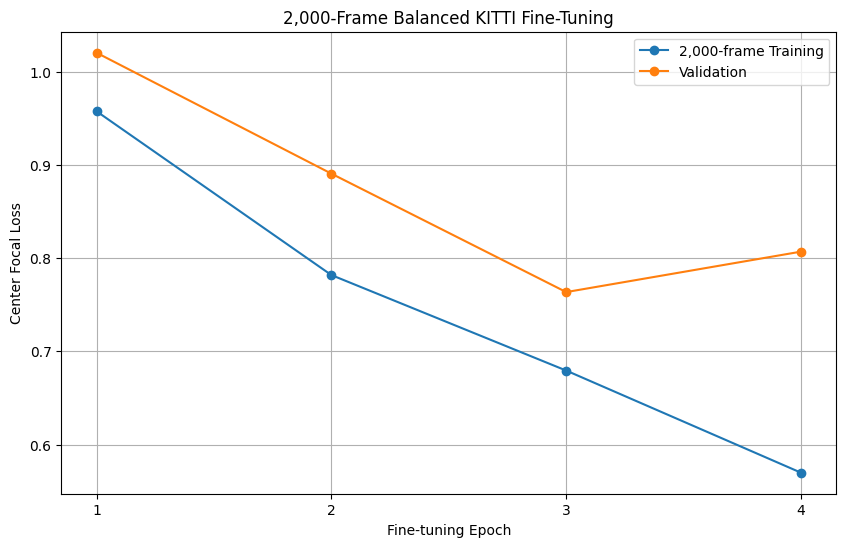


Fine-tuning results:

Epoch   Train         Validation    LR          Time(s)   
----------------------------------------------------------
1       0.9578        1.0207        0.000300    553.3     
2       0.7820        0.8909        0.000300    529.5     
3       0.6794        0.7637        0.000300    521.0     
4       0.5697        0.8071        0.000300    515.8     


In [47]:
# ============================================================
# EXPANDED 2,000-FRAME BALANCED FINE-TUNING
#
# Start from:
# stride4_bev_detector_balanced_best.pt
#
# Train on:
# 2,000-frame balanced sampler
#
# Validation:
# SAME frozen 64 validation frames
#
# Epochs:
# 4
#
# IMPORTANT:
# - The frozen 64-frame validation split is used only for
#   validation/model selection, never for optimization.
# - The 256-frame development benchmark is excluded from training.
# - The later final 512-frame held-out evaluation split has not yet been created.
# ============================================================

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import time
import gc


# ============================================================
# 1. Configuration
# ============================================================

EXPANDED_EPOCHS = 4

EXPANDED_LR = 3e-4

EXPANDED_WEIGHT_DECAY = 1e-4

EXPANDED_BATCH_SIZE = 6


# ============================================================
# 2. Center focal loss
# ============================================================

def center_focal_loss(
    logits,
    targets,
    alpha=2.0,
    beta=4.0
):

    probabilities = torch.sigmoid(
        logits
    )

    probabilities = torch.clamp(
        probabilities,
        1e-6,
        1.0 - 1e-6
    )

    positive_mask = (
        targets == 1.0
    ).float()

    negative_mask = (
        targets < 1.0
    ).float()

    negative_weights = (
        1.0 - targets
    ) ** beta

    positive_loss = (
        torch.log(probabilities)
        *
        (1.0 - probabilities) ** alpha
        *
        positive_mask
    )

    negative_loss = (
        torch.log(1.0 - probabilities)
        *
        probabilities ** alpha
        *
        negative_weights
        *
        negative_mask
    )

    num_positive = (
        positive_mask.sum()
        .clamp(min=1.0)
    )

    loss = -(
        positive_loss.sum()
        +
        negative_loss.sum()
    ) / num_positive

    return loss


# ============================================================
# 3. Validation dataset / loader
# ============================================================

expanded_validation_dataset = (
    KITTIExpandedStride4Dataset(
        validation_frame_ids
    )
)


expanded_validation_loader = DataLoader(

    expanded_validation_dataset,

    batch_size=EXPANDED_BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=True,

    drop_last=False
)


print("==========================================")
print("2,000-FRAME FINE-TUNING")
print("==========================================")

# Training pool contains 2,000 frames.
# The weighted sampler draws 2,000 indices with replacement;
# with batch_size=6 and drop_last=True, 1,998 samples are
# actually processed per epoch.

print(
    "\nTraining frames:",
    len(expanded_train_dataset)
)

print(
    "Validation frames:",
    len(expanded_validation_dataset)
)

print(
    "Training batches:",
    len(expanded_balanced_train_loader)
)

print(
    "Validation batches:",
    len(expanded_validation_loader)
)

print(
    "Epochs:",
    EXPANDED_EPOCHS
)


# ============================================================
# 4. Load existing best balanced model
# ============================================================

source_checkpoint_path = Path(
    "checkpoints/stride4_bev_detector_balanced_best.pt"
)


print(
    "\nSource checkpoint exists:",
    source_checkpoint_path.exists()
)


source_checkpoint = torch.load(
    source_checkpoint_path,
    map_location=device,
    weights_only=False
)


expanded_model = (
    Stride4CenterDetector(
        num_classes=3
    )
    .to(device)
)


expanded_model.load_state_dict(
    source_checkpoint[
        "model_state_dict"
    ]
)


print(
    "Starting from epoch:",
    source_checkpoint["epoch"]
)

print(
    "Previous validation loss:",
    round(
        source_checkpoint["validation_loss"],
        4
    )
)


# ============================================================
# 5. New checkpoint
# ============================================================

expanded_checkpoint_path = Path(
    "checkpoints/stride4_bev_detector_2000_balanced_best.pt"
)


print(
    "\nNew checkpoint:"
)

print(
    expanded_checkpoint_path.resolve()
)


# ============================================================
# 6. Optimizer
# ============================================================

expanded_optimizer = torch.optim.AdamW(

    expanded_model.parameters(),

    lr=EXPANDED_LR,

    weight_decay=EXPANDED_WEIGHT_DECAY
)


# ============================================================
# 7. Scheduler
# ============================================================

expanded_scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        expanded_optimizer,

        mode="min",

        factor=0.5,

        patience=1,

        min_lr=1e-5
    )
)


# ============================================================
# 8. Mixed precision
# ============================================================

expanded_scaler = torch.amp.GradScaler(
    "cuda"
)


# ============================================================
# 9. Training history
# ============================================================

expanded_train_history = []

expanded_val_history = []

expanded_time_history = []

expanded_lr_history = []


best_expanded_val_loss = float(
    "inf"
)

best_expanded_epoch = 0


# ============================================================
# 10. GPU cleanup
# ============================================================

gc.collect()

torch.cuda.empty_cache()


# ============================================================
# 11. Training loop
# ============================================================

for epoch in range(
    1,
    EXPANDED_EPOCHS + 1
):

    epoch_start = time.perf_counter()

    torch.cuda.reset_peak_memory_stats()


    # ========================================================
    # TRAIN
    # ========================================================

    expanded_model.train()

    train_loss_sum = 0.0

    train_batch_count = 0


    for batch_index, (
        bev_batch,
        target_batch,
        frame_ids
    ) in enumerate(
        expanded_balanced_train_loader,
        start=1
    ):


        bev_batch = bev_batch.to(
            device,
            non_blocking=True
        )


        target_batch = target_batch.to(
            device,
            non_blocking=True
        )


        expanded_optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Mixed precision forward
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            predictions = expanded_model(
                bev_batch
            )


        # ----------------------------------------------------
        # Loss in FP32
        # ----------------------------------------------------

        loss = center_focal_loss(

            predictions.float(),

            target_batch.float()
        )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        expanded_scaler.scale(
            loss
        ).backward()


        expanded_scaler.unscale_(
            expanded_optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            expanded_model.parameters(),

            max_norm=10.0
        )


        expanded_scaler.step(
            expanded_optimizer
        )


        expanded_scaler.update()


        train_loss_sum += (
            loss.item()
        )

        train_batch_count += 1


        # ----------------------------------------------------
        # Progress every 25 batches
        # ----------------------------------------------------

        if (
            batch_index == 1
            or
            batch_index % 25 == 0
            or
            batch_index
            ==
            len(expanded_balanced_train_loader)
        ):

            print(

                f"Epoch "
                f"{epoch:02d}/"
                f"{EXPANDED_EPOCHS:02d} "

                f"| Batch "
                f"{batch_index:03d}/"
                f"{len(expanded_balanced_train_loader):03d} "

                f"| Loss "
                f"{loss.item():.4f}"
            )


    average_train_loss = (

        train_loss_sum

        /

        train_batch_count
    )


    expanded_train_history.append(
        average_train_loss
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    expanded_model.eval()


    val_loss_sum = 0.0

    val_batch_count = 0


    with torch.no_grad():

        for (
            bev_batch,
            target_batch,
            frame_ids
        ) in expanded_validation_loader:


            bev_batch = bev_batch.to(
                device,
                non_blocking=True
            )


            target_batch = target_batch.to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                predictions = expanded_model(
                    bev_batch
                )


            val_loss = center_focal_loss(

                predictions.float(),

                target_batch.float()
            )


            val_loss_sum += (
                val_loss.item()
            )

            val_batch_count += 1


    average_val_loss = (

        val_loss_sum

        /

        val_batch_count
    )


    expanded_val_history.append(
        average_val_loss
    )


    # ========================================================
    # Scheduler
    # ========================================================

    expanded_scheduler.step(
        average_val_loss
    )


    current_lr = (
        expanded_optimizer
        .param_groups[0]["lr"]
    )


    expanded_lr_history.append(
        current_lr
    )


    # ========================================================
    # Save best model
    # ========================================================

    saved_best = False


    if (
        average_val_loss
        <
        best_expanded_val_loss
    ):

        best_expanded_val_loss = (
            average_val_loss
        )

        best_expanded_epoch = epoch


        torch.save(

            {

                "epoch":
                    epoch,

                "source_checkpoint":
                    str(
                        source_checkpoint_path
                    ),

                "model_state_dict":
                    expanded_model.state_dict(),

                "optimizer_state_dict":
                    expanded_optimizer.state_dict(),

                "train_loss":
                    average_train_loss,

                "validation_loss":
                    average_val_loss,

                "learning_rate":
                    current_lr,

                "training_frames":
                    len(
                        expanded_train_dataset
                    ),

                "sampling":
                    "sqrt_inverse_frequency_frame_sampling",

                "output_stride":
                    OUTPUT_STRIDE,

                "output_resolution":
                    OUTPUT_RESOLUTION

            },

            expanded_checkpoint_path
        )


        saved_best = True


    # ========================================================
    # Timing
    # ========================================================

    torch.cuda.synchronize()


    epoch_time = (

        time.perf_counter()

        -

        epoch_start
    )


    expanded_time_history.append(
        epoch_time
    )


    peak_allocated = (

        torch.cuda.max_memory_allocated()

        /

        1024**3
    )


    peak_reserved = (

        torch.cuda.max_memory_reserved()

        /

        1024**3
    )


    # ========================================================
    # Epoch summary
    # ========================================================

    print("\n------------------------------------------")

    print(
        f"EXPANDED EPOCH {epoch} COMPLETE"
    )

    print("------------------------------------------")


    print(
        "Train loss     :",
        round(
            average_train_loss,
            4
        )
    )


    print(
        "Validation loss:",
        round(
            average_val_loss,
            4
        )
    )


    print(
        "Learning rate  :",
        current_lr
    )


    print(
        "Epoch time     :",
        round(
            epoch_time,
            1
        ),
        "seconds"
    )


    print(
        "Peak allocated :",
        round(
            peak_allocated,
            3
        ),
        "GB"
    )


    print(
        "Peak reserved  :",
        round(
            peak_reserved,
            3
        ),
        "GB"
    )


    if saved_best:

        print(
            "✅ New best 2,000-frame checkpoint saved"
        )


    print()


# ============================================================
# 12. Training complete
# ============================================================

print("\n==========================================")
print("2,000-FRAME TRAINING COMPLETE")
print("==========================================")


print(
    "\nBest fine-tuning epoch:",
    best_expanded_epoch
)


print(
    "Best validation loss:",
    round(
        best_expanded_val_loss,
        5
    )
)


print(
    "\nCheckpoint:"
)

print(
    expanded_checkpoint_path.resolve()
)


# ============================================================
# 13. Plot loss
# ============================================================

epochs_plot = np.arange(
    1,
    EXPANDED_EPOCHS + 1
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    epochs_plot,

    expanded_train_history,

    marker="o",

    label="2,000-frame Training"
)


plt.plot(

    epochs_plot,

    expanded_val_history,

    marker="o",

    label="Validation"
)


plt.xlabel(
    "Fine-tuning Epoch"
)


plt.ylabel(
    "Center Focal Loss"
)


plt.title(
    "2,000-Frame Balanced KITTI Fine-Tuning"
)


plt.xticks(
    epochs_plot
)


plt.grid(True)


plt.legend()


plt.show()


# ============================================================
# 14. Results table
# ============================================================

print("\nFine-tuning results:\n")


print(

    f"{'Epoch':<8}"

    f"{'Train':<14}"

    f"{'Validation':<14}"

    f"{'LR':<12}"

    f"{'Time(s)':<10}"
)


print(
    "-" * 58
)


for i in range(
    EXPANDED_EPOCHS
):

    print(

        f"{i + 1:<8}"

        f"{expanded_train_history[i]:<14.4f}"

        f"{expanded_val_history[i]:<14.4f}"

        f"{expanded_lr_history[i]:<12.6f}"

        f"{expanded_time_history[i]:<10.1f}"
    )

2,000-FRAME MODEL VALIDATION

Checkpoint exists: True

Best fine-tuning epoch: 3
Training loss: 0.6794
Validation loss: 0.7637
Training frames: 2000
Model device: cuda:0
Processed  1/64 validation frames
Processed 10/64 validation frames
Processed 20/64 validation frames
Processed 30/64 validation frames
Processed 40/64 validation frames
Processed 50/64 validation frames
Processed 60/64 validation frames
Processed 64/64 validation frames

Processing time: 10.8 seconds

2,000-FRAME THRESHOLD SEARCH
Car        | threshold = 0.40 | F1@1m = 0.813
Pedestrian | threshold = 0.56 | F1@1m = 0.625
Cyclist    | threshold = 0.34 | F1@1m = 0.595

2,000-FRAME MODEL - VALIDATION @ 1.0 m

Car
  Threshold   : 0.40
  GT objects  : 227
  Predictions : 218
  TP / FP / FN: 181 / 37 / 46
  Precision   : 0.830
  Recall      : 0.797
  F1          : 0.813
  Mean error  : 0.196 m

Pedestrian
  Threshold   : 0.56
  GT objects  : 43
  Predictions : 21
  TP / FP / FN: 20 / 1 / 23
  Precision   : 0.952
  Recall    

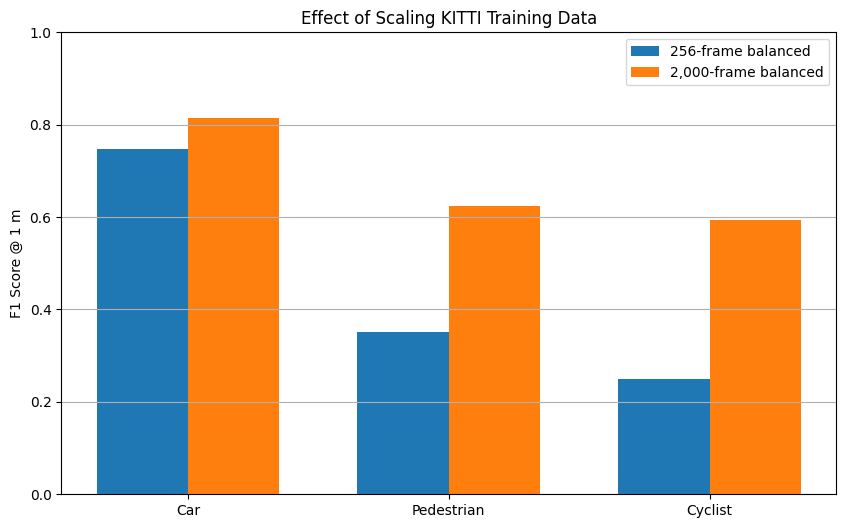

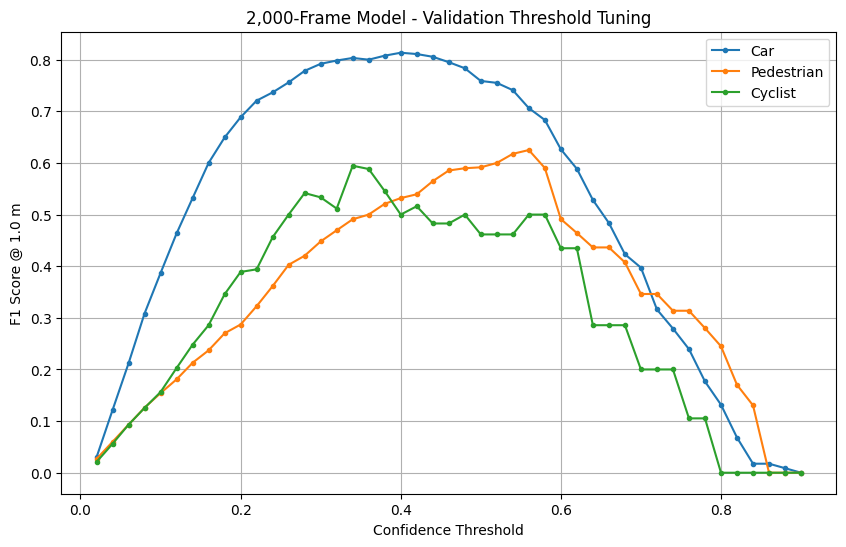


✅ 2,000-frame validation evaluation complete.


In [48]:
# ============================================================
# 2,000-FRAME MODEL
# 64-FRAME VALIDATION EVALUATION
#
# Purpose:
# - Load the best 2,000-frame checkpoint
# - Evaluate on the frozen 64 validation frames
# - Tune class-specific confidence thresholds
# - Report Precision / Recall / F1 @ 1 meter
# - Compare against the previous 256-frame balanced model
#
# NO TRAINING
# NO 256-FRAME DEVELOPMENT BENCHMARK DATA
# NO FINAL TEST DATA
# ============================================================

import time
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ============================================================
# 1. Configuration
# ============================================================

CLASS_NAMES_2000 = [
    "Car",
    "Pedestrian",
    "Cyclist"
]

NUM_CLASSES_2000 = 3

MIN_CANDIDATE_SCORE_2000 = 0.01

THRESHOLDS_2000 = np.arange(
    0.02,
    0.92,
    0.02
)

MATCH_DISTANCE_2000 = 1.0


# ============================================================
# 2. Load best 2,000-frame checkpoint
# ============================================================

checkpoint_2000_path = Path(
    "checkpoints/stride4_bev_detector_2000_balanced_best.pt"
)


print("==========================================")
print("2,000-FRAME MODEL VALIDATION")
print("==========================================")

print(
    "\nCheckpoint exists:",
    checkpoint_2000_path.exists()
)


checkpoint_2000 = torch.load(
    checkpoint_2000_path,
    map_location=device,
    weights_only=False
)


model_2000 = (
    Stride4CenterDetector(
        num_classes=3
    )
    .to(device)
)


model_2000.load_state_dict(
    checkpoint_2000["model_state_dict"]
)

model_2000.eval()


print(
    "\nBest fine-tuning epoch:",
    checkpoint_2000["epoch"]
)

print(
    "Training loss:",
    round(
        checkpoint_2000["train_loss"],
        4
    )
)

print(
    "Validation loss:",
    round(
        checkpoint_2000["validation_loss"],
        4
    )
)

print(
    "Training frames:",
    checkpoint_2000["training_frames"]
)

print(
    "Model device:",
    next(model_2000.parameters()).device
)


# ============================================================
# 3. Run inference over all 64 validation frames
# ============================================================

validation_records_2000 = {}

start_time_2000 = time.perf_counter()


for frame_number, frame_id in enumerate(
    validation_frame_ids,
    start=1
):

    frame_id = str(frame_id)


    # --------------------------------------------------------
    # Build BEV and GT target
    # --------------------------------------------------------

    bev_sample, target_full, counts = (
        build_kitti_training_sample(
            frame_id
        )
    )


    # --------------------------------------------------------
    # Downsample GT to stride-4 resolution
    # --------------------------------------------------------

    target_low = F.max_pool2d(
        target_full.unsqueeze(0),
        kernel_size=OUTPUT_STRIDE,
        stride=OUTPUT_STRIDE
    )[0]


    # --------------------------------------------------------
    # Input -> GPU
    # --------------------------------------------------------

    bev_gpu = (
        bev_sample
        .unsqueeze(0)
        .to(device)
    )


    # --------------------------------------------------------
    # FP32 inference
    # --------------------------------------------------------

    with torch.no_grad():

        logits = model_2000(
            bev_gpu
        )[0]


    probabilities = torch.sigmoid(
        logits
    )


    probabilities = torch.nan_to_num(
        probabilities,
        nan=0.0,
        posinf=1.0,
        neginf=0.0
    )


    # --------------------------------------------------------
    # Local-maximum suppression
    # --------------------------------------------------------

    pooled = F.max_pool2d(
        probabilities.unsqueeze(0),
        kernel_size=5,
        stride=1,
        padding=2
    )[0]


    peak_map = torch.where(
        probabilities == pooled,
        probabilities,
        torch.zeros_like(probabilities)
    )


    frame_record = {}


    # ========================================================
    # Per class
    # ========================================================

    for class_id in range(
        NUM_CLASSES_2000
    ):

        # ----------------------------------------------------
        # GT centers
        # ----------------------------------------------------

        gt_positions = np.argwhere(
            target_low[class_id].numpy()
            == 1.0
        )


        gt_centers = np.array(
            [
                [
                    int(position[0]),
                    int(position[1])
                ]
                for position in gt_positions
            ],
            dtype=np.float32
        )


        if len(gt_centers) == 0:

            gt_centers = np.empty(
                (0, 2),
                dtype=np.float32
            )


        # ----------------------------------------------------
        # Predicted local maxima
        # ----------------------------------------------------

        class_peak_map = (
            peak_map[class_id]
        )


        candidate_indices = torch.nonzero(
            class_peak_map
            >= MIN_CANDIDATE_SCORE_2000,
            as_tuple=False
        )


        predictions = []


        for index in candidate_indices:

            px = int(
                index[0].item()
            )

            py = int(
                index[1].item()
            )

            score = float(
                class_peak_map[
                    px,
                    py
                ].item()
            )


            predictions.append(
                [
                    px,
                    py,
                    score
                ]
            )


        # Sort highest-confidence predictions first
        predictions.sort(
            key=lambda x: x[2],
            reverse=True
        )


        predictions = np.array(
            predictions,
            dtype=np.float32
        )


        if len(predictions) == 0:

            predictions = np.empty(
                (0, 3),
                dtype=np.float32
            )


        frame_record[class_id] = {
            "gt": gt_centers,
            "predictions": predictions
        }


    validation_records_2000[
        frame_id
    ] = frame_record


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        frame_number == 1
        or
        frame_number % 10 == 0
        or
        frame_number
        ==
        len(validation_frame_ids)
    ):

        print(
            f"Processed "
            f"{frame_number:2d}/"
            f"{len(validation_frame_ids)} "
            f"validation frames"
        )


torch.cuda.synchronize()


processing_time_2000 = (
    time.perf_counter()
    -
    start_time_2000
)


print(
    "\nProcessing time:",
    round(
        processing_time_2000,
        1
    ),
    "seconds"
)


# ============================================================
# 4. Detection evaluation function
#
# Score-ordered one-to-one matching:
#
# Prediction -> nearest unmatched GT
#
# TP if distance <= tolerance
# Otherwise FP
#
# Unmatched GT -> FN
# ============================================================

def evaluate_2000_class(
    class_id,
    confidence_threshold,
    distance_tolerance=1.0
):

    total_gt = 0
    total_predictions = 0

    tp = 0
    fp = 0
    fn = 0

    localization_errors = []


    for frame_record in (
        validation_records_2000.values()
    ):

        gt = (
            frame_record[
                class_id
            ]["gt"]
        )


        predictions = (
            frame_record[
                class_id
            ]["predictions"]
        )


        # ----------------------------------------------------
        # Confidence filtering
        # ----------------------------------------------------

        if len(predictions) > 0:

            predictions = predictions[
                predictions[:, 2]
                >= confidence_threshold
            ]


        total_gt += len(gt)

        total_predictions += len(
            predictions
        )


        gt_used = np.zeros(
            len(gt),
            dtype=bool
        )


        # ----------------------------------------------------
        # Predictions are already confidence sorted
        # ----------------------------------------------------

        for prediction in predictions:

            px = prediction[0]
            py = prediction[1]


            if len(gt) == 0:

                fp += 1
                continue


            dx = (
                gt[:, 0] - px
            )

            dy = (
                gt[:, 1] - py
            )


            distances = (
                np.sqrt(
                    dx**2
                    +
                    dy**2
                )
                *
                OUTPUT_RESOLUTION
            )


            # GT cannot be matched twice
            distances[
                gt_used
            ] = np.inf


            nearest_gt = int(
                np.argmin(
                    distances
                )
            )


            nearest_distance = float(
                distances[
                    nearest_gt
                ]
            )


            if (
                nearest_distance
                <= distance_tolerance
            ):

                tp += 1

                gt_used[
                    nearest_gt
                ] = True

                localization_errors.append(
                    nearest_distance
                )


            else:

                fp += 1


        # Remaining GT objects are false negatives
        fn += int(
            np.sum(
                ~gt_used
            )
        )


    # ========================================================
    # Metrics
    # ========================================================

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )


    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )


    f1 = (
        2
        *
        precision
        *
        recall
        /
        (
            precision
            +
            recall
        )
        if
        (
            precision
            +
            recall
        ) > 0
        else 0.0
    )


    mean_error = (
        float(
            np.mean(
                localization_errors
            )
        )
        if localization_errors
        else np.nan
    )


    median_error = (
        float(
            np.median(
                localization_errors
            )
        )
        if localization_errors
        else np.nan
    )


    return {
        "gt":
            total_gt,

        "predictions":
            total_predictions,

        "tp":
            tp,

        "fp":
            fp,

        "fn":
            fn,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "mean_error":
            mean_error,

        "median_error":
            median_error
    }


# ============================================================
# 5. Tune confidence threshold on VALIDATION ONLY
# ============================================================

best_thresholds_2000 = {}

threshold_curves_2000 = {}


print("\n==========================================")
print("2,000-FRAME THRESHOLD SEARCH")
print("==========================================")


for class_id, class_name in enumerate(
    CLASS_NAMES_2000
):

    best_threshold = None
    best_f1 = -1.0

    curve = []


    for threshold in THRESHOLDS_2000:

        metrics = evaluate_2000_class(
            class_id,
            confidence_threshold=
                threshold,
            distance_tolerance=
                MATCH_DISTANCE_2000
        )


        curve.append(
            (
                threshold,
                metrics["f1"]
            )
        )


        if metrics["f1"] > best_f1:

            best_f1 = (
                metrics["f1"]
            )

            best_threshold = (
                threshold
            )


    best_thresholds_2000[
        class_id
    ] = best_threshold


    threshold_curves_2000[
        class_id
    ] = curve


    print(
        f"{class_name:10s} | "
        f"threshold = "
        f"{best_threshold:.2f} | "
        f"F1@1m = "
        f"{best_f1:.3f}"
    )

# ============================================================
# The thresholds selected above are now frozen.
#
# They will be used unchanged for the later 512-frame
# final held-out evaluation.
# ============================================================

# ============================================================
# 6. Selected-model validation results @ 1 meter
# ============================================================

results_2000_1m = {}


total_tp_2000 = 0
total_fp_2000 = 0
total_fn_2000 = 0


print("\n==========================================")
print("2,000-FRAME MODEL - VALIDATION @ 1.0 m")
print("==========================================")


for class_id, class_name in enumerate(
    CLASS_NAMES_2000
):

    threshold = (
        best_thresholds_2000[
            class_id
        ]
    )


    metrics = evaluate_2000_class(
        class_id,
        confidence_threshold=
            threshold,
        distance_tolerance=
            1.0
    )


    results_2000_1m[
        class_id
    ] = metrics


    total_tp_2000 += metrics["tp"]
    total_fp_2000 += metrics["fp"]
    total_fn_2000 += metrics["fn"]


    print(
        f"\n{class_name}"
    )

    print(
        f"  Threshold   : "
        f"{threshold:.2f}"
    )

    print(
        f"  GT objects  : "
        f"{metrics['gt']}"
    )

    print(
        f"  Predictions : "
        f"{metrics['predictions']}"
    )

    print(
        f"  TP / FP / FN: "
        f"{metrics['tp']} / "
        f"{metrics['fp']} / "
        f"{metrics['fn']}"
    )

    print(
        f"  Precision   : "
        f"{metrics['precision']:.3f}"
    )

    print(
        f"  Recall      : "
        f"{metrics['recall']:.3f}"
    )

    print(
        f"  F1          : "
        f"{metrics['f1']:.3f}"
    )

    print(
        f"  Mean error  : "
        f"{metrics['mean_error']:.3f} m"
    )


# ============================================================
# 7. Overall micro metrics
# ============================================================

overall_precision_2000 = (
    total_tp_2000
    /
    (
        total_tp_2000
        +
        total_fp_2000
    )
    if
    (
        total_tp_2000
        +
        total_fp_2000
    ) > 0
    else 0.0
)


overall_recall_2000 = (
    total_tp_2000
    /
    (
        total_tp_2000
        +
        total_fn_2000
    )
    if
    (
        total_tp_2000
        +
        total_fn_2000
    ) > 0
    else 0.0
)


overall_f1_2000 = (
    2
    *
    overall_precision_2000
    *
    overall_recall_2000
    /
    (
        overall_precision_2000
        +
        overall_recall_2000
    )
    if
    (
        overall_precision_2000
        +
        overall_recall_2000
    ) > 0
    else 0.0
)


print("\n------------------------------------------")
print("OVERALL VALIDATION")
print("------------------------------------------")

print(
    "\nTP / FP / FN:",
    total_tp_2000,
    "/",
    total_fp_2000,
    "/",
    total_fn_2000
)

print(
    "Precision:",
    round(
        overall_precision_2000,
        3
    )
)

print(
    "Recall   :",
    round(
        overall_recall_2000,
        3
    )
)

print(
    "F1       :",
    round(
        overall_f1_2000,
        3
    )
)


# ============================================================
# 8. Compare against previous 256-frame balanced model
# ============================================================

if "balanced_results_1m" in globals():

    print("\n==========================================")
    print("256-BALANCED vs 2,000-BALANCED @ 1.0 m")
    print("==========================================\n")


    print(
        f"{'Class':<14}"
        f"{'256 F1':<14}"
        f"{'2000 F1':<14}"
        f"{'Change':<12}"
    )

    print(
        "-" * 54
    )


    old_f1_values = []
    new_f1_values = []


    for class_id, class_name in enumerate(
        CLASS_NAMES_2000
    ):

        old_f1 = (
            balanced_results_1m[
                class_id
            ]["f1"]
        )


        new_f1 = (
            results_2000_1m[
                class_id
            ]["f1"]
        )


        change = (
            new_f1
            -
            old_f1
        )


        old_f1_values.append(
            old_f1
        )

        new_f1_values.append(
            new_f1
        )


        print(
            f"{class_name:<14}"
            f"{old_f1:<14.3f}"
            f"{new_f1:<14.3f}"
            f"{change:+.3f}"
        )


    # --------------------------------------------------------
    # Comparison plot
    # --------------------------------------------------------

    x = np.arange(
        len(
            CLASS_NAMES_2000
        )
    )


    width = 0.35


    plt.figure(
        figsize=(10, 6)
    )


    plt.bar(
        x - width / 2,
        old_f1_values,
        width,
        label="256-frame balanced"
    )


    plt.bar(
        x + width / 2,
        new_f1_values,
        width,
        label="2,000-frame balanced"
    )


    plt.xticks(
        x,
        CLASS_NAMES_2000
    )


    plt.ylabel(
        "F1 Score @ 1 m"
    )


    plt.ylim(
        0,
        1.0
    )


    plt.title(
        "Effect of Scaling KITTI Training Data"
    )


    plt.grid(
        axis="y"
    )


    plt.legend()

    plt.show()


else:

    print(
        "\nPrevious 256-frame balanced metrics "
        "are not currently in memory."
    )


# ============================================================
# 9. Threshold tuning curves
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for class_id, class_name in enumerate(
    CLASS_NAMES_2000
):

    curve = (
        threshold_curves_2000[
            class_id
        ]
    )


    thresholds_plot = [
        item[0]
        for item in curve
    ]


    f1_plot = [
        item[1]
        for item in curve
    ]


    plt.plot(
        thresholds_plot,
        f1_plot,
        marker=".",
        label=class_name
    )


plt.xlabel(
    "Confidence Threshold"
)

plt.ylabel(
    "F1 Score @ 1.0 m"
)

plt.title(
    "2,000-Frame Model - Validation Threshold Tuning"
)

plt.grid(True)

plt.legend()

plt.show()


print(
    "\n✅ 2,000-frame validation evaluation complete."
)

In [ ]:
# ============================================================
# CREATE FINAL UNTOUCHED 512-FRAME HELD-OUT EVALUATION SPLIT
#
# This held-out evaluation split excludes:
# - all 2,000 expanded training frames
# - all 64 validation frames
# - the earlier 256-frame development benchmark
#
# We will create this split ONCE and never tune anything on it.
#
# NO TRAINING
# NO MODEL INFERENCE
# ============================================================

from pathlib import Path
import numpy as np


# ============================================================
# 1. Configuration
# ============================================================

FINAL_TEST_SIZE = 512
FINAL_TEST_SEED = 2027

experiment_dir = Path(
    "experiment_data"
)

experiment_dir.mkdir(
    exist_ok=True
)


# ============================================================
# 2. Existing protected sets
# ============================================================

expanded_training_set = set(
    str(x)
    for x in expanded_train_frame_ids
)

frozen_validation_set = set(
    str(x)
    for x in validation_frame_ids
)

previous_benchmark_set = set(
    str(x)
    for x in test_frame_ids
)


print("==========================================")
print("FINAL TEST SPLIT CREATION")
print("==========================================")

print(
    "\nExpanded training frames:",
    len(expanded_training_set)
)

print(
    "Validation frames:",
    len(frozen_validation_set)
)

print(
    "Previous development benchmark frames:",
    len(previous_benchmark_set)
)


# ============================================================
# 3. Find completely untouched candidates
# ============================================================

all_usable_ids = [
    str(x)
    for x in usable_frame_ids
]


protected_ids = (
    expanded_training_set
    |
    frozen_validation_set
    |
    previous_benchmark_set
)


final_test_candidates = [

    frame_id

    for frame_id in all_usable_ids

    if frame_id not in protected_ids
]


print(
    "\nCompletely untouched candidate frames:",
    len(final_test_candidates)
)


if (
    len(final_test_candidates)
    <
    FINAL_TEST_SIZE
):

    raise RuntimeError(
        "Not enough untouched frames "
        "for final test split."
    )


# ============================================================
# 4. Deterministically select 512 frames
# ============================================================

rng_final_test = np.random.default_rng(
    FINAL_TEST_SEED
)


final_test_candidates = np.array(
    final_test_candidates
)


rng_final_test.shuffle(
    final_test_candidates
)


final_test_frame_ids = (

    final_test_candidates[
        :FINAL_TEST_SIZE
    ]

    .tolist()
)


final_test_set = set(
    final_test_frame_ids
)


# ============================================================
# 5. Leakage verification
# ============================================================

train_overlap = (
    final_test_set
    &
    expanded_training_set
)

validation_overlap = (
    final_test_set
    &
    frozen_validation_set
)

benchmark_overlap = (
    final_test_set
    &
    previous_benchmark_set
)


print("\n==========================================")
print("LEAKAGE CHECK")
print("==========================================")

print(
    "\nFinal test frames:",
    len(final_test_set)
)

print(
    "Final Test ∩ Training:",
    len(train_overlap)
)

print(
    "Final Test ∩ Validation:",
    len(validation_overlap)
)

print(
    "Final Test ∩ Development benchmark:",
    len(benchmark_overlap)
)


if (
    len(train_overlap) == 0
    and
    len(validation_overlap) == 0
    and
    len(benchmark_overlap) == 0
):

    print(
        "\n✅ Final test set is completely untouched."
    )

else:

    raise RuntimeError(
        "Final test leakage detected."
    )


# ============================================================
# 6. Save permanently
# ============================================================

final_test_path = (
    experiment_dir
    /
    "final_test_512_frames.txt"
)


with open(
    final_test_path,
    "w"
) as f:

    for frame_id in final_test_frame_ids:

        f.write(
            frame_id + "\n"
        )


print(
    "\nSaved final test split:"
)

print(
    final_test_path.resolve()
)


# ============================================================
# 7. Save selected model thresholds
# ============================================================

threshold_path = (
    experiment_dir
    /
    "selected_model_thresholds.txt"
)


with open(
    threshold_path,
    "w"
) as f:

    f.write(
        f"Car={best_thresholds_2000[0]:.2f}\n"
    )

    f.write(
        f"Pedestrian={best_thresholds_2000[1]:.2f}\n"
    )

    f.write(
        f"Cyclist={best_thresholds_2000[2]:.2f}\n"
    )


print(
    "\nSaved fixed thresholds:"
)

print(
    threshold_path.resolve()
)


print("\n==========================================")
print("FINAL TEST PROTOCOL LOCKED")
print("==========================================")

print(
    "\nSelected model:"
)

print(
    "stride4_bev_detector_2000_balanced_best.pt"
)

print(
    "\nFixed validation thresholds:"
)

print(
    f"Car        : {best_thresholds_2000[0]:.2f}"
)

print(
    f"Pedestrian : {best_thresholds_2000[1]:.2f}"
)

print(
    f"Cyclist    : {best_thresholds_2000[2]:.2f}"
)

print(
    "\n✅ Ready for one-time final evaluation."
)

In [ ]:
# ============================================================
# FINAL ONE-TIME 512-FRAME TEST EVALUATION
#
# Selected model:
#   stride4_bev_detector_2000_balanced_best.pt
#
# Training:
#   2,000 balanced KITTI frames
#
# Model selection / threshold tuning:
#   frozen 64-frame validation set
#
# Final test:
#   512 KITTI frames untouched during training,
#   model selection, and threshold tuning
#
# IMPORTANT:
# - Thresholds are FIXED from validation.
# - No threshold tuning occurs here.
# - No training occurs here.
# - Final-test performance uses custom BEV center-detection metrics,
#   with score-ordered one-to-one matching at a 1.0 m tolerance.
# - These are NOT the official KITTI 3D Average Precision (AP) metrics.
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ============================================================
# 1. Paths
# ============================================================

experiment_dir = Path(
    "experiment_data"
)

final_test_split_path = (
    experiment_dir
    /
    "final_test_512_frames.txt"
)

threshold_file_path = (
    experiment_dir
    /
    "selected_model_thresholds.txt"
)

selected_checkpoint_path = Path(
    "checkpoints/stride4_bev_detector_2000_balanced_best.pt"
)


# ============================================================
# 2. Load frozen final-test frame IDs
# ============================================================

with open(
    final_test_split_path,
    "r"
) as f:

    final_test_ids_eval = [
        line.strip()
        for line in f
        if line.strip()
    ]


# ============================================================
# 3. Load FIXED validation-tuned thresholds
# ============================================================

fixed_thresholds = {}


with open(
    threshold_file_path,
    "r"
) as f:

    for line in f:

        line = line.strip()

        if not line:
            continue

        class_name, value = line.split(
            "=",
            1
        )

        fixed_thresholds[
            class_name
        ] = float(
            value
        )


CLASS_NAMES_FINAL = [
    "Car",
    "Pedestrian",
    "Cyclist"
]


CLASS_THRESHOLDS_FINAL = {

    0:
        fixed_thresholds["Car"],

    1:
        fixed_thresholds["Pedestrian"],

    2:
        fixed_thresholds["Cyclist"]
}


# ============================================================
# 4. Verify evaluation configuration
# ============================================================

print("==========================================")
print("FINAL 512-FRAME TEST EVALUATION")
print("==========================================")

print(
    "\nFinal test frames:",
    len(final_test_ids_eval)
)

print(
    "\nFixed validation thresholds:"
)

for class_id, class_name in enumerate(
    CLASS_NAMES_FINAL
):

    print(
        f"{class_name:10s}: "
        f"{CLASS_THRESHOLDS_FINAL[class_id]:.2f}"
    )


print(
    "\nSelected checkpoint:"
)

print(
    selected_checkpoint_path.resolve()
)


if len(final_test_ids_eval) != 512:

    raise RuntimeError(
        "Final test split does not contain 512 frames."
    )


# ============================================================
# 5. Final leakage verification
# ============================================================

final_eval_set = set(
    final_test_ids_eval
)

expanded_train_set_eval = set(
    str(x)
    for x in expanded_train_frame_ids
)

validation_set_eval = set(
    str(x)
    for x in validation_frame_ids
)

previous_benchmark_set_eval = set(
    str(x)
    for x in test_frame_ids
)


print("\n------------------------------------------")
print("LEAKAGE VERIFICATION")
print("------------------------------------------")


print(
    "\nFinal Test ∩ Training:",
    len(
        final_eval_set
        &
        expanded_train_set_eval
    )
)

print(
    "Final Test ∩ Validation:",
    len(
        final_eval_set
        &
        validation_set_eval
    )
)

print(
    "Final Test ∩ Development benchmark:",
    len(
        final_eval_set
        &
        previous_benchmark_set_eval
    )
)


if (
    len(
        final_eval_set
        &
        expanded_train_set_eval
    ) != 0
    or
    len(
        final_eval_set
        &
        validation_set_eval
    ) != 0
    or
    len(
        final_eval_set
        &
        previous_benchmark_set_eval
    ) != 0
):

    raise RuntimeError(
        "Data leakage detected. "
        "Final evaluation aborted."
    )


print(
    "\n✅ Final test set has zero overlap with training, "
    "validation, and the development benchmark."
)


# ============================================================
# 6. Load selected 2,000-frame model
# ============================================================

checkpoint_final = torch.load(
    selected_checkpoint_path,
    map_location=device,
    weights_only=False
)


final_model = (
    Stride4CenterDetector(
        num_classes=3
    )
    .to(device)
)


final_model.load_state_dict(
    checkpoint_final[
        "model_state_dict"
    ]
)


final_model.eval()


print("\n------------------------------------------")
print("SELECTED MODEL")
print("------------------------------------------")


print(
    "\nFine-tuning checkpoint epoch:",
    checkpoint_final["epoch"]
)

print(
    "Training frames:",
    checkpoint_final["training_frames"]
)

print(
    "Validation loss:",
    round(
        checkpoint_final[
            "validation_loss"
        ],
        5
    )
)

print(
    "Device:",
    next(
        final_model.parameters()
    ).device
)


# ============================================================
# 7. Run inference over all 512 final-test frames
# ============================================================

MIN_FINAL_CANDIDATE_SCORE = 0.01

final_test_records = {}


if torch.cuda.is_available():

    torch.cuda.empty_cache()


start_time = time.perf_counter()


for frame_number, frame_id in enumerate(
    final_test_ids_eval,
    start=1
):

    frame_id = str(
        frame_id
    )


    # --------------------------------------------------------
    # Build BEV input and full-resolution GT
    # --------------------------------------------------------

    bev_sample, target_full, object_counts = (
        build_kitti_training_sample(
            frame_id
        )
    )


    # --------------------------------------------------------
    # Convert GT target to stride-4 output resolution
    # --------------------------------------------------------

    target_low = F.max_pool2d(

        target_full.unsqueeze(0),

        kernel_size=OUTPUT_STRIDE,

        stride=OUTPUT_STRIDE

    )[0]


    # --------------------------------------------------------
    # Send input to GPU
    # --------------------------------------------------------

    bev_gpu = (
        bev_sample
        .unsqueeze(0)
        .to(device)
    )


    # --------------------------------------------------------
    # Model inference
    # --------------------------------------------------------

    with torch.no_grad():

        logits = final_model(
            bev_gpu
        )[0]


    probabilities = torch.sigmoid(
        logits
    )


    probabilities = torch.nan_to_num(

        probabilities,

        nan=0.0,

        posinf=1.0,

        neginf=0.0
    )


    # --------------------------------------------------------
    # Local maximum suppression
    # --------------------------------------------------------

    pooled = F.max_pool2d(

        probabilities.unsqueeze(0),

        kernel_size=5,

        stride=1,

        padding=2

    )[0]


    peak_map = torch.where(

        probabilities == pooled,

        probabilities,

        torch.zeros_like(
            probabilities
        )
    )


    frame_record = {}


    # ========================================================
    # Extract GT + predicted centers for each class
    # ========================================================

    for class_id in range(
        3
    ):

        # ----------------------------------------------------
        # Ground-truth centers
        # ----------------------------------------------------

        gt_positions = np.argwhere(

            target_low[
                class_id
            ].numpy()

            == 1.0
        )


        gt_centers = np.array(

            [
                [
                    int(position[0]),
                    int(position[1])
                ]

                for position
                in gt_positions
            ],

            dtype=np.float32
        )


        if len(gt_centers) == 0:

            gt_centers = np.empty(
                (0, 2),
                dtype=np.float32
            )


        # ----------------------------------------------------
        # Predicted local maxima
        # ----------------------------------------------------

        class_peak_map = (
            peak_map[
                class_id
            ]
        )


        candidate_indices = torch.nonzero(

            class_peak_map
            >=
            MIN_FINAL_CANDIDATE_SCORE,

            as_tuple=False
        )


        predictions = []


        for index in candidate_indices:

            px = int(
                index[0].item()
            )

            py = int(
                index[1].item()
            )


            score = float(

                class_peak_map[
                    px,
                    py
                ].item()
            )


            predictions.append(
                [
                    px,
                    py,
                    score
                ]
            )


        # Highest confidence first
        predictions.sort(

            key=lambda item:
                item[2],

            reverse=True
        )


        predictions = np.array(

            predictions,

            dtype=np.float32
        )


        if len(predictions) == 0:

            predictions = np.empty(
                (0, 3),
                dtype=np.float32
            )


        frame_record[
            class_id
        ] = {

            "gt":
                gt_centers,

            "predictions":
                predictions
        }


    final_test_records[
        frame_id
    ] = frame_record


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        frame_number == 1
        or
        frame_number % 50 == 0
        or
        frame_number
        ==
        len(final_test_ids_eval)
    ):

        print(

            f"Processed "
            f"{frame_number:3d}/"
            f"{len(final_test_ids_eval)} "
            f"final-test frames"
        )


if torch.cuda.is_available():

    torch.cuda.synchronize()


final_processing_time = (

    time.perf_counter()

    -

    start_time
)


print(
    "\nInference + preprocessing time:",
    round(
        final_processing_time,
        1
    ),
    "seconds"
)


# ============================================================
# 8. Fixed-threshold evaluation helper
#
# Predictions are matched in descending confidence order.
#
# A prediction is a TP when its nearest UNMATCHED GT object
# of the same class is within 1.0 meter.
#
# Otherwise it is an FP.
#
# Any unmatched GT is an FN.
# ============================================================

def evaluate_final_class(
    class_id,
    confidence_threshold,
    distance_tolerance=1.0
):

    total_gt = 0

    total_predictions = 0

    tp = 0
    fp = 0
    fn = 0

    localization_errors = []


    for frame_record in (
        final_test_records.values()
    ):

        gt = (
            frame_record[
                class_id
            ]["gt"]
        )


        predictions = (
            frame_record[
                class_id
            ]["predictions"]
        )


        # ----------------------------------------------------
        # Apply FIXED validation threshold
        # ----------------------------------------------------

        if len(predictions) > 0:

            predictions = predictions[

                predictions[:, 2]
                >=
                confidence_threshold

            ]


        total_gt += len(
            gt
        )


        total_predictions += len(
            predictions
        )


        gt_used = np.zeros(
            len(gt),
            dtype=bool
        )


        # ----------------------------------------------------
        # One-to-one score-ordered matching
        # ----------------------------------------------------

        for prediction in predictions:

            px = prediction[0]

            py = prediction[1]


            if len(gt) == 0:

                fp += 1

                continue


            dx = (
                gt[:, 0]
                -
                px
            )


            dy = (
                gt[:, 1]
                -
                py
            )


            distances = (

                np.sqrt(
                    dx**2
                    +
                    dy**2
                )

                *

                OUTPUT_RESOLUTION
            )


            # Already matched GT cannot be reused
            distances[
                gt_used
            ] = np.inf


            nearest_gt = int(
                np.argmin(
                    distances
                )
            )


            nearest_distance = float(
                distances[
                    nearest_gt
                ]
            )


            if (
                nearest_distance
                <=
                distance_tolerance
            ):

                tp += 1


                gt_used[
                    nearest_gt
                ] = True


                localization_errors.append(
                    nearest_distance
                )


            else:

                fp += 1


        # ----------------------------------------------------
        # Remaining unmatched GT -> FN
        # ----------------------------------------------------

        fn += int(
            np.sum(
                ~gt_used
            )
        )


    # ========================================================
    # Metrics
    # ========================================================

    precision = (

        tp
        /
        (tp + fp)

        if
        (tp + fp) > 0

        else
        0.0
    )


    recall = (

        tp
        /
        (tp + fn)

        if
        (tp + fn) > 0

        else
        0.0
    )


    f1 = (

        2
        *
        precision
        *
        recall

        /

        (
            precision
            +
            recall
        )

        if
        (
            precision
            +
            recall
        ) > 0

        else
        0.0
    )


    mean_error = (

        float(
            np.mean(
                localization_errors
            )
        )

        if localization_errors

        else
        np.nan
    )


    median_error = (

        float(
            np.median(
                localization_errors
            )
        )

        if localization_errors

        else
        np.nan
    )


    return {

        "gt_objects":
            int(total_gt),

        "predictions":
            int(total_predictions),

        "tp":
            int(tp),

        "fp":
            int(fp),

        "fn":
            int(fn),

        "precision":
            float(precision),

        "recall":
            float(recall),

        "f1":
            float(f1),

        "mean_localization_error_m":
            float(mean_error),

        "median_localization_error_m":
            float(median_error)
    }


# ============================================================
# 9. FINAL RESULTS @ 1.0 meter
# ============================================================

FINAL_MATCH_DISTANCE = 1.0


final_results = {}


total_tp = 0
total_fp = 0
total_fn = 0


print("\n==========================================")
print("FINAL HELD-OUT RESULTS @ 1.0 m")
print("==========================================")


for class_id, class_name in enumerate(
    CLASS_NAMES_FINAL
):

    threshold = (
        CLASS_THRESHOLDS_FINAL[
            class_id
        ]
    )


    metrics = evaluate_final_class(

        class_id,

        confidence_threshold=
            threshold,

        distance_tolerance=
            FINAL_MATCH_DISTANCE
    )


    final_results[
        class_name
    ] = metrics


    total_tp += metrics[
        "tp"
    ]

    total_fp += metrics[
        "fp"
    ]

    total_fn += metrics[
        "fn"
    ]


    print(
        f"\n{class_name}"
    )


    print(
        f"  Fixed threshold : "
        f"{threshold:.2f}"
    )


    print(
        f"  GT objects      : "
        f"{metrics['gt_objects']}"
    )


    print(
        f"  Predictions     : "
        f"{metrics['predictions']}"
    )


    print(
        f"  TP / FP / FN    : "
        f"{metrics['tp']} / "
        f"{metrics['fp']} / "
        f"{metrics['fn']}"
    )


    print(
        f"  Precision       : "
        f"{metrics['precision']:.3f}"
    )


    print(
        f"  Recall          : "
        f"{metrics['recall']:.3f}"
    )


    print(
        f"  F1              : "
        f"{metrics['f1']:.3f}"
    )


    print(
        f"  Mean loc. error : "
        f"{metrics['mean_localization_error_m']:.3f} m"
    )


    print(
        f"  Median loc. err.: "
        f"{metrics['median_localization_error_m']:.3f} m"
    )


# ============================================================
# 10. Overall micro metrics
# ============================================================

overall_precision = (

    total_tp

    /

    (
        total_tp
        +
        total_fp
    )

    if
    (
        total_tp
        +
        total_fp
    ) > 0

    else
    0.0
)


overall_recall = (

    total_tp

    /

    (
        total_tp
        +
        total_fn
    )

    if
    (
        total_tp
        +
        total_fn
    ) > 0

    else
    0.0
)


overall_f1 = (

    2
    *
    overall_precision
    *
    overall_recall

    /

    (
        overall_precision
        +
        overall_recall
    )

    if
    (
        overall_precision
        +
        overall_recall
    ) > 0

    else
    0.0
)


# ============================================================
# 11. Macro metrics
#
# Gives equal importance to Car / Pedestrian / Cyclist.
# Useful because the dataset is class-imbalanced.
# ============================================================

macro_precision = float(

    np.mean(
        [
            final_results[
                class_name
            ]["precision"]

            for class_name
            in CLASS_NAMES_FINAL
        ]
    )
)


macro_recall = float(

    np.mean(
        [
            final_results[
                class_name
            ]["recall"]

            for class_name
            in CLASS_NAMES_FINAL
        ]
    )
)


macro_f1 = float(

    np.mean(
        [
            final_results[
                class_name
            ]["f1"]

            for class_name
            in CLASS_NAMES_FINAL
        ]
    )
)


print("\n------------------------------------------")
print("OVERALL FINAL TEST RESULT")
print("------------------------------------------")


print(
    "\nTP / FP / FN:",
    total_tp,
    "/",
    total_fp,
    "/",
    total_fn
)


print(
    "\nMicro Precision:",
    round(
        overall_precision,
        3
    )
)


print(
    "Micro Recall   :",
    round(
        overall_recall,
        3
    )
)


print(
    "Micro F1       :",
    round(
        overall_f1,
        3
    )
)


print(
    "\nMacro Precision:",
    round(
        macro_precision,
        3
    )
)


print(
    "Macro Recall   :",
    round(
        macro_recall,
        3
    )
)


print(
    "Macro F1       :",
    round(
        macro_f1,
        3
    )
)


# ============================================================
# 12. Save final results to JSON
# ============================================================

final_summary = {

    "experiment":
        "KITTI LiDAR BEV Center Detector",

    "selected_model":
        "stride4_bev_detector_2000_balanced_best.pt",

    "training_frames":
        2000,

    "validation_frames":
        64,

    "final_test_frames":
        512,

    "matching_tolerance_m":
        1.0,

    "threshold_source":
        "validation",

    "fixed_thresholds": {

        "Car":
            CLASS_THRESHOLDS_FINAL[0],

        "Pedestrian":
            CLASS_THRESHOLDS_FINAL[1],

        "Cyclist":
            CLASS_THRESHOLDS_FINAL[2]
    },

    "per_class":
        final_results,

    "overall_micro": {

        "tp":
            int(total_tp),

        "fp":
            int(total_fp),

        "fn":
            int(total_fn),

        "precision":
            float(overall_precision),

        "recall":
            float(overall_recall),

        "f1":
            float(overall_f1)
    },

    "overall_macro": {

        "precision":
            float(macro_precision),

        "recall":
            float(macro_recall),

        "f1":
            float(macro_f1)
    },

    "processing_time_seconds":
        float(
            final_processing_time
        )
}


final_results_path = (
    experiment_dir
    /
    "final_test_results_512.json"
)


with open(
    final_results_path,
    "w"
) as f:

    json.dump(
        final_summary,
        f,
        indent=4
    )


# ============================================================
# 13. Plot final per-class performance
# ============================================================

precision_values = [
    final_results[
        class_name
    ]["precision"]

    for class_name
    in CLASS_NAMES_FINAL
]


recall_values = [
    final_results[
        class_name
    ]["recall"]

    for class_name
    in CLASS_NAMES_FINAL
]


f1_values = [
    final_results[
        class_name
    ]["f1"]

    for class_name
    in CLASS_NAMES_FINAL
]


x = np.arange(
    len(
        CLASS_NAMES_FINAL
    )
)


width = 0.25


plt.figure(
    figsize=(10, 6)
)


plt.bar(

    x - width,

    precision_values,

    width,

    label="Precision"
)


plt.bar(

    x,

    recall_values,

    width,

    label="Recall"
)


plt.bar(

    x + width,

    f1_values,

    width,

    label="F1"
)


plt.xticks(
    x,
    CLASS_NAMES_FINAL
)


plt.ylim(
    0,
    1.05
)


plt.ylabel(
    "Score"
)


plt.title(
    "Final KITTI LiDAR Detector - 512-Frame Held-Out Evaluation @ 1 m"
)


plt.grid(
    axis="y"
)


plt.legend()


plt.tight_layout()


final_figure_path = (
    experiment_dir
    /
    "final_test_metrics_512.png"
)


plt.savefig(
    final_figure_path,
    dpi=200,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 14. Final confirmation
# ============================================================

print("\n==========================================")
print("FINAL EVALUATION COMPLETE")
print("==========================================")


print(
    "\nResults saved:"
)

print(
    final_results_path.resolve()
)


print(
    "\nFigure saved:"
)

print(
    final_figure_path.resolve()
)


print(
    "\n✅ Final-test thresholds were never tuned on this set."
)

print(
    "✅ These results are now locked for this model version."
)

## Final Held-Out Evaluation

The final model was selected using a fixed 64-frame validation set and evaluated once on a separately locked 512-frame held-out KITTI evaluation split.

The final 512 frames were excluded from:

- model training,
- validation and model selection,
- confidence-threshold tuning,
- the earlier 256-frame development benchmark.

### Final configuration

- Training frames: **2,000**
- Validation frames: **64**
- Development benchmark frames: **256**
- Final held-out evaluation frames: **512**
- BEV input resolution: **500 × 400**
- Detector output resolution: **125 × 100**
- Output stride: **4**
- Center-matching tolerance: **1.0 m**
- Car threshold: **0.40**
- Pedestrian threshold: **0.56**
- Cyclist threshold: **0.34**

### Final held-out performance

| Class | Precision | Recall | F1 |
|---|---:|---:|---:|
| Car | 0.827 | 0.808 | 0.817 |
| Pedestrian | 0.708 | 0.396 | 0.508 |
| Cyclist | 0.467 | 0.660 | 0.547 |

- **Micro Precision:** 0.792
- **Micro Recall:** 0.750
- **Micro F1:** 0.771
- **Macro Precision:** 0.667
- **Macro Recall:** 0.621
- **Macro F1:** 0.624

Car achieved the strongest overall performance. Pedestrian detection retained relatively high precision but lower recall, while Cyclist detection showed higher recall with lower precision.

The confidence thresholds used for this evaluation were selected beforehand using only the frozen validation set and were not adjusted using the final held-out frames.

> **Evaluation note:** These results use custom BEV object-center detection metrics with score-ordered one-to-one matching at a **1.0 m center-distance tolerance**. They are **not official KITTI 2D, BEV, or 3D Average Precision (AP) benchmark metrics**.

QUALITATIVE EXAMPLE FRAMES

1. Frame 002159 | Car=0, Pedestrian=1, Cyclist=0
2. Frame 003166 | Car=1, Pedestrian=1, Cyclist=0
3. Frame 001042 | Car=3, Pedestrian=0, Cyclist=1
4. Frame 007324 | Car=2, Pedestrian=0, Cyclist=3
5. Frame 002406 | Car=4, Pedestrian=0, Cyclist=0
6. Frame 000389 | Car=8, Pedestrian=0, Cyclist=0


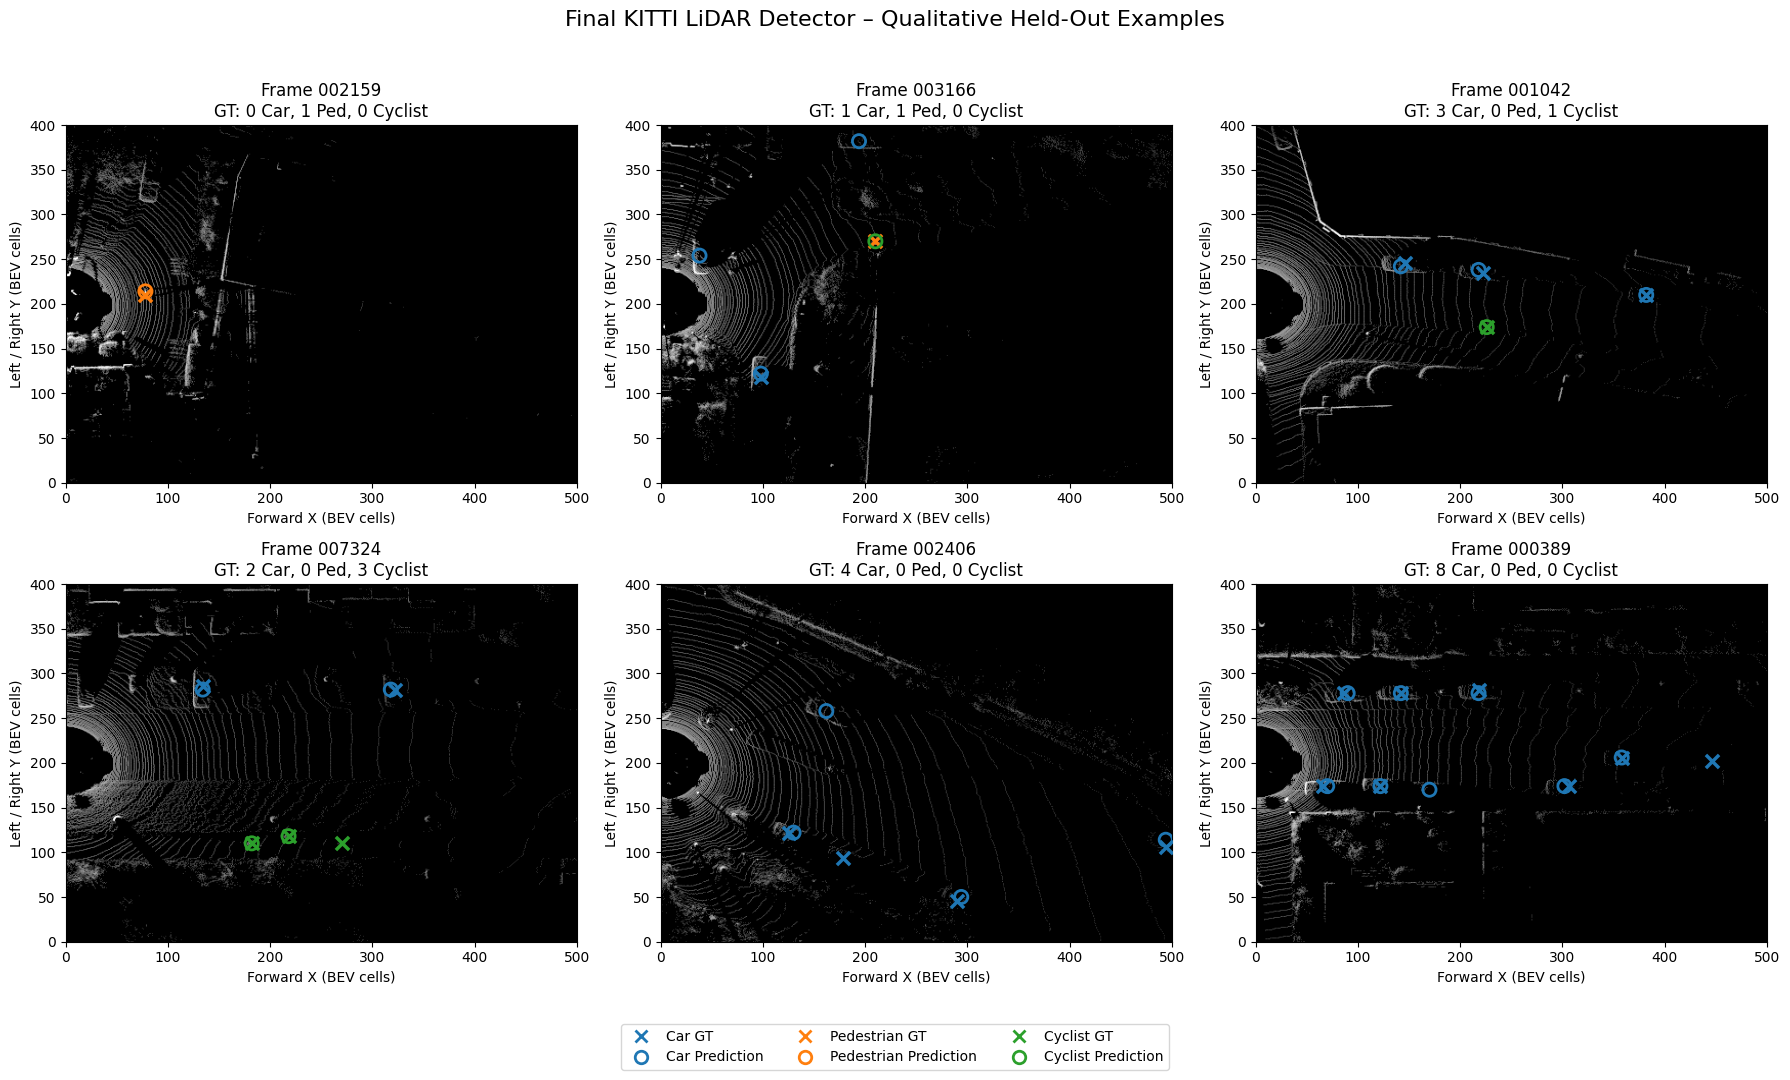


QUALITATIVE VISUALIZATION COMPLETE

Selected frame IDs saved:
D:\LiDAR Project\Lidar_Project\experiment_data\qualitative_example_frames.txt

Figure saved:
D:\LiDAR Project\Lidar_Project\experiment_data\qualitative_final_test_examples.png

×  = KITTI Ground Truth
○  = Final Model Prediction

✅ Fixed validation thresholds were used.
✅ Predictions were not used to select the example frames.


In [51]:
# ============================================================
# QUALITATIVE FINAL-TEST VISUALIZATION
#
# Shows:
# - LiDAR BEV density map
# - KITTI ground-truth centers
# - Final-model predicted centers
#
# Frame selection is based ONLY on GT class presence.
# Predictions are NOT used to select examples.
# Example selection is for visualization only and does not
# affect model selection, thresholds, or reported test metrics.
#
# NO TRAINING
# NO THRESHOLD TUNING
# NO METRIC CHANGES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from pathlib import Path


# ============================================================
# 1. Configuration
# ============================================================

CLASS_NAMES_VIS = [
    "Car",
    "Pedestrian",
    "Cyclist"
]


CLASS_COLORS_VIS = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green"
}


# Reuse the fixed thresholds loaded for the final evaluation.
VIS_THRESHOLDS = dict(
    CLASS_THRESHOLDS_FINAL
)


# ============================================================
# 2. Helper: number of GT objects in a frame
# ============================================================

def gt_count_in_frame(
    frame_id,
    class_id
):

    return len(
        final_test_records[
            str(frame_id)
        ][class_id]["gt"]
    )


# ============================================================
# 3. Select examples using GT ONLY
#
# 2 pedestrian-containing frames
# 2 cyclist-containing frames
# 2 car-rich frames
#
# Predictions are NOT considered here.
# ============================================================

selected_frames = []


# ------------------------------------------------------------
# A. Two pedestrian scenes
# ------------------------------------------------------------

pedestrian_frames = []


for frame_id in final_test_ids_eval:

    frame_id = str(frame_id)

    if (
        gt_count_in_frame(
            frame_id,
            1
        ) > 0
    ):

        pedestrian_frames.append(
            frame_id
        )

    if len(
        pedestrian_frames
    ) == 2:

        break


selected_frames.extend(
    pedestrian_frames
)


# ------------------------------------------------------------
# B. Two cyclist scenes
# ------------------------------------------------------------

cyclist_frames = []


for frame_id in final_test_ids_eval:

    frame_id = str(frame_id)

    if frame_id in selected_frames:
        continue

    if (
        gt_count_in_frame(
            frame_id,
            2
        ) > 0
    ):

        cyclist_frames.append(
            frame_id
        )

    if len(
        cyclist_frames
    ) == 2:

        break


selected_frames.extend(
    cyclist_frames
)


# ------------------------------------------------------------
# C. Two car-rich scenes
# ------------------------------------------------------------

car_frames = []


for frame_id in final_test_ids_eval:

    frame_id = str(frame_id)

    if frame_id in selected_frames:
        continue

    if (
        gt_count_in_frame(
            frame_id,
            0
        ) >= 3
    ):

        car_frames.append(
            frame_id
        )

    if len(
        car_frames
    ) == 2:

        break


selected_frames.extend(
    car_frames
)


# ------------------------------------------------------------
# Fallback if fewer than 6 were found
# ------------------------------------------------------------

for frame_id in final_test_ids_eval:

    frame_id = str(frame_id)

    if len(selected_frames) >= 6:
        break

    if frame_id not in selected_frames:

        selected_frames.append(
            frame_id
        )


selected_frames = (
    selected_frames[:6]
)


print("==========================================")
print("QUALITATIVE EXAMPLE FRAMES")
print("==========================================\n")


for index, frame_id in enumerate(
    selected_frames,
    start=1
):

    car_gt = gt_count_in_frame(
        frame_id,
        0
    )

    ped_gt = gt_count_in_frame(
        frame_id,
        1
    )

    cyclist_gt = gt_count_in_frame(
        frame_id,
        2
    )


    print(
        f"{index}. Frame {frame_id} | "
        f"Car={car_gt}, "
        f"Pedestrian={ped_gt}, "
        f"Cyclist={cyclist_gt}"
    )


# ============================================================
# 4. Save selected frame IDs for reproducibility
# ============================================================

qualitative_frame_file = (

    Path("experiment_data")
    /
    "qualitative_example_frames.txt"
)


with open(
    qualitative_frame_file,
    "w"
) as f:

    for frame_id in selected_frames:

        f.write(
            frame_id + "\n"
        )


# ============================================================
# 5. Create visualization
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11)
)


axes = axes.flatten()


for ax, frame_id in zip(
    axes,
    selected_frames
):

    # --------------------------------------------------------
    # Rebuild BEV so we can display the LiDAR scene
    # --------------------------------------------------------

    bev_sample, _, _ = (
        build_kitti_training_sample(
            frame_id
        )
    )


    # Channel 2 = BEV density
    #
    # Original tensor:
    # [channel, X, Y]
    #
    # Transpose so:
    # horizontal = forward X
    # vertical   = left/right Y
    # --------------------------------------------------------

    bev_background = (
        bev_sample[2]
        .cpu()
        .numpy()
        .T
    )


    ax.imshow(

        bev_background,

        origin="lower",

        extent=[
            0,
            bev_background.shape[1],
            0,
            bev_background.shape[0]
        ],

        cmap="gray",

        aspect="auto"
    )


    record = (
        final_test_records[
            frame_id
        ]
    )


    # ========================================================
    # Draw each class
    # ========================================================

    for class_id, class_name in enumerate(
        CLASS_NAMES_VIS
    ):

        color = (
            CLASS_COLORS_VIS[
                class_id
            ]
        )


        # ----------------------------------------------------
        # Ground truth
        # ----------------------------------------------------

        gt = (
            record[
                class_id
            ]["gt"]
        )


        if len(gt) > 0:

            gt_x = (
                (
                    gt[:, 0]
                    +
                    0.5
                )
                *
                OUTPUT_STRIDE
            )


            gt_y = (
                (
                    gt[:, 1]
                    +
                    0.5
                )
                *
                OUTPUT_STRIDE
            )


            ax.scatter(

                gt_x,

                gt_y,

                marker="x",

                s=90,

                linewidths=2.5,

                color=color,

                zorder=4
            )


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        predictions = (
            record[
                class_id
            ]["predictions"]
        )


        if len(predictions) > 0:

            predictions = predictions[
                predictions[:, 2]
                >=
                VIS_THRESHOLDS[
                    class_id
                ]
            ]


        if len(predictions) > 0:

            pred_x = (
                (
                    predictions[:, 0]
                    +
                    0.5
                )
                *
                OUTPUT_STRIDE
            )


            pred_y = (
                (
                    predictions[:, 1]
                    +
                    0.5
                )
                *
                OUTPUT_STRIDE
            )


            ax.scatter(

                pred_x,

                pred_y,

                marker="o",

                s=90,

                facecolors="none",

                edgecolors=color,

                linewidths=2.0,

                zorder=5
            )


    # ========================================================
    # Frame title
    # ========================================================

    num_car = len(
        record[0]["gt"]
    )

    num_ped = len(
        record[1]["gt"]
    )

    num_cyclist = len(
        record[2]["gt"]
    )


    ax.set_title(

        f"Frame {frame_id}\n"
        f"GT: {num_car} Car, "
        f"{num_ped} Ped, "
        f"{num_cyclist} Cyclist"
    )


    ax.set_xlabel(
        "Forward X (BEV cells)"
    )


    ax.set_ylabel(
        "Left / Right Y (BEV cells)"
    )


    ax.set_xlim(
        0,
        500
    )


    ax.set_ylim(
        0,
        400
    )


# ============================================================
# 6. Figure legend
# ============================================================

legend_handles = []


for class_id, class_name in enumerate(
    CLASS_NAMES_VIS
):

    color = (
        CLASS_COLORS_VIS[
            class_id
        ]
    )


    legend_handles.append(

        Line2D(

            [0],
            [0],

            marker="x",

            linestyle="None",

            color=color,

            markersize=9,

            markeredgewidth=2,

            label=f"{class_name} GT"
        )
    )


    legend_handles.append(

        Line2D(

            [0],
            [0],

            marker="o",

            linestyle="None",

            markerfacecolor="none",

            markeredgecolor=color,

            markersize=9,

            markeredgewidth=2,

            label=f"{class_name} Prediction"
        )
    )


fig.legend(

    handles=legend_handles,

    loc="lower center",

    ncol=3,

    bbox_to_anchor=(
        0.5,
        0.01
    )
)


fig.suptitle(

    "Final KITTI LiDAR Detector – Qualitative Held-Out Examples",

    fontsize=16
)


plt.tight_layout(
    rect=[
        0,
        0.08,
        1,
        0.96
    ]
)


# ============================================================
# 7. Save GitHub-ready figure
# ============================================================

qualitative_figure_path = (

    Path("experiment_data")
    /
    "qualitative_final_test_examples.png"
)


plt.savefig(

    qualitative_figure_path,

    dpi=200,

    bbox_inches="tight"
)


plt.show()


print("\n==========================================")
print("QUALITATIVE VISUALIZATION COMPLETE")
print("==========================================")


print(
    "\nSelected frame IDs saved:"
)

print(
    qualitative_frame_file.resolve()
)


print(
    "\nFigure saved:"
)

print(
    qualitative_figure_path.resolve()
)


print(
    "\n×  = KITTI Ground Truth"
)

print(
    "○  = Final Model Prediction"
)

print(
    "\n✅ Fixed validation thresholds were used."
)

print(
    "✅ Predictions were not used to select the example frames."
)

## Qualitative Detection Results

The figure above shows qualitative examples from the final model on the
locked 512-frame held-out evaluation split.

The displayed examples were selected using **ground-truth class presence only**.
Model predictions were not used to choose visually favorable examples.

### Visualization

- **× marker** — KITTI ground-truth object center
- **○ marker** — predicted object center
- **Blue** — Car
- **Orange** — Pedestrian
- **Green** — Cyclist

The background represents the LiDAR point cloud projected into the
bird's-eye-view (BEV) representation used by the detector.

Predictions were generated using the confidence thresholds selected previously
on the validation set:

| Class | Confidence Threshold |
|---|---:|
| Car | 0.40 |
| Pedestrian | 0.56 |
| Cyclist | 0.34 |

No thresholds were adjusted using the final held-out evaluation frames.

### Qualitative Observations

The model localizes many vehicles closely to their KITTI ground-truth centers,
including objects at different forward distances.

Pedestrian detections are generally precise when produced, which is consistent
with the model's relatively high pedestrian precision but lower recall on the
final test set.

Cyclist detections show higher recall but also more false positives, consistent
with the lower cyclist precision observed quantitatively.

These examples also demonstrate typical failure cases such as missed objects and
isolated predictions without a corresponding ground-truth object.

These qualitative observations are consistent with the quantitative held-out
results and include both successful detections and visible failure cases.

# Final Project Summary

## Objective

This project develops a LiDAR-based object-detection pipeline for the KITTI
dataset using a bird's-eye-view (BEV) representation and a lightweight
PyTorch neural network.

The detector predicts object centers for three road-user classes:

- Car
- Pedestrian
- Cyclist

## Pipeline

The project progressed through the following stages:

1. Loaded and visualized raw KITTI Velodyne LiDAR point clouds.
2. Cropped the point cloud to a forward driving region.
3. Removed ground points using RANSAC plane estimation.
4. Explored DBSCAN-based geometric object clustering as a classical baseline.
5. Parsed KITTI labels and calibration files to transform ground-truth objects
   into the LiDAR coordinate system.
6. Converted LiDAR point clouds into a three-channel BEV representation
   containing height, intensity, and density information.
7. Developed a convolutional center-heatmap detector in PyTorch.
8. Reduced the detector output to stride-4 resolution for more stable
   localization learning.
9. Identified substantial class imbalance in the KITTI training data.
10. Introduced class-aware weighted sampling to increase exposure to
    pedestrian and cyclist examples.
11. Scaled training from 256 frames to 2,000 frames.
12. Selected class-specific confidence thresholds using only the validation set.
13. Evaluated the selected model once on a separately locked 512-frame
    held-out evaluation split.

## Effect of Scaling the Training Set

Scaling from 256 to 2,000 training frames substantially improved validation
performance at a 1.0 m center-matching tolerance:

| Class | 256-Frame F1 | 2,000-Frame F1 |
|---|---:|---:|
| Car | 0.747 | 0.813 |
| Pedestrian | 0.351 | 0.625 |
| Cyclist | 0.250 | 0.595 |

The improvement was particularly strong for the minority pedestrian and cyclist
classes.

## Final Held-Out Evaluation Results

The final model was evaluated on 512 KITTI frames that were excluded from
training, validation and model selection, confidence-threshold tuning, and the
earlier 256-frame development benchmark.

| Class | Precision | Recall | F1 |
|---|---:|---:|---:|
| Car | 0.827 | 0.808 | 0.817 |
| Pedestrian | 0.708 | 0.396 | 0.508 |
| Cyclist | 0.467 | 0.660 | 0.547 |

### Overall Performance

- **Micro Precision:** 0.792
- **Micro Recall:** 0.750
- **Micro F1:** 0.771

- **Macro Precision:** 0.667
- **Macro Recall:** 0.621
- **Macro F1:** 0.624

## Localization

For correctly matched detections, the mean center-localization errors were:

| Class | Mean Localization Error |
|---|---:|
| Car | 0.206 m |
| Pedestrian | 0.074 m |
| Cyclist | 0.099 m |

## Key Findings

- Increasing the training set from 256 to 2,000 frames improved all three
  object classes.
- Class-aware sampling substantially improved minority-class learning.
- Car detection achieved the strongest and most balanced precision/recall.
- Pedestrian detections were relatively precise but had lower recall.
- Cyclist detection achieved higher recall but produced more false positives.
- Held-out performance remained broadly comparable to validation performance,
  although pedestrian and cyclist F1 scores decreased on the larger unseen split.

## Limitations

This detector predicts BEV object centers rather than full oriented 3D bounding
boxes.

The evaluation therefore measures center localization within a 1.0 m tolerance
and should not be interpreted as the official KITTI 3D detection metric or
KITTI Average Precision benchmark.

Performance for pedestrians and cyclists is also limited by the substantially
smaller number of examples available for those classes.

The train, validation, development-benchmark, and held-out evaluation splits
were sampled from frames containing at least one Car, Pedestrian, or Cyclist
annotation. Background-only KITTI frames are therefore not represented in these
splits, so false-positive behavior on completely empty scenes is not measured
by the reported metrics.

The reported localization errors are measured on the stride-4 BEV target grid
(0.4 m per output cell). They therefore reflect quantized target-center
locations rather than continuous KITTI 3D bounding-box center coordinates.

## Conclusion

The project demonstrates an end-to-end LiDAR perception workflow spanning
point-cloud preprocessing, classical clustering, coordinate transformation,
BEV feature construction, GPU-accelerated neural-network training,
class-imbalance handling, validation-based model selection, and held-out
evaluation.

The final 2,000-frame balanced detector achieved a **0.771 micro F1 score**
and **0.624 macro F1 score** on the locked 512-frame held-out evaluation split.